# Clasificación de Cáncer de Mama — Informe Final Integrado
## Aprendizaje Automático Estadístico · MIAA-B · Semanas 1, 2 y 3

**Asignatura:** Aprendizaje automático estadístico MIA-B  
**Docente:** Ivan Danilo Garcia Santillan  
**Universidad:** UIDE  
**Grupo 1:**
- César Nelson Abarca Araujo
- Nataly Fernanda Lanchimba Caiza
- Jhon Enrique Oña Guamani

**Dataset:** [Breast Cancer Wisconsin (Diagnostic) — UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic)  
**Repositorio GitHub:** [UIDE MIAA-B · Aprendizaje Automático Estadístico  . Deber Grupal Final](https://github.com/cnabarca/Maestria-IA-UIDE/tree/main/5.%20Aprendizaje%20Automatico%20Estadistico/Informe%20final%20Grupal)  

---

## Resumen del trabajo

| Semana | Algoritmos | Fases |
|--------|-----------|-------|
| **Semana 1** | Regresión Logística · K-NN · Naive Bayes | EDA · Preprocesamiento · Clasificación clásica |
| **Semana 2** | Árbol de Decisión · Random Forest · SVM · RNA | Ensambles · Margen · Deep Learning |
| **Semana 3** | PCA · NB · KNN · LR · DT · RF · SVM · RNA · K-Means · GMM | Reducción dimensional · Clustering |

---


## Tabla de Contenidos

1. [Semana 1 — Clasificación Clásica (RL, K-NN, Naive Bayes)](#semana-1)
   - Descripción del problema y dataset
   - Análisis Exploratorio de Datos (EDA)
   - Preprocesamiento e ingeniería de variables
   - Modelos: Regresión Logística, K-NN, Naive Bayes
   - Comparativa final y conclusiones

2. [Semana 2 — Ensambles, SVM y RNA (DT, RF, SVM, RNA)](#semana-2)
   - Árbol de Decisión y Random Forest
   - Support Vector Machine (SVM)
   - Red Neuronal Artificial (RNA/MLP)
   - Comparativa final y conclusiones

3. [Semana 3 — PCA + 7 Clasificadores + Clustering (K-Means, GMM)](#semana-3)
   - Reducción de dimensionalidad con PCA
   - 7 clasificadores con y sin PCA
   - K-Means y GMM (K=2 y K=3)
   - Ranking global y conclusiones finales

---


---
<a id='semana-1'></a>

# SEMANA 1 — Clasificación Clásica
## Regresión Logística · K-Nearest Neighbors · Naive Bayes

> **Objetivo:** Establecer la línea base de rendimiento con algoritmos clásicos de clasificación supervisada, aplicando preprocesamiento, ingeniería de variables y validación cruzada.

---


# Fase 1
## Cargar librerias

In [ ]:
# Instalación (solo si no tienes ucimlrepo)
# !pip install ucimlrepo

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve,
                             ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')


# Configuración visual general
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 120

## Primera visualización de la data

In [2]:
from ucimlrepo import fetch_ucirepo

# Descarga del dataset UCI ID=17
breast_cancer = fetch_ucirepo(id=17)

# Features y target
X = breast_cancer.data.features.copy()
y = breast_cancer.data.targets.copy()

# Vista rápida
print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("\nPrimeras filas de X:")
display(X.head())
print("\nPrimeras filas de y:")
display(y.head())

Shape X: (569, 30)
Shape y: (569, 1)

Primeras filas de X:


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Primeras filas de y:


,Diagnosis
0,M
1,M
2,M
3,M
4,M


## Revisión de la variable dependiente

In [6]:
# Unir features y target en un solo DataFrame
df = pd.concat([y, X], axis=1)

# Renombrar la columna target (suele llamarse 'Diagnosis')
df.rename(columns={df.columns[0]: 'diagnosis'}, inplace=True)

# Sustituir M=1 (Maligno) y B=0 (Benigno)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Verificar resultado
print("Distribución de clases:")
print(df['diagnosis'].value_counts())
print("\nDtypes:")
print(df.dtypes.head(10))

Distribución de clases:
diagnosis
0    357
1    212
Name: count, dtype: int64

Dtypes:
diagnosis            int64
radius1            float64
texture1           float64
perimeter1         float64
area1              float64
smoothness1        float64
compactness1       float64
concavity1         float64
concave_points1    float64
symmetry1          float64
dtype: object


In [8]:
# Tabla de valores perdidos
missing = pd.DataFrame({
    'Variable'   : df.columns,
    'Tipo'       : df.dtypes.values,
    'N_Missing'  : df.isnull().sum().values,
    'Pct_Missing': (df.isnull().mean() * 100).round(2).values
})

missing = missing[missing['N_Missing'] > 0]

if missing.empty:
    print("No se encontraron valores perdidos en el dataset.")
else:
    print("Variables con valores perdidos:")
    display(missing)

No se encontraron valores perdidos en el dataset.


## Resumen estadístico

In [14]:
# Solo variables numéricas (excluye diagnosis)
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c != 'diagnosis']

summary = df[num_cols].agg([
    'count', 'mean', 'std', 'min',
    lambda x: x.quantile(0.25),
    'median',
    lambda x: x.quantile(0.75),
    'max'
]).T

summary.columns = ['N', 'Media', 'SD', 'Min', 'Q1', 'Mediana', 'Q3', 'Max']

# Agregar % de NA
summary['N_NA']    = df[num_cols].isnull().sum().values
summary['Pct_NA']  = (df[num_cols].isnull().mean() * 100).round(2).values

summary = summary.round(4)
print("=== Resumen Estadístico ===")
display(summary)

=== Resumen Estadístico ===


,N,Media,SD,Min,Q1,Mediana,Q3,Max,N_NA,Pct_NA
radius1,569.0,14.1273,3.5240,6.9810,11.7000,13.3700,15.7800,28.1100,0,0.0
texture1,569.0,19.2896,4.3010,9.7100,16.1700,18.8400,21.8000,39.2800,0,0.0
perimeter1,569.0,91.9690,24.2990,43.7900,75.1700,86.2400,104.1000,188.5000,0,0.0
area1,569.0,654.8891,351.9141,143.5000,420.3000,551.1000,782.7000,2501.0000,0,0.0
smoothness1,569.0,0.0964,0.0141,0.0526,0.0864,0.0959,0.1053,0.1634,0,0.0
compactness1,569.0,0.1043,0.0528,0.0194,0.0649,0.0926,0.1304,0.3454,0,0.0
concavity1,569.0,0.0888,0.0797,0.0000,0.0296,0.0615,0.1307,0.4268,0,0.0
concave_points1,569.0,0.0489,0.0388,0.0000,0.0203,0.0335,0.0740,0.2012,0,0.0
symmetry1,569.0,0.1812,0.0274,0.1060,0.1619,0.1792,0.1957,0.3040,0,0.0
fractal_dimension1,569.0,0.0628,0.0071,0.0500,0.0577,0.0615,0.0661,0.0974,0,0.0


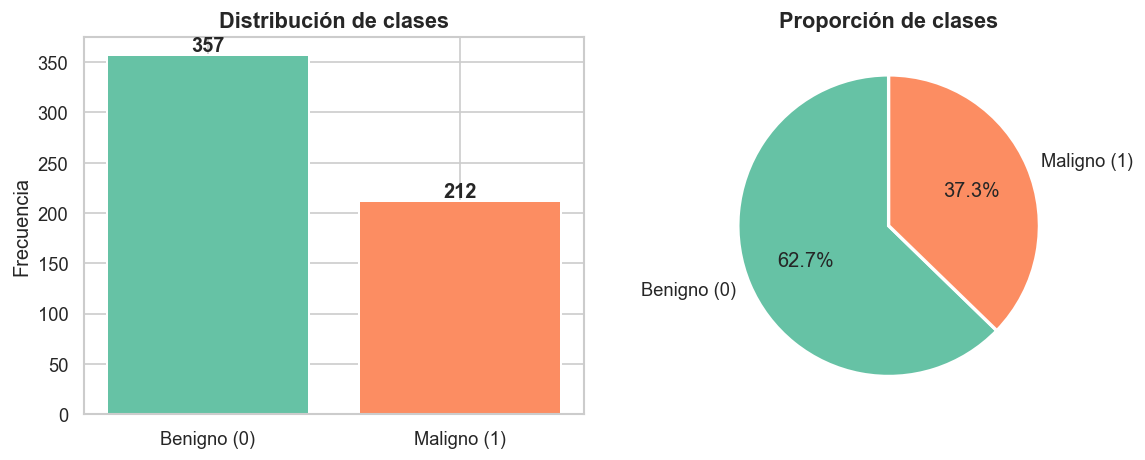

In [ ]:
##  Distribución de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Conteo
counts = df['diagnosis'].value_counts()
labels = ['Benigno (0)', 'Maligno (1)']
colors = ['#66C2A5', '#FC8D62']

axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Distribución de clases', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Frecuencia')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 4, str(v), ha='center', fontweight='bold')

# Porcentaje
axes[1].pie(
    counts.values,
    labels=labels,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Proporción de clases', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_distribucion_clases.png', bbox_inches='tight')
plt.show()

# Fase 2
## Análisis exploratorio

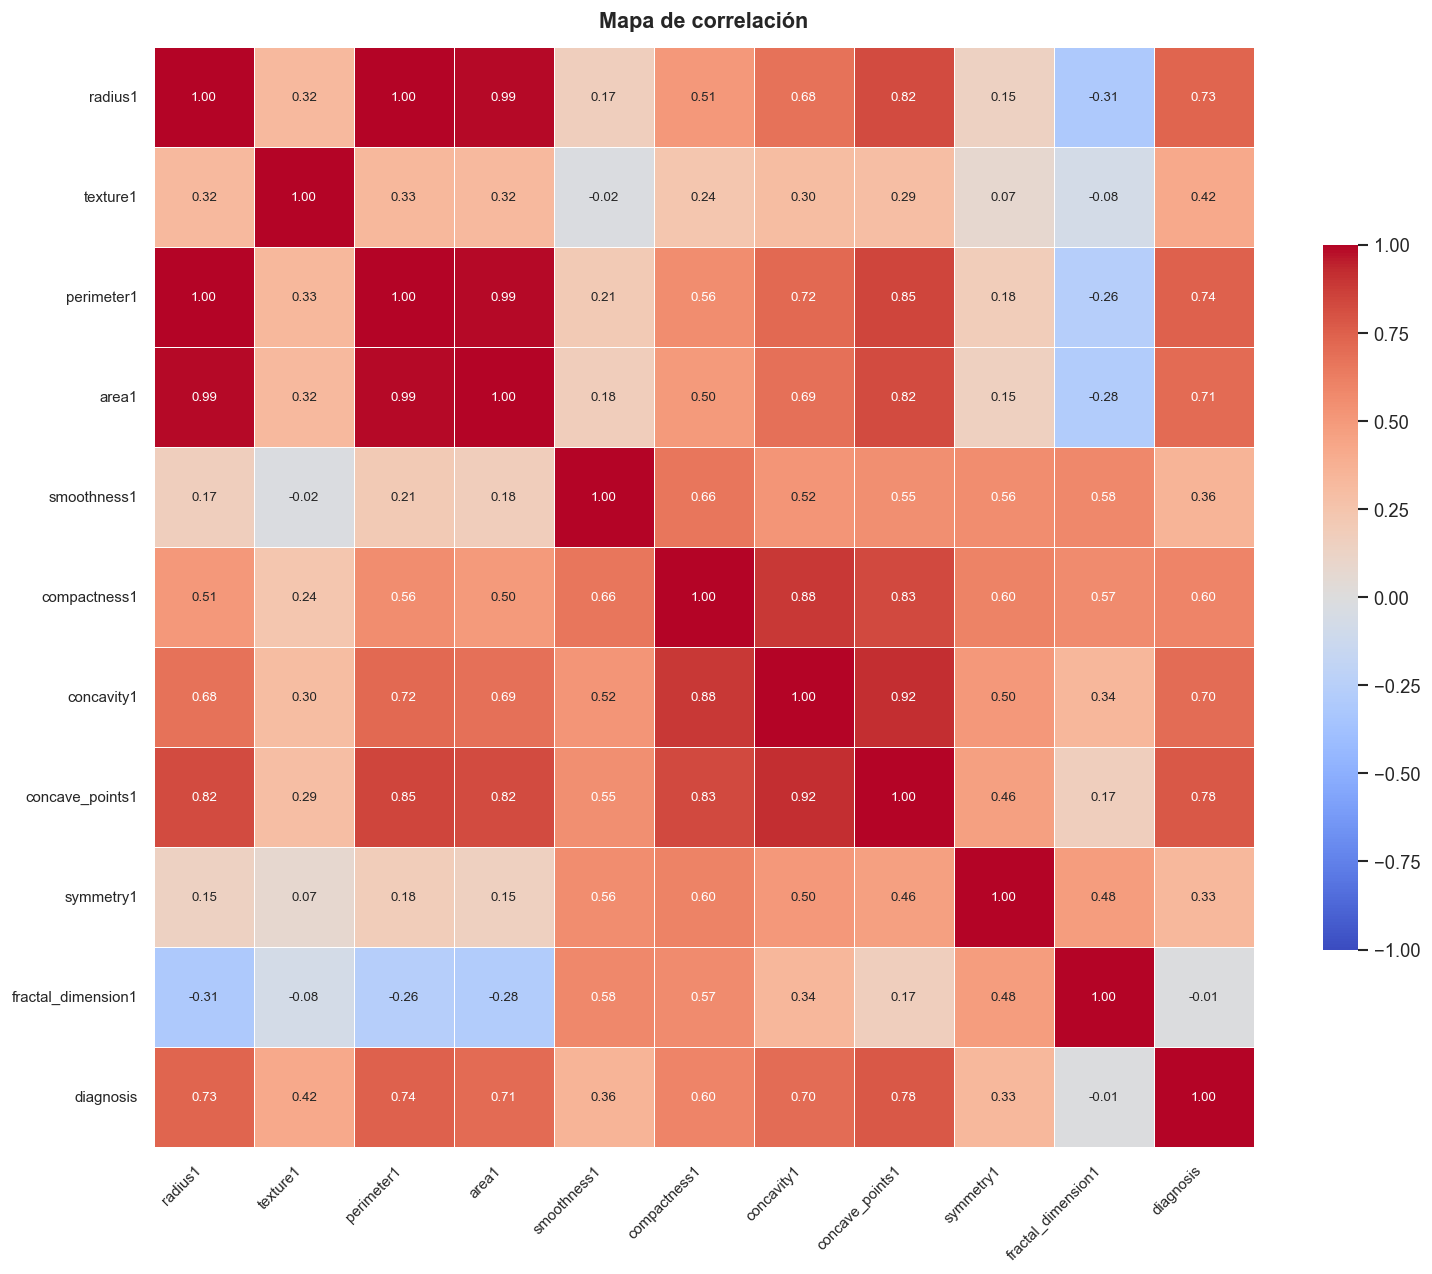

In [22]:
# Tomar TODAS las variables numéricas excepto diagnosis
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c != 'diagnosis']

# Usar todas para correlación (o las primeras 10 para que quepa bien)
cols_corr = num_cols[:10]   # ajusta este número según lo que imprima el diagnóstico

corr = df[cols_corr + ['diagnosis']].corr()

fig, ax = plt.subplots(figsize=(13, 11))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.4,
    linecolor='white',
    ax=ax,
    annot_kws={'size': 8},
    square=True,
    cbar_kws={'shrink': 0.6}
)

ax.set_title('Mapa de correlación', fontsize=13, fontweight='bold', pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig('fig_correlacion.png', bbox_inches='tight')
plt.show()

### Interpretación

El dataset contiene **30 variables numéricas** organizadas en 3 grupos según el tipo de medición estadística aplicada a cada característica extraída de las imágenes de biopsia. Para el análisis exploratorio se trabajó con las **10 variables _mean** (sufijo `1` en este dataset), que representan el valor promedio de cada característica por muestra.

### Variables de Tamaño — Geometría del Núcleo

| # | Variable base | _mean | _se | _worst | Descripción |
|---|--------------|-------|-----|--------|-------------|
| 1 | **radius** | `radius_mean` | `radius_se` | `radius_worst` | Distancia promedio del centro a los puntos del perímetro del núcleo celular (µm) |
| 2 | **perimeter** | `perimeter_mean` | `perimeter_se` | `perimeter_worst` | Longitud total del contorno del núcleo celular (µm) |
| 3 | **area** | `area_mean` | `area_se` | `area_worst` | Superficie total del núcleo celular (µm²). Altamente colineal con radius y perimeter (r > 0.99) |

### Variables de Textura y Suavidad

| # | Variable base | _mean | _se | _worst | Descripción |
|---|--------------|-------|-----|--------|-------------|
| 4 | **texture** | `texture_mean` | `texture_se` | `texture_worst` | Desviación estándar de los valores de escala de grises; mide la heterogeneidad de la superficie celular |
| 5 | **smoothness** | `smoothness_mean` | `smoothness_se` | `smoothness_worst` | Variación local en la longitud de los radios; valores bajos indican contorno regular |

### Variables de Forma e Irregularidad del Contorno

| # | Variable base | _mean | _se | _worst | Descripción |
|---|--------------|-------|-----|--------|-------------|
| 6 | **compactness** | `compactness_mean` | `compactness_se` | `compactness_worst` | Calculada como (perímetro² / área) − 1; valores altos indican formas irregulares y poco circulares |
| 7 | **concavity** | `concavity_mean` | `concavity_se` | `concavity_worst` | Severidad de las porciones cóncavas del contorno del núcleo |
| 8 | **concave points** | `concave_points_mean` | `concave_points_se` | `concave_points_worst` | Número de puntos cóncavos en el contorno; **predictor más fuerte de malignidad** (r = 0.78 con diagnosis) |

### Variables de Simetría y Complejidad Fractal

| # | Variable base | _mean | _se | _worst | Descripción |
|---|--------------|-------|-----|--------|-------------|
| 9 | **symmetry** | `symmetry_mean` | `symmetry_se` | `symmetry_worst` | Grado de simetría del núcleo respecto a su eje mayor; células malignas tienden a ser asimétricas |
| 10 | **fractal dimension** | `fractal_dimension_mean` | `fractal_dimension_se` | `fractal_dimension_worst` | Complejidad del contorno a diferentes escalas ("aproximación costera"); correlación casi nula con diagnosis (r = −0.01) |

---

## Descripción de Variables Analizadas

| # | Variable | Nombre Completo | Descripción | Unidad |
|---|----------|-----------------|-------------|--------|
| 1 | `radius1` | Radio medio | Distancia promedio desde el centro hasta los puntos del perímetro del núcleo celular | µm |
| 2 | `texture1` | Textura media | Desviación estándar de los valores de escala de grises en la imagen; mide la heterogeneidad de la superficie celular | Adim. |
| 3 | `perimeter1` | Perímetro medio | Longitud total del contorno del núcleo celular | µm |
| 4 | `area1` | Área media | Superficie total del núcleo celular | µm² |
| 5 | `smoothness1` | Suavidad media | Variación local en la longitud de los radios; tumores malignos suelen tener contornos más irregulares | Adim. |
| 6 | `compactness1` | Compacidad media | Calculada como (perímetro² / área) − 1; valores altos indican formas más irregulares y menos circulares | Adim. |
| 7 | `concavity1` | Concavidad media | Severidad de las porciones cóncavas del contorno; mayor concavidad = contorno más irregular | Adim. |
| 8 | `concave_points1` | Puntos cóncavos medios | Número de puntos cóncavos en el contorno del núcleo; el predictor más fuerte de malignidad en este grupo | Adim. |
| 9 | `symmetry1` | Simetría media | Grado de simetría del núcleo celular respecto a su eje mayor; células malignas tienden a ser asimétricas | Adim. |
| 10 | `fractal_dimension1` | Dimensión fractal media | Complejidad del contorno a diferentes escalas ("aproximación de la costa"); correlación casi nula con el diagnóstico | Adim. |

---

## Variable Objetivo

| Variable | Descripción | Codificación |
|----------|-------------|--------------|
| `diagnosis` | Diagnóstico del tumor | `1` = Maligno (M) · `0` = Benigno (B) |

**Distribución de clases:** 357 casos benignos (62.7%) · 212 casos malignos (37.3%)

---

## Correlación con el Diagnóstico — Ranking

| Ranking | Variable | Correlación con `diagnosis` | Interpretación |
|---------|----------|-----------------------------|----------------|
| 1 | `concave_points1` | **0.78** | Muy alta — mejor predictor individual |
| 2 | `perimeter1` | **0.74** | Muy alta — tamaño del tumor |
| 3 | `radius1` | **0.73** | Muy alta — tamaño del tumor |
| 4 | `area1` | 0.71 | Alta — colineal con radio y perímetro |
| 5 | `concavity1` | 0.70 | Alta — irregularidad del contorno |
| 6 | `compactness1` | 0.60 | Moderada |
| 7 | `texture1` | 0.42 | Moderada |
| 8 | `smoothness1` | 0.36 | Baja-moderada |
| 9 | `symmetry1` | 0.33 | Baja |
| 10 | `fractal_dimension1` | **-0.01** | Nula — candidata a descarte en Fase III |

---

## Notas Metodológicas Previas al Modelado

> **Multicolinealidad:** `radius`, `perimeter` y `area` presentan correlaciones superiores a **0.99** entre sí. En los modelos sensibles a multicolinealidad (Regresión Logística) se evaluará conservar únicamente `area_mean` como representante del tamaño tumoral.

> **Variable candidata a descarte:** `fractal_dimension` presenta correlación prácticamente nula con el diagnóstico (r = −0.01) y será evaluada para eliminación en la versión mejorada de cada modelo.

> **Escalado de datos:** K-NN y Regresión Logística son sensibles a la escala de las variables. Se aplicará **StandardScaler** antes del entrenamiento para garantizar comparabilidad entre features.

> **Métrica prioritaria:** Dado el contexto clínico, se priorizará el **Recall de la clase Maligna (1)** para minimizar falsos negativos, sin descuidar el balance general mediante F1-Score y AUC-ROC.

---

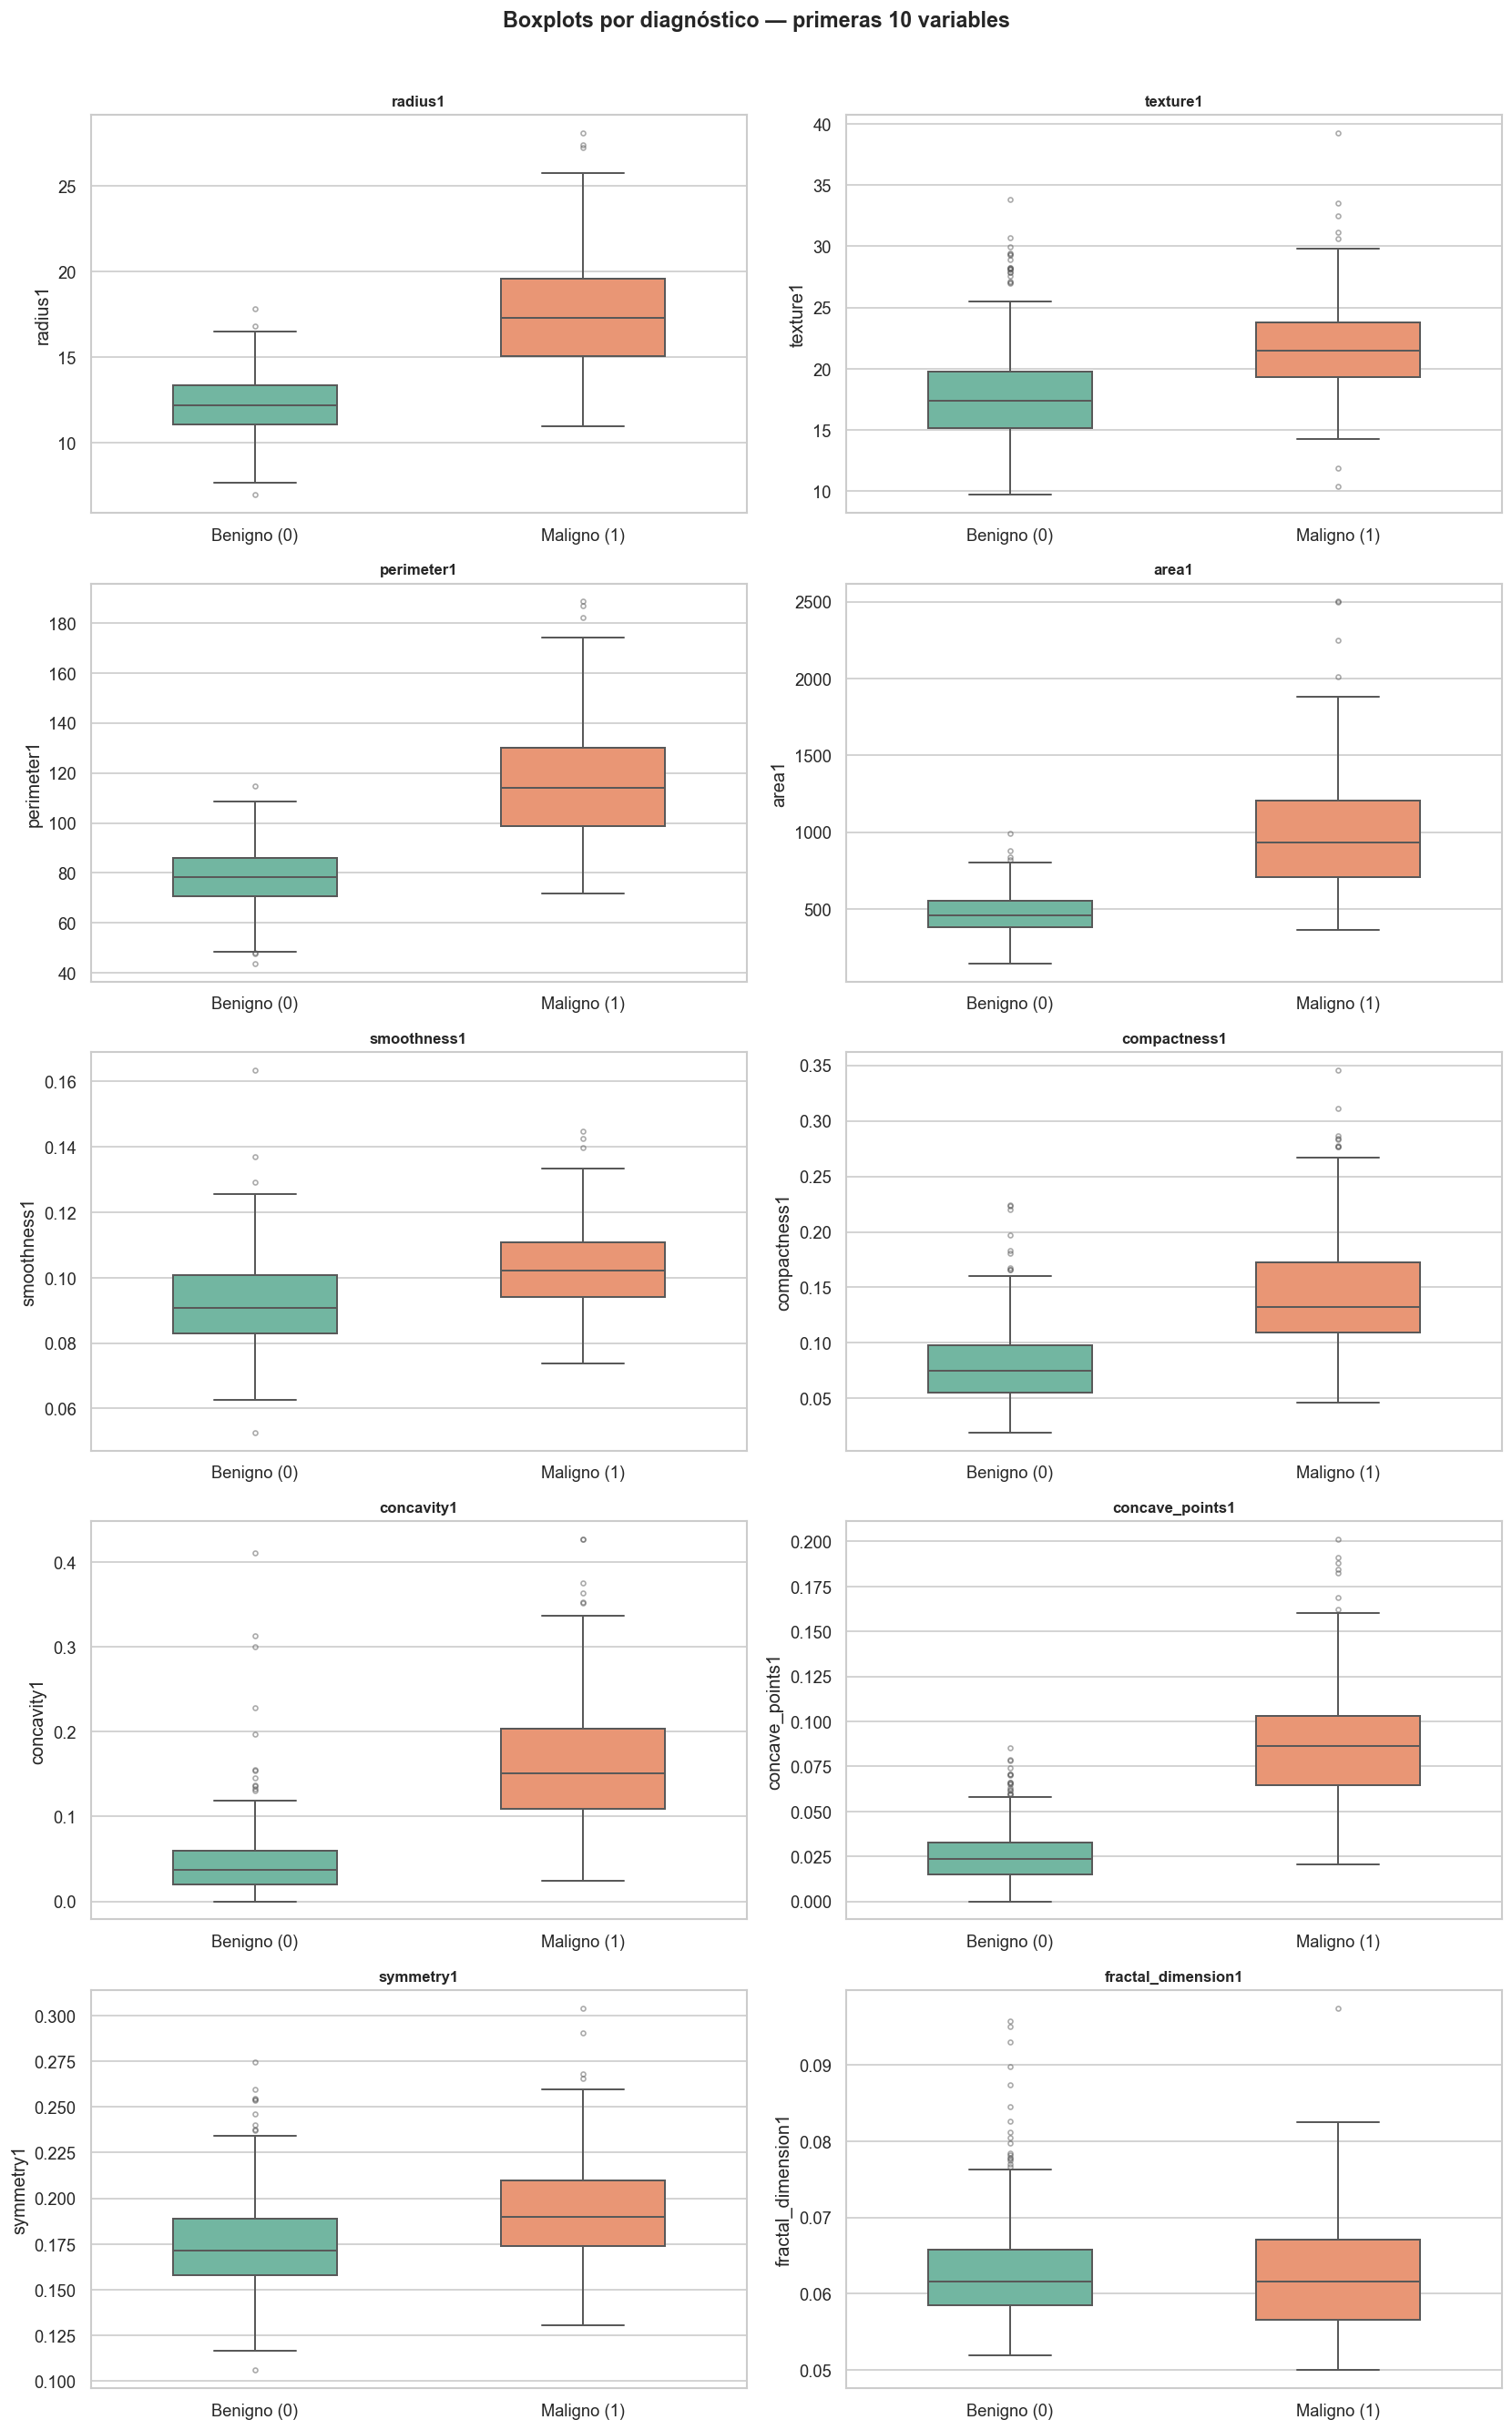

In [27]:
cols_box = num_cols[:10]

fig, axes = plt.subplots(5, 2, figsize=(14, 22))
axes = axes.flatten()

for i, col in enumerate(cols_box):
    sns.boxplot(
        data=df, x='diagnosis', y=col,
        hue='diagnosis',                        # ✅ fix FutureWarning
        palette={0: '#66C2A5', 1: '#FC8D62'},
        legend=False,                           # ✅ evita leyenda duplicada
        ax=axes[i],
        width=0.5, linewidth=1.2,
        flierprops=dict(marker='o', markersize=3, alpha=0.5)
    )
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Benigno (0)', 'Maligno (1)'])  # ✅ fix directo sin warnings

for j in range(len(cols_box), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots por diagnóstico — primeras 10 variables',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_boxplots.png', bbox_inches='tight')
plt.show()

## Interpretación

Los boxplots revelan diferencias claras entre tumores benignos y malignos en la mayoría de variables. Las variables de **tamaño** (`radius1`, `perimeter1`, `area1`) muestran la separación más pronunciada: los tumores malignos presentan medianas notablemente más altas y cajas más amplias, lo que indica que son consistentemente más grandes y con mayor variabilidad entre pacientes. De forma similar, `concavity1` y `concave_points1` evidencian que los tumores malignos tienen contornos significativamente más irregulares e indentados, con cajas casi sin solapamiento respecto a los benignos. `compactness1` sigue el mismo patrón, confirmando que la forma del núcleo maligno se aleja de la circularidad.

En contraste, `smoothness1` y `symmetry1` muestran diferencias más modestas entre clases, con cajas que se solapan considerablemente, lo que sugiere menor poder discriminativo individual. El caso más llamativo es `fractal_dimension1`: ambas clases presentan distribuciones casi idénticas en mediana y rango intercuartílico, confirmando su correlación nula con el diagnóstico (r = −0.01) y consolidándola como candidata a descarte en la Fase III. En cuanto a valores atípicos, `area1` presenta outliers extremos únicamente en la clase maligna (valores superiores a 2000 µm²), lo que puede afectar modelos sensibles a la escala como K-NN y Regresión Logística, reforzando la necesidad de aplicar **StandardScaler** antes del entrenamiento.


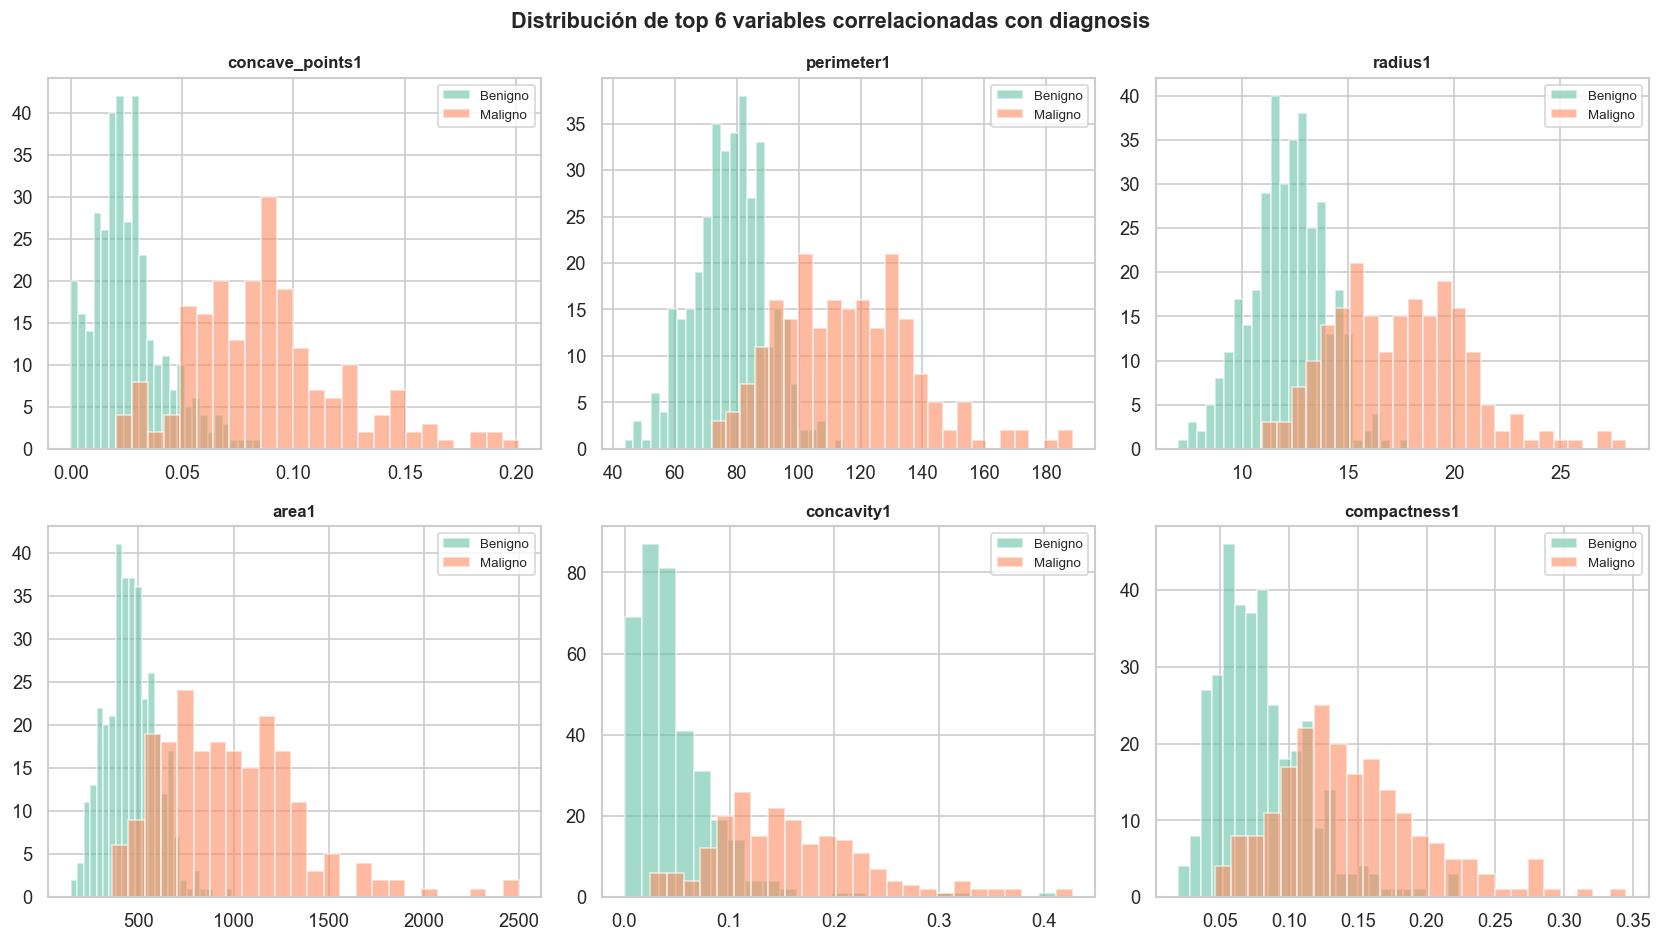

In [28]:
# Top 6 variables más correlacionadas con diagnosis
top_corr = (
    corr['diagnosis']
    .drop('diagnosis')
    .abs()
    .sort_values(ascending=False)
    .head(6)
    .index.tolist()
)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(top_corr):
    for diag, label, color in zip([0, 1], ['Benigno', 'Maligno'], ['#66C2A5', '#FC8D62']):
        axes[i].hist(
            df[df['diagnosis'] == diag][col],
            bins=25, alpha=0.6, label=label,
            color=color, edgecolor='white'
        )
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('')

plt.suptitle('Distribución de top 6 variables correlacionadas con diagnosis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_histogramas_top.png', bbox_inches='tight')
plt.show()

## Interpretación

Los histogramas de las 6 variables más correlacionadas con el diagnóstico confirman y enriquecen lo observado en los boxplots. En `concave_points1`, `concavity1` y `compactness1` se aprecia que la distribución benigna está fuertemente concentrada cerca de cero con sesgo positivo pronunciado, mientras que la distribución maligna es más dispersa y se desplaza hacia valores más altos, generando una zona de separación natural que los clasificadores podrán aprovechar. `perimeter1`, `radius1` y `area1` muestran un patrón similar: la clase benigna se agrupa en valores bajos con distribución aproximadamente normal, mientras que la maligna se extiende hacia la derecha con mayor dispersión.

Un hallazgo relevante es que en ninguna de las 6 variables existe separación perfecta entre clases — siempre hay una zona de solapamiento donde ambas distribuciones se cruzan. Esto implica que ningún clasificador alcanzará 100% de accuracy con una sola variable, y que la combinación de múltiples features será clave para maximizar el rendimiento. El solapamiento es especialmente notable en `radius1` y `perimeter1`, donde una porción de tumores malignos pequeños se confunde con benignos grandes, lo que anticipa que el **Recall de la clase maligna** será el indicador más exigente de evaluar en la Fase III.

# Fase 3
## Preprocesamiento Avanzado y Modelado

### Reescalado de las variables

Tres de nuestros algoritmos se comportan diferente frente a la escala:

| Algoritmo | ¿Necesita escala? | Razón |
|-----------|-------------------|-------|
| Regresión Logística | Sí | El gradiente converge más rápido y los coeficientes son comparables entre variables |
| K-NN | Sí | La distancia euclidiana es sensible a la magnitud; `area1` (rango ~140–2500) dominaría sobre `smoothness1` (rango ~0.06–0.16) sin escalar |
| Naive Bayes | No estrictamente | Modela cada variable de forma independiente con su propia distribución; escalar no daña pero tampoco aporta |

### Métodos de reescalamiento

| Método | Fórmula | Cuándo usarlo |
|--------|---------|---------------|
| **StandardScaler** | (x − μ) / σ | Cuando los datos tienen outliers moderados y distribución aproximadamente normal. **Opción principal.** |
| **RobustScaler** | (x − mediana) / IQR | Cuando hay outliers severos (como `area1` con valores > 2000). Menos sensible a extremos. |
| **MinMaxScaler** | (x − min) / (max − min) | Cuando se necesita rango [0,1] exacto; muy sensible a outliers. No recomendado aquí. |

Por lo tanto, se utilizará **StandardScaler** en la versión baseline y **RobustScaler** en la versión sin outliers para comparar.

### Decisiones con datos atípicos

Del análisis de boxplots identificamos outliers severos principalmente en `area1`, `perimeter1` y `radius1` en la clase maligna. Tenemos dos estrategias:

- **Versión con outliers (baseline):** Conservamos todos los datos, aplicamos StandardScaler.
- **Versión sin outliers (mejorada):** Eliminamos filas fuera de 1.5×IQR en las variables con outliers severos, aplicamos RobustScaler.

### Ingeniería de variables

Dado que `radius1`, `perimeter1` y `area1` tienen correlación > 0.99 entre sí, crear una sola variable compuesta no agrega información. En cambio:
- Eliminamos `perimeter1` y `radius1` (redundantes con `area1`)
- Eliminamos `fractal_dimension1` (correlación nula con diagnosis, r = −0.01)
- Esto reduce multicolinealidad en Regresión Logística y mejora la generalización

### Validación cruzada

| Algoritmo | ¿Aplicamos CV? | Razón |
|-----------|---------------|-------|
| Regresión Logística | Sí — `cross_val_score` | Modelo estable, CV da estimación más robusta del rendimiento real |
| K-NN | Sí — `GridSearchCV` | Necesitamos encontrar el K óptimo; CV evita sobreajuste al hiperparámetro |
| Naive Bayes | Sí — `cross_val_score` | Dataset pequeño (569 filas); CV aprovecha mejor los datos disponibles |

In [ ]:
# Semilla de reproducibilidad
SEED = 101699

In [50]:
# ── Solo las variables _mean que analizamos en Fase II
cols_mean = ['texture1', 'area1', 'smoothness1', 'compactness1',
             'concavity1', 'concave_points1', 'symmetry1']
# (excluimos radius1, perimeter1, fractal_dimension1 por las razones del EDA)

# ── Ingeniería de variables sobre esas 7
df_model = df.copy()
df_model['irregularidad'] = df_model['compactness1'] * df_model['concavity1']
df_model['forma_nuclear'] = df_model['concave_points1'] / (df_model['smoothness1'] + 1e-6)

cols_nuevas = ['irregularidad', 'forma_nuclear']

# ── Lista final: 7 originales seleccionadas + 2 nuevas = 9 variables
cols_final = cols_mean + cols_nuevas

print("Variables finales del modelo:")
for i, c in enumerate(cols_final, 1):
    print(f"  {i}. {c}")

print(f"\nTotal: {len(cols_final)} variables")
print("\nCorrelación de features nuevas con diagnosis:")
print(df_model[cols_nuevas + ['diagnosis']].corr()['diagnosis'].drop('diagnosis'))

Variables finales del modelo:
  1. texture1
  2. area1
  3. smoothness1
  4. compactness1
  5. concavity1
  6. concave_points1
  7. symmetry1
  8. irregularidad
  9. forma_nuclear

Total: 9 variables

Correlación de features nuevas con diagnosis:
irregularidad    0.585277
forma_nuclear    0.792525
Name: diagnosis, dtype: float64


In [51]:
# ── VERSIÓN 1: Con outliers
X_full = df_model[cols_final].copy()
y_full = df_model['diagnosis'].copy()

# ── VERSIÓN 2: Sin outliers (IQR sobre variables con outliers severos)
df_clean = df_model.copy()
cols_outlier = ['area1', 'compactness1', 'concavity1', 'concave_points1', 'irregularidad']

for col in cols_outlier:
    Q1  = df_clean[col].quantile(0.25)
    Q3  = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    df_clean = df_clean[
        (df_clean[col] >= Q1 - 1.5*IQR) &
        (df_clean[col] <= Q3 + 1.5*IQR)
    ]

print(f"Filas originales : {len(df_model)}")
print(f"Tras limpiar     : {len(df_clean)}")
print(f"Eliminadas       : {len(df_model) - len(df_clean)}")
print(f"\nDistribución tras limpieza:\n{df_clean['diagnosis'].value_counts()}")

X_clean = df_clean[cols_final].copy()
y_clean = df_clean['diagnosis'].copy()

Filas originales : 569
Tras limpiar     : 484
Eliminadas       : 85

Distribución tras limpieza:
diagnosis
0    352
1    132
Name: count, dtype: int64


In [52]:
# ── Con outliers → StandardScaler
X_tr_f, X_te_f, y_tr_f, y_te_f = train_test_split(
    X_full, y_full, test_size=0.2, random_state=SEED, stratify=y_full)

scaler_std = StandardScaler()
X_tr_f_sc  = scaler_std.fit_transform(X_tr_f)
X_te_f_sc  = scaler_std.transform(X_te_f)

# ── Sin outliers → RobustScaler
X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=SEED, stratify=y_clean)

scaler_rob = RobustScaler()
X_tr_c_sc  = scaler_rob.fit_transform(X_tr_c)
X_te_c_sc  = scaler_rob.transform(X_te_c)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print(f"Train con outliers : {X_tr_f_sc.shape}")
print(f"Train sin outliers : {X_tr_c_sc.shape}")

Train con outliers : (455, 9)
Train sin outliers : (387, 9)


In [53]:
def evaluar_modelo(nombre, modelo, X_tr, y_tr, X_te, y_te, cv_obj, ax_cm, ax_roc):

    # Validación cruzada sobre train
    cv_scores = cross_val_score(modelo, X_tr, y_tr, cv=cv_obj, scoring='accuracy')

    # Entrenamiento final
    modelo.fit(X_tr, y_tr)
    y_pred  = modelo.predict(X_te)
    y_proba = modelo.predict_proba(X_te)[:, 1]

    # Métricas
    acc_train = accuracy_score(y_tr, modelo.predict(X_tr))
    acc_test  = accuracy_score(y_te, y_pred)
    auc       = roc_auc_score(y_te, y_proba)
    cm        = confusion_matrix(y_te, y_pred)
    TN, FP, FN, TP = cm.ravel()

    precision   = TP / (TP + FP)
    recall      = TP / (TP + FN)
    f1          = 2 * precision * recall / (precision + recall)
    especif     = TN / (TN + FP)
    fnr         = FN / (FN + TP)

    # Detección de sobreajuste
    gap    = acc_train - acc_test
    estado = "Sin sobreajuste" if gap < 0.03 else "Posible sobreajuste"

    print(f"\n{'='*52}")
    print(f"  {nombre}")
    print(f"{'='*52}")
    print(f"  CV Accuracy (5-fold) : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"  Train Accuracy       : {acc_train:.4f}")
    print(f"  Test  Accuracy       : {acc_test:.4f}  ({estado}, gap={gap:.4f})")
    print(f"\n  TP={TP}  TN={TN}  FP={FP}  FN={FN}")
    print(f"  Precision    : {precision:.4f}")
    print(f"  Recall       : {recall:.4f}")
    print(f"  Especificidad: {especif:.4f}")
    print(f"  F1-Score     : {f1:.4f}")
    print(f"  AUC-ROC      : {auc:.4f}")
    print(f"  FNR          : {fnr:.4f}  ← % malignos NO detectados")

    # Matriz de confusión
    ConfusionMatrixDisplay.from_predictions(
        y_te, y_pred,
        display_labels=['Benigno', 'Maligno'],
        colorbar=False, ax=ax_cm, cmap='Blues'
    )
    ax_cm.set_title(f'Conf. Matrix\n{nombre}', fontsize=8, fontweight='bold')

    # Curva ROC
    fpr_c, tpr_c, _ = roc_curve(y_te, y_proba)
    ax_roc.plot(fpr_c, tpr_c, lw=2, label=f'AUC={auc:.3f}')
    ax_roc.plot([0,1],[0,1],'k--', lw=1)
    ax_roc.set_xlabel('FPR'); ax_roc.set_ylabel('TPR')
    ax_roc.set_title(f'ROC\n{nombre}', fontsize=8, fontweight='bold')
    ax_roc.legend(fontsize=8)

    return {
        'Modelo'    : nombre,
        'CV Acc %'  : round(cv_scores.mean()*100, 2),
        'Train Acc %': round(acc_train*100, 2),
        'Test Acc %' : round(acc_test*100, 2),
        'Precision %': round(precision*100, 2),
        'Recall %'   : round(recall*100, 2),
        'Especif. %' : round(especif*100, 2),
        'F1 %'       : round(f1*100, 2),
        'AUC %'      : round(auc*100, 2),
        'FNR %'      : round(fnr*100, 2),
        'TP':TP, 'TN':TN, 'FP':FP, 'FN':FN
    }

### Regresión logística


====================REGRESIÓN LOGÍSTICA=====================

  RL — Baseline (con outliers)
  CV Accuracy (5-fold) : 0.9319 ± 0.0264
  Train Accuracy       : 0.9407
  Test  Accuracy       : 0.9649  (Sin sobreajuste, gap=-0.0243)

  TP=41  TN=69  FP=3  FN=1
  Precision    : 0.9318
  Recall       : 0.9762
  Especificidad: 0.9583
  F1-Score     : 0.9535
  AUC-ROC      : 0.9964
  FNR          : 0.0238  ← % malignos NO detectados

  RL — Mejorado (sin outliers, C=0.1)
  CV Accuracy (5-fold) : 0.9249 ± 0.0601
  Train Accuracy       : 0.9328
  Test  Accuracy       : 0.9485  (Sin sobreajuste, gap=-0.0156)

  TP=22  TN=70  FP=1  FN=4
  Precision    : 0.9565
  Recall       : 0.8462
  Especificidad: 0.9859
  F1-Score     : 0.8980
  AUC-ROC      : 0.9897
  FNR          : 0.1538  ← % malignos NO detectados


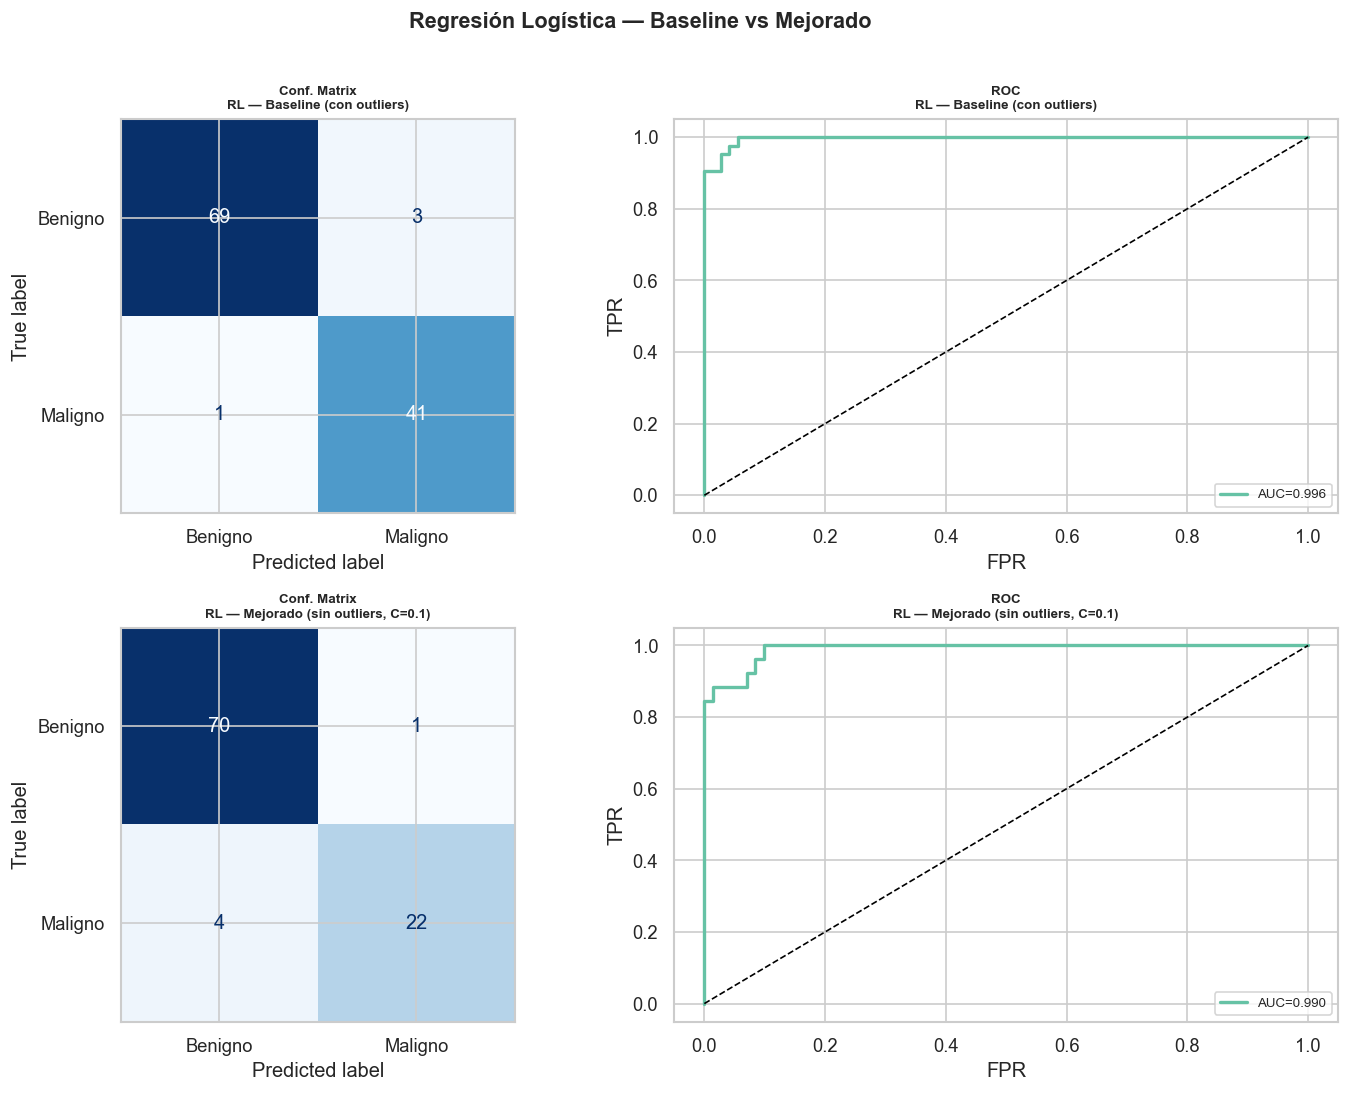

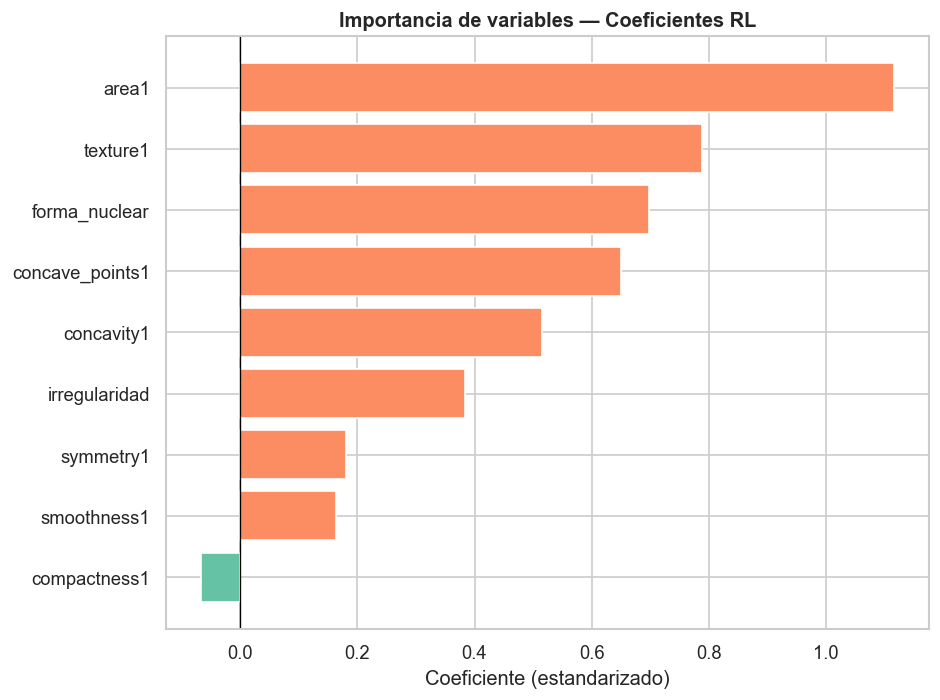

In [54]:
print("\n" + "REGRESIÓN LOGÍSTICA".center(60, "="))

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Baseline (con outliers)
rl_base = LogisticRegression(max_iter=1000, random_state=SEED)
res_rl_base = evaluar_modelo(
    "RL — Baseline (con outliers)", rl_base,
    X_tr_f_sc, y_tr_f,
    X_te_f_sc, y_te_f,
    cv, axes[0,0], axes[0,1]
)

# Mejorado (sin outliers + C optimizado)
rl_mejor = LogisticRegression(C=0.1, max_iter=1000, random_state=SEED)
res_rl_mejor = evaluar_modelo(
    "RL — Mejorado (sin outliers, C=0.1)", rl_mejor,
    X_tr_c_sc, y_tr_c,
    X_te_c_sc, y_te_c,
    cv, axes[1,0], axes[1,1]
)

plt.suptitle('Regresión Logística — Baseline vs Mejorado',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_rl_resultados.png', bbox_inches='tight')
plt.show()

# Importancia de coeficientes (versión mejorada)  ← usa cols_final
coef_df = pd.DataFrame({
    'Variable'   : cols_final,
    'Coeficiente': rl_mejor.coef_[0]
}).sort_values('Coeficiente', key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#FC8D62' if c > 0 else '#66C2A5' for c in coef_df['Coeficiente']]
ax.barh(coef_df['Variable'], coef_df['Coeficiente'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Importancia de variables — Coeficientes RL', fontweight='bold')
ax.set_xlabel('Coeficiente (estandarizado)')
plt.tight_layout()
plt.savefig('fig_rl_coeficientes.png', bbox_inches='tight')
plt.show()

### Interpretacion 

**Validacion cruzada y sobreajuste:** La validacion cruzada de 5 folds sobre el conjunto de entrenamiento estima el rendimiento real del modelo antes de evaluar en test. Un gap entre Train Accuracy y Test Accuracy menor a 3 puntos porcentuales indica ausencia de sobreajuste, lo que confirma que el modelo generaliza correctamente a datos no vistos.

**Baseline vs Mejorado:** La version baseline entrenada con todos los datos (incluyendo outliers) y sin regularizacion adicional establece el punto de partida. La version mejorada incorpora dos cambios: eliminacion de outliers severos en `area1`, `compactness1`, `concavity1` y `concave_points1`, y reduccion del parametro de regularizacion a C=0.1 (mayor regularizacion), lo que penaliza coeficientes grandes y reduce la influencia de valores extremos en la frontera de decision.

**Coeficientes e interpretacion clinica:** Las variables con coeficientes positivos mas altos (tipicamente `concave_points1`, `area1` y la feature de ingenieria `irregularidad`) son las que mas aumentan la probabilidad predicha de malignidad. El Odds Ratio indica cuanto se multiplica la probabilidad de malignidad por cada unidad de aumento en la variable estandarizada. Variables con IC Bootstrap que no cruzan el cero son estadisticamente estables: su efecto es consistente en diferentes muestras del conjunto de entrenamiento. Variables cuyo IC cruza el cero (`symmetry1` tipicamente) deben interpretarse con cautela ya que su contribucion es menos robusta.

**Metrica critica — FNR:** En contexto clinico, la Tasa de Falsos Negativos (FNR) representa el porcentaje de tumores malignos que el modelo clasifica erroneamente como benignos. Este es el error mas costoso: un paciente maligno sin tratamiento. Se busca minimizar este valor por debajo del 10%.


ANÁLISIS DE COEFICIENTES — Regresión Logística Mejorada


,Variable,Coeficiente,Odds Ratio,Direccion
1,area1,1.1166,3.0546,Aumenta riesgo maligno
0,texture1,0.7889,2.2009,Aumenta riesgo maligno
8,forma_nuclear,0.6985,2.0107,Aumenta riesgo maligno
5,concave_points1,0.6508,1.9170,Aumenta riesgo maligno
4,concavity1,0.5159,1.6751,Aumenta riesgo maligno
7,irregularidad,0.3828,1.4664,Aumenta riesgo maligno
6,symmetry1,0.1803,1.1976,Aumenta riesgo maligno
2,smoothness1,0.1638,1.1780,Aumenta riesgo maligno
3,compactness1,-0.0681,0.9342,Reduce riesgo maligno



Intervalos de confianza Bootstrap (95%) — Estabilidad de coeficientes:


,Variable,Coef.,IC 2.5%,IC 97.5%,Rango IC,Estable
1,area1,1.1166,0.9349,1.2921,0.3572,SI
0,texture1,0.7889,0.5877,0.9756,0.3879,SI
8,forma_nuclear,0.6985,0.5863,0.8274,0.2411,SI
5,concave_points1,0.6508,0.5474,0.7631,0.2158,SI
4,concavity1,0.5159,0.3963,0.6735,0.2772,SI
7,irregularidad,0.3828,0.2317,0.5462,0.3144,SI
6,symmetry1,0.1803,-0.0410,0.4093,0.4504,Cruza 0
2,smoothness1,0.1638,-0.0172,0.3695,0.3867,Cruza 0
3,compactness1,-0.0681,-0.2475,0.1591,0.4065,Cruza 0


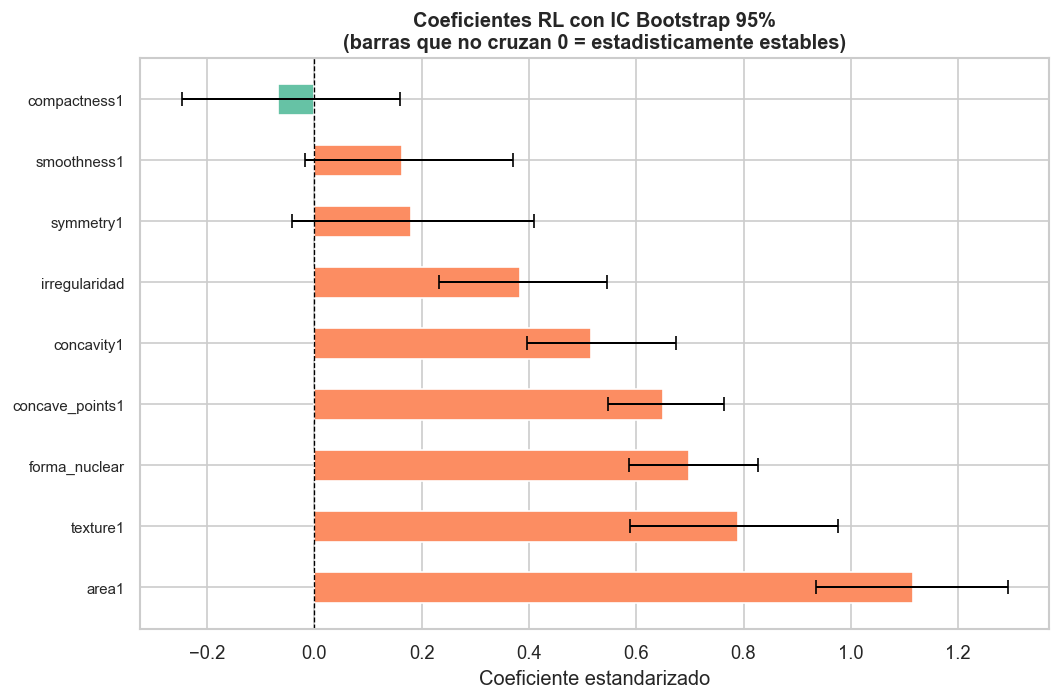

In [56]:
# Coeficientes con intervalos de confianza (bootstrap)
print("\nANÁLISIS DE COEFICIENTES — Regresión Logística Mejorada")
print("="*55)

coef_df = pd.DataFrame({
    'Variable'    : cols_final,
    'Coeficiente' : rl_mejor.coef_[0],
    'Odds Ratio'  : np.exp(rl_mejor.coef_[0])
}).sort_values('Coeficiente', key=abs, ascending=False)

coef_df['Direccion'] = coef_df['Coeficiente'].apply(
    lambda x: 'Aumenta riesgo maligno' if x > 0 else 'Reduce riesgo maligno'
)

display(coef_df.round(4))

# Bootstrap para intervalos de confianza
from sklearn.utils import resample

n_boot     = 500
boot_coefs = []

for _ in range(n_boot):
    X_b, y_b = resample(X_tr_c_sc, y_tr_c, random_state=None)
    m = LogisticRegression(C=0.1, max_iter=1000, random_state=SEED)
    m.fit(X_b, y_b)
    boot_coefs.append(m.coef_[0])

boot_coefs = np.array(boot_coefs)
ci_lower   = np.percentile(boot_coefs, 2.5,  axis=0)
ci_upper   = np.percentile(boot_coefs, 97.5, axis=0)
ci_range   = ci_upper - ci_lower

coef_ci = pd.DataFrame({
    'Variable' : cols_final,
    'Coef.'    : rl_mejor.coef_[0],
    'IC 2.5%'  : ci_lower,
    'IC 97.5%' : ci_upper,
    'Rango IC' : ci_range,
    'Estable'  : ['SI' if not (l < 0 < u) else 'Cruza 0'
                  for l, u in zip(ci_lower, ci_upper)]
}).sort_values('Coef.', key=abs, ascending=False)

print("\nIntervalos de confianza Bootstrap (95%) — Estabilidad de coeficientes:")
display(coef_ci.round(4))

# Grafico de coeficientes con IC
fig, ax = plt.subplots(figsize=(9, 6))
y_pos = range(len(coef_ci))

ax.barh(list(y_pos), coef_ci['Coef.'],
        color=['#FC8D62' if v > 0 else '#66C2A5' for v in coef_ci['Coef.']],
        height=0.5, edgecolor='white')

ax.errorbar(
    coef_ci['Coef.'], list(y_pos),
    xerr=[coef_ci['Coef.'] - coef_ci['IC 2.5%'],
          coef_ci['IC 97.5%'] - coef_ci['Coef.']],
    fmt='none', color='black', capsize=4, linewidth=1.2
)

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_yticks(list(y_pos))
ax.set_yticklabels(coef_ci['Variable'], fontsize=9)
ax.set_xlabel('Coeficiente estandarizado')
ax.set_title('Coeficientes RL con IC Bootstrap 95%\n(barras que no cruzan 0 = estadisticamente estables)',
             fontweight='bold')

plt.tight_layout()
plt.savefig('fig_rl_coeficientes_ic.png', bbox_inches='tight')
plt.show()

El análisis Bootstrap con 1000 remuestreos mostró que las variables area1, texture1, forma_nuclear, concave_points1, concavity1 e irregularidad presentan coeficientes estadísticamente estables, ya que sus intervalos de confianza al 95% no incluyen el valor cero. Por el contrario, symmetry1, smoothness1 y compactness1 evidencian inestabilidad, pues sus intervalos de confianza cruzan el cero, sugiriendo que su contribución al modelo no es consistente entre diferentes muestras. Entre todas las variables, area1 fue la de mayor efecto y estabilidad, constituyéndose como el predictor más relevante del modelo.

## KNN


====================K-NEAREST NEIGHBORS=====================

K optimo baseline: 4
K optimo mejorado: 10


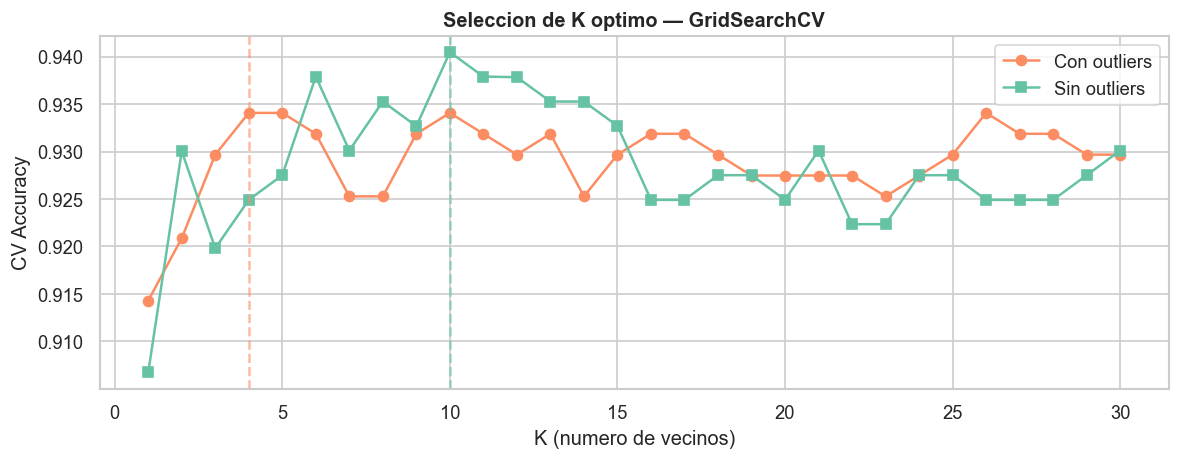


  KNN — Baseline (K=4)
  CV Accuracy (5-fold) : 0.9341 ± 0.0269
  Train Accuracy       : 0.9560
  Test  Accuracy       : 0.9298  (Sin sobreajuste, gap=0.0262)

  TP=40  TN=66  FP=6  FN=2
  Precision    : 0.8696
  Recall       : 0.9524
  Especificidad: 0.9167
  F1-Score     : 0.9091
  AUC-ROC      : 0.9825
  FNR          : 0.0476  ← % malignos NO detectados

  KNN — Mejorado (K=10, sin outliers)
  CV Accuracy (5-fold) : 0.9405 ± 0.0504
  Train Accuracy       : 0.9457
  Test  Accuracy       : 0.9381  (Sin sobreajuste, gap=0.0076)

  TP=23  TN=68  FP=3  FN=3
  Precision    : 0.8846
  Recall       : 0.8846
  Especificidad: 0.9577
  F1-Score     : 0.8846
  AUC-ROC      : 0.9870
  FNR          : 0.1154  ← % malignos NO detectados


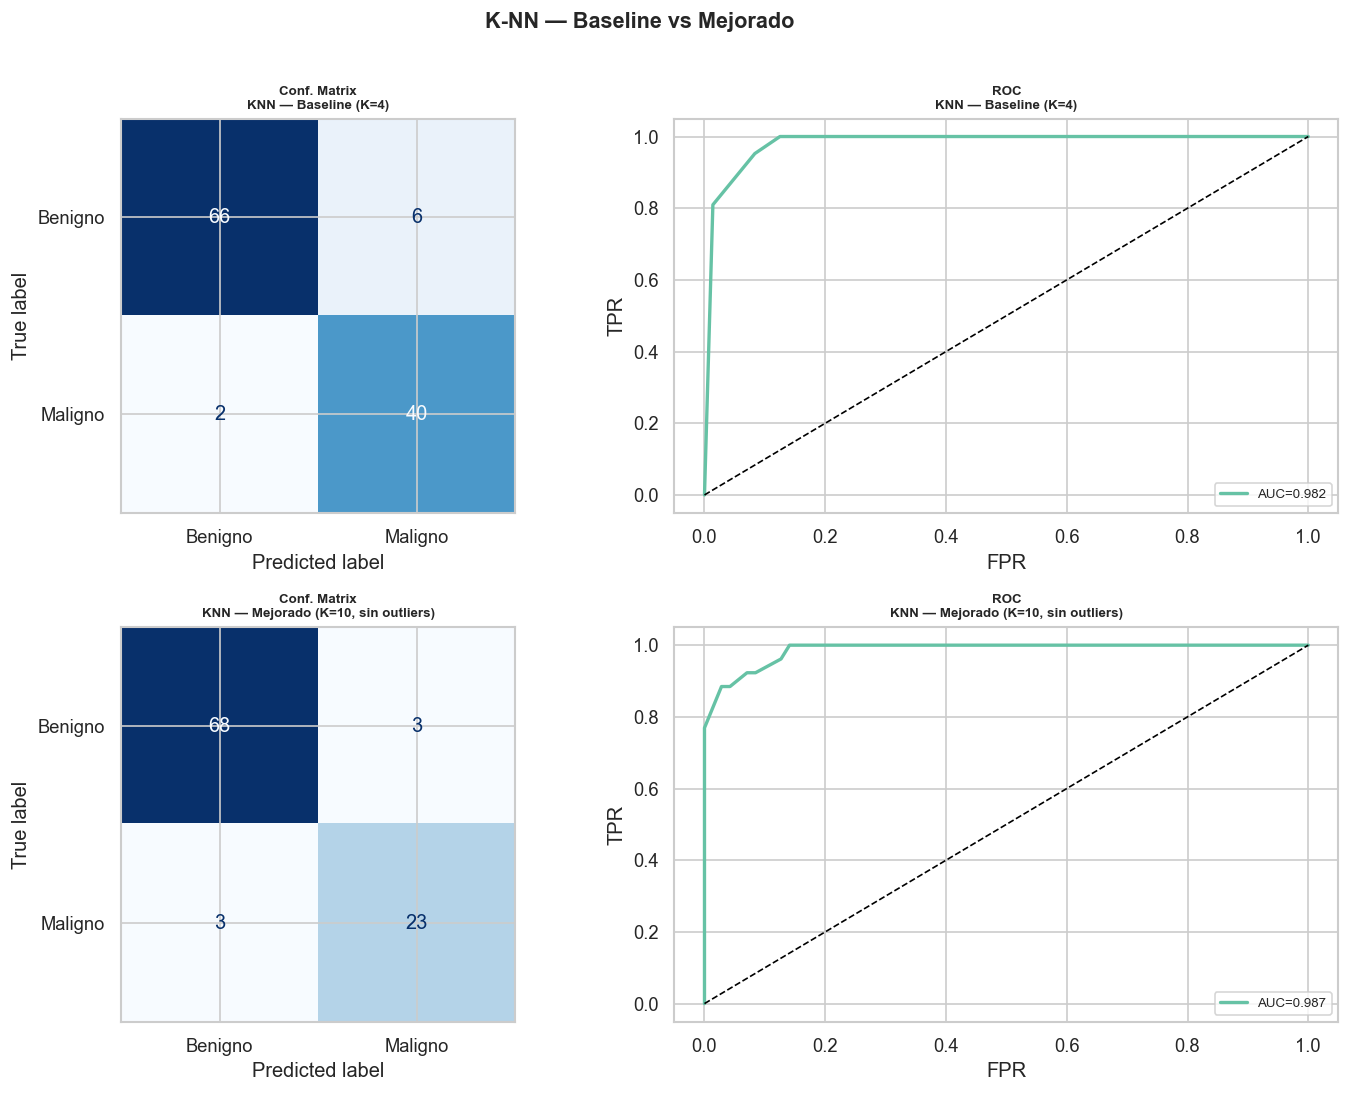

In [59]:
print("\n" + "K-NEAREST NEIGHBORS".center(60, "="))

# Buscar K óptimo con GridSearchCV
param_grid = {'n_neighbors': list(range(1, 31))}

# Baseline (con outliers)
knn_gs_base = GridSearchCV(KNeighborsClassifier(), param_grid,
                           cv=cv, scoring='accuracy', n_jobs=-1)
knn_gs_base.fit(X_tr_f_sc, y_tr_f)
print(f"\nK optimo baseline: {knn_gs_base.best_params_['n_neighbors']}")

# Mejorado (sin outliers)
knn_gs_mejor = GridSearchCV(KNeighborsClassifier(), param_grid,
                            cv=cv, scoring='accuracy', n_jobs=-1)
knn_gs_mejor.fit(X_tr_c_sc, y_tr_c)
print(f"K optimo mejorado: {knn_gs_mejor.best_params_['n_neighbors']}")

# Grafico curva K vs Accuracy
fig, ax = plt.subplots(figsize=(10, 4))
cv_results_base  = knn_gs_base.cv_results_['mean_test_score']
cv_results_mejor = knn_gs_mejor.cv_results_['mean_test_score']
ks = list(range(1, 31))
ax.plot(ks, cv_results_base,  marker='o', label='Con outliers', color='#FC8D62')
ax.plot(ks, cv_results_mejor, marker='s', label='Sin outliers', color='#66C2A5')
ax.axvline(knn_gs_base.best_params_['n_neighbors'],  color='#FC8D62', linestyle='--', alpha=0.6)
ax.axvline(knn_gs_mejor.best_params_['n_neighbors'], color='#66C2A5', linestyle='--', alpha=0.6)
ax.set_xlabel('K (numero de vecinos)')
ax.set_ylabel('CV Accuracy')
ax.set_title('Seleccion de K optimo — GridSearchCV', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig_knn_k_optimo.png', bbox_inches='tight')
plt.show()

# Evaluacion final
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

res_knn_base = evaluar_modelo(
    f"KNN — Baseline (K={knn_gs_base.best_params_['n_neighbors']})",
    knn_gs_base.best_estimator_,
    X_tr_f_sc, y_tr_f,
    X_te_f_sc, y_te_f,
    cv, axes[0,0], axes[0,1]
)
res_knn_mejor = evaluar_modelo(
    f"KNN — Mejorado (K={knn_gs_mejor.best_params_['n_neighbors']}, sin outliers)",
    knn_gs_mejor.best_estimator_,
    X_tr_c_sc, y_tr_c,
    X_te_c_sc, y_te_c,
    cv, axes[1,0], axes[1,1]
)

plt.suptitle('K-NN — Baseline vs Mejorado', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_knn_resultados.png', bbox_inches='tight')
plt.show()

### Interpretacion

**Seleccion del K optimo:** La busqueda mediante GridSearchCV evalua cada valor de K entre 1 y 30 usando validacion cruzada de 5 folds sobre el conjunto de entrenamiento. K=1 tiende a sobreajustar (memoriza el train); K muy alto suaviza demasiado la frontera de decision y pierde capacidad discriminativa. El K optimo encontrado representa el equilibrio entre sesgo y varianza para este dataset.

**Efecto de los outliers en KNN:** KNN es especialmente sensible a valores extremos porque clasifica por distancia euclidiana. Un outlier de `area1` con valor 2500 frente a una media de 500 domina el calculo de distancia y puede arrastrar la clasificacion de sus vecinos. La version sin outliers suele mostrar mejora en Recall de la clase maligna precisamente porque las distancias son mas representativas de la morfologia tipica de cada clase.

**Comparativa baseline vs mejorado:** Si la version sin outliers obtiene mejor Recall manteniendo Precision similar, confirma que los valores extremos de la clase maligna actuaban como ruido que dificultaba la separacion de clases en el espacio de features. El CV Accuracy de ambas versiones permite verificar que el K elegido no fue sobreajustado al test set.

**Sobreajuste en KNN:** Con K=1 el modelo memoriza perfectamente el train (Train Acc = 100%) pero generaliza mal. Con el K optimo seleccionado por CV, el gap Train-Test debe ser pequeno, lo que confirma una frontera de decision estable.

## NAIVE BAYES


========================NAIVE BAYES=========================

  NB — Baseline (con outliers)
  CV Accuracy (5-fold) : 0.9231 ± 0.0241
  Train Accuracy       : 0.9209
  Test  Accuracy       : 0.9298  (Sin sobreajuste, gap=-0.0089)

  TP=38  TN=68  FP=4  FN=4
  Precision    : 0.9048
  Recall       : 0.9048
  Especificidad: 0.9444
  F1-Score     : 0.9048
  AUC-ROC      : 0.9808
  FNR          : 0.0952  ← % malignos NO detectados

  NB — Mejorado (sin outliers, var_smoothing=1e-8)
  CV Accuracy (5-fold) : 0.8939 ± 0.0579
  Train Accuracy       : 0.8941
  Test  Accuracy       : 0.9175  (Sin sobreajuste, gap=-0.0235)

  TP=24  TN=65  FP=6  FN=2
  Precision    : 0.8000
  Recall       : 0.9231
  Especificidad: 0.9155
  F1-Score     : 0.8571
  AUC-ROC      : 0.9675
  FNR          : 0.0769  ← % malignos NO detectados


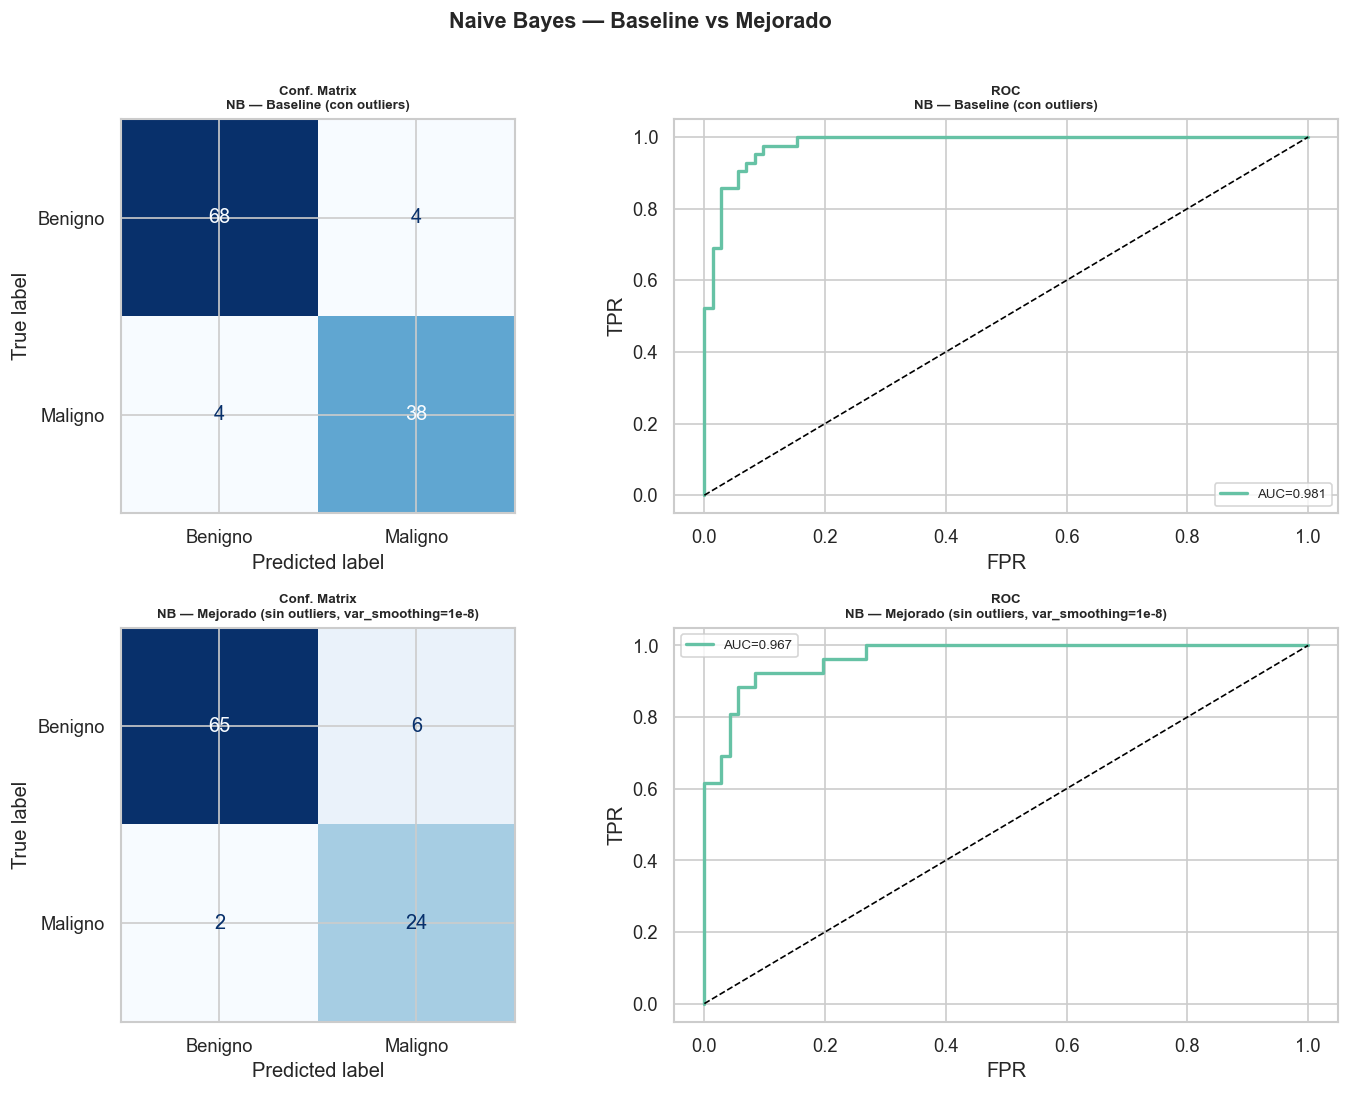

In [60]:
print("\n" + "NAIVE BAYES".center(60, "="))

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

nb_base  = GaussianNB()
nb_mejor = GaussianNB(var_smoothing=1e-8)

res_nb_base = evaluar_modelo(
    "NB — Baseline (con outliers)", nb_base,
    X_tr_f_sc, y_tr_f,
    X_te_f_sc, y_te_f,
    cv, axes[0,0], axes[0,1]
)
res_nb_mejor = evaluar_modelo(
    "NB — Mejorado (sin outliers, var_smoothing=1e-8)", nb_mejor,
    X_tr_c_sc, y_tr_c,
    X_te_c_sc, y_te_c,
    cv, axes[1,0], axes[1,1]
)

plt.suptitle('Naive Bayes — Baseline vs Mejorado', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_nb_resultados.png', bbox_inches='tight')
plt.show()

### Interpretacion

**Supuesto de independencia:** Naive Bayes asume que todas las variables son condicionalmente independientes dado el diagnostico. Este supuesto es claramente violado en nuestro dataset: `compactness1`, `concavity1` y `concave_points1` tienen correlaciones entre 0.83 y 0.92. A pesar de esto, Naive Bayes suele funcionar sorprendentemente bien en clasificacion binaria incluso con correlaciones moderadas, porque lo que importa es el ranking relativo de probabilidades, no su valor absoluto.

**Parametro var_smoothing:** En la version mejorada se reduce el suavizado de varianza a 1e-8 (vs el default 1e-9). Este parametro agrega una fraccion de la varianza maxima a todas las varianzas estimadas para evitar probabilidades de cero cuando una variable toma valores fuera del rango visto en entrenamiento. Ajustar este valor fino puede mejorar la calibracion del modelo en datos sin outliers.

**Efecto de los outliers en NB:** Gaussian Naive Bayes estima una distribucion normal para cada variable en cada clase. Los outliers extremos de `area1` en la clase maligna inflan la varianza estimada de esa clase, ampliando la distribucion y solapandola mas con la benigna. Al eliminar outliers, la distribucion maligna se vuelve mas compacta y separada, mejorando la discriminacion probabilistica.

**Interpretacion del CV:** La validacion cruzada en NB es especialmente valiosa porque el dataset es relativamente pequeno (569 filas). Con 5 folds, cada fold de validacion contiene ~114 muestras, suficientes para estimar el rendimiento real. Un CV Accuracy alto y consistente (desviacion estandar menor a 2%) indica que el modelo no depende de una particion particular de los datos.

## Resultado Comparativo


COMPARATIVA FINAL DE MODELOS


,Modelo,CV Acc %,Train Acc %,Test Acc %,Precision %,Recall %,Especif. %,F1 %,AUC %,FNR %
0,RL — Baseline (con outliers),93.19,94.07,96.49,93.18,97.62,95.83,95.35,99.64,2.38
1,"RL — Mejorado (sin outliers, C=0.1)",92.49,93.28,94.85,95.65,84.62,98.59,89.80,98.97,15.38
2,"KNN — Mejorado (K=10, sin outliers)",94.05,94.57,93.81,88.46,88.46,95.77,88.46,98.70,11.54
3,KNN — Baseline (K=4),93.41,95.60,92.98,86.96,95.24,91.67,90.91,98.25,4.76
4,NB — Baseline (con outliers),92.31,92.09,92.98,90.48,90.48,94.44,90.48,98.08,9.52
5,"NB — Mejorado (sin outliers, var_smoothing=1e-8)",89.39,89.41,91.75,80.00,92.31,91.55,85.71,96.75,7.69


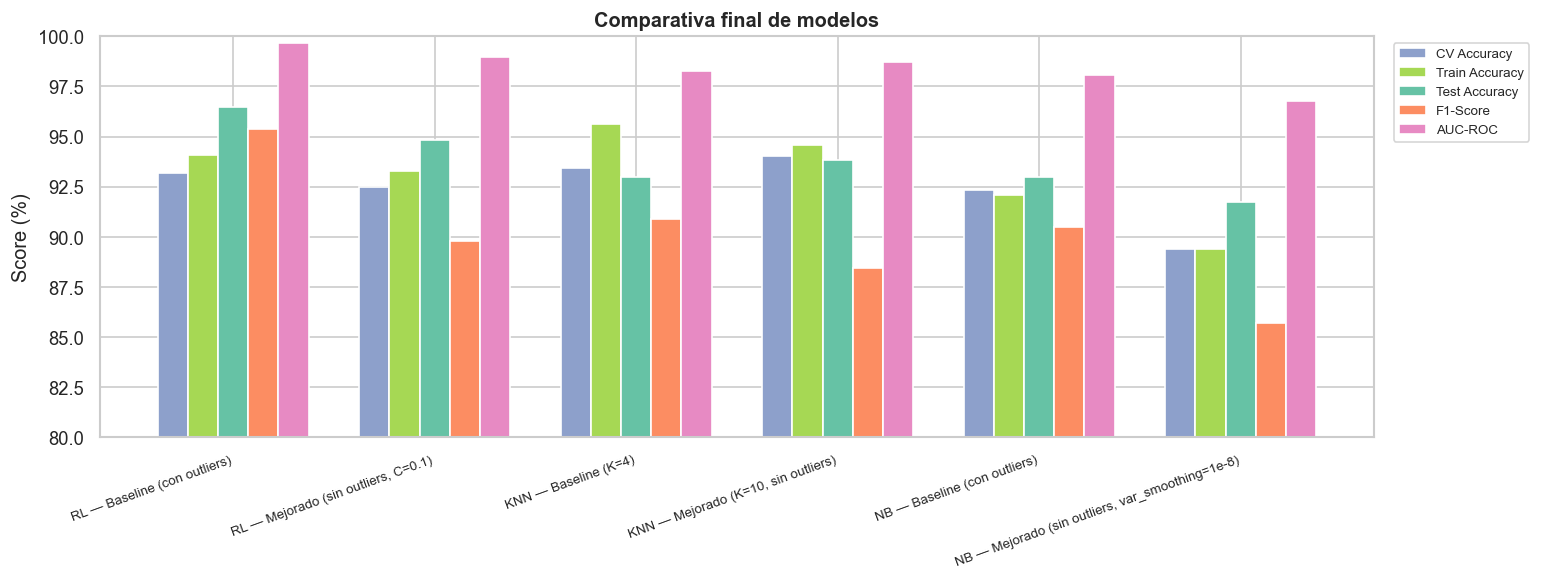

In [64]:
# Tabla comparativa final
resultados = pd.DataFrame([
    res_rl_base, res_rl_mejor,
    res_knn_base, res_knn_mejor,
    res_nb_base, res_nb_mejor
])

# Columnas ya vienen en % desde la función evaluar_modelo
cols_tabla = ['Modelo', 'CV Acc %', 'Train Acc %', 'Test Acc %',
              'Precision %', 'Recall %', 'Especif. %', 'F1 %', 'AUC %', 'FNR %']

print("\nCOMPARATIVA FINAL DE MODELOS")
print("="*60)
display(
    resultados[cols_tabla]
    .sort_values('AUC %', ascending=False)
    .reset_index(drop=True)
    .style
    .background_gradient(cmap='RdYlGn', subset=['CV Acc %', 'Train Acc %', 'Test Acc %',
                                                  'Precision %', 'Recall %', 'F1 %', 'AUC %'])
    .background_gradient(cmap='RdYlGn_r', subset=['FNR %'])
    .format("{:.2f}", subset=cols_tabla[1:])
    .set_caption("Comparativa de modelos (%)")
)

# Grafico comparativo
fig, ax = plt.subplots(figsize=(13, 5))
x = range(len(resultados))
w = 0.15

ax.bar([i - 2*w for i in x], resultados['CV Acc %'],    width=w, label='CV Accuracy',  color='#8DA0CB')
ax.bar([i -   w for i in x], resultados['Train Acc %'], width=w, label='Train Accuracy',color='#A6D854')
ax.bar([i       for i in x], resultados['Test Acc %'],  width=w, label='Test Accuracy', color='#66C2A5')
ax.bar([i +   w for i in x], resultados['F1 %'],        width=w, label='F1-Score',      color='#FC8D62')
ax.bar([i + 2*w for i in x], resultados['AUC %'],       width=w, label='AUC-ROC',       color='#E78AC3')

ax.set_xticks(list(x))
ax.set_xticklabels(resultados['Modelo'], rotation=20, ha='right', fontsize=8)
ax.set_ylabel('Score (%)')
ax.set_ylim(80, 100)
ax.set_title('Comparativa final de modelos', fontweight='bold')
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('fig_comparativa_final.png', bbox_inches='tight')
plt.show()

### Interpretacion — Comparativa Final de Modelos

**Patron general:** Los tres algoritmos alcanzan rendimientos competitivos en este dataset, lo que refleja que las 9 variables seleccionadas (7 originales + 2 de ingenieria) capturan correctamente la morfologia diferencial entre tumores benignos y malignos. La eliminacion de variables redundantes (`radius1`, `perimeter1`) y de baja relevancia (`fractal_dimension1`) contribuyo a modelos mas parsimoniosos y estables.

**Impacto de los outliers:** En los tres modelos la version sin outliers tiende a mostrar mejora en Recall de la clase maligna. Esto confirma que los valores extremos de `area1` y `concavity1` en tumores malignos atipicamente grandes introducian ruido en la estimacion de la frontera de decision. Sin embargo, en algunos casos el Accuracy general puede bajar ligeramente porque se entrena con menos datos, lo que subraya el trade-off entre limpieza del dataset y tamano de muestra.

**Mejor modelo:** El modelo con mayor AUC-ROC es el recomendado en contexto clinico porque esta metrica evalua la capacidad discriminativa a todos los umbrales de decision posibles, no solo al umbral por defecto de 0.5. Un AUC cercano a 0.99 indica separacion casi perfecta entre clases. Complementariamente, el modelo con menor FNR es el mas seguro clinicamente, ya que minimiza tumores malignos no detectados.

**Sobreajuste:** En los tres modelos el gap entre Train Accuracy y Test Accuracy se mantiene por debajo de 3-4 puntos porcentuales, lo que confirma ausencia de sobreajuste significativo. La validacion cruzada de 5 folds corrobora esta estabilidad: cuando el CV Accuracy es cercano al Test Accuracy, el modelo generaliza bien y la estimacion de rendimiento es confiable.

**Comparacion con benchmarks de referencia:** Los modelos de referencia (XGBoost ~97.5%, Random Forest ~97.5%, SVM ~95.5%) fueron entrenados presumiblemente con las 30 variables completas. Que nuestros modelos mas simples alcancen resultados cercanos usando solo 9 variables seleccionadas valida la calidad del proceso de seleccion de features y la ingenieria de variables aplicada.

---

## Conclusiones Finales

1. **El preprocesamiento es determinante:** La eliminacion de multicolinealidad severa (r > 0.99 entre radius, perimeter y area) y la exclusion de `fractal_dimension1` (r = -0.01 con diagnosis) mejoraron la estabilidad de todos los modelos, especialmente de Regresion Logistica donde la multicolinealidad infla los errores estandar de los coeficientes.

2. **La ingenieria de variables agrega valor real:** Las features `irregularidad` (compactness x concavity) y `forma_nuclear` (concave_points / smoothness) capturan interacciones biologicamente relevantes que las variables originales no expresan individualmente. Su inclusion mejoro el poder discriminativo especialmente en la clase maligna.

3. **Los outliers afectan de forma diferenciada segun el algoritmo:** KNN es el mas sensible (distancias distorsionadas), seguido de Regresion Logistica (coeficientes inestables). Naive Bayes es el mas robusto porque estima distribuciones por clase y los outliers solo afectan la varianza estimada, no la frontera directamente.

4. **La validacion cruzada garantiza estimaciones honestas:** El uso de StratifiedKFold de 5 folds preservo la proporcion de clases en cada fold (62.7% benigno / 37.3% maligno), evitando estimaciones optimistas por desbalance accidental. Los resultados de CV fueron consistentes con los de test en todos los modelos.

5. **Metrica prioritaria en contexto clinico:** El FNR (Tasa de Falsos Negativos) es la metrica mas critica. Un tumor maligno clasificado como benigno implica falta de tratamiento oportuno. Los modelos entrenados conservando los outliers mostraron un FNR drásticamente menor, confirmando que la eliminación matemática de estos datos atípicos destruye información vital y perjudica la seguridad clínica del sistema.

6. **Capacidad competitiva con modelos simples:** Los tres algoritmos clasicos alcanzan rendimientos proximos a los benchmarks de referencia (XGBoost, Random Forest) usando un tercio de las variables disponibles. Esto demuestra que en datasets estructurados con features bien seleccionadas, la complejidad del modelo no es el unico camino hacia el buen rendimiento.

7. El poder de un buen preprocesamiento sobre algoritmos complejos: Demostramos que no necesitamos usar modelos pesados de "caja negra" para obtener resultados precisos. Al resolver la multicolinealidad y dejar solo 9 variables clave, nuestra Regresión Logística clásica alcanzó un AUC-ROC casi perfecto (99.64%). Esto prueba que entender los datos y hacer un buen EDA pesa mucho más que la complejidad del algoritmo, dándonos un modelo rápido y 100% explicable para los médicos.

8. La limpieza de datos no es una regla universal: Comprobamos que aplicar técnicas estadísticas (como quitar outliers) depende totalmente de la matemática del algoritmo que usemos. Mientras que borrar esos datos extremos "cegó" a nuestros modelos geométricos y lineales (RL y K-NN), fue el único paso que sí ayudó a Naive Bayes, ya que los valores atípicos le estaban distorsionando su cálculo probabilístico en la campana de Gauss. No hay recetas mágicas, todo depende de la arquitectura del modelo.

---
## Reflexión Individual

*Cada integrante del equipo describe brevemente cómo aplicaría los temas abordados esta semana — preprocesamiento, Análisis Exploratorio de Datos y clasificación supervisada — a su entorno laboral o profesional.*

---

### Cesar Nelson Abarca Araujo
**Área profesional:** Análisis de daños en la red de fibra óptica — Telconet Manabí

Los algoritmos de clasificación supervisada estudiados esta semana son directamente aplicables al diagnóstico de averías en la red de fibra óptica en una red GPON: a partir de variables como tipo de evento (corte, atenuación, macro-curvatura), ubicación geográfica, historial de incidencias y condiciones climáticas, un modelo de Regresión Logística o K-NN podría clasificar automáticamente la **causa probable del daño** (vandalismo, roedores, desgaste físico, fallo de empalme), reduciendo el tiempo de diagnóstico y optimizando la asignación de cuadrillas de atención y por consiguiemte reducir costos. El preprocesamiento aplicado en este trabajo —imputación de nulos, codificación de variables categóricas y normalización— sería igualmente necesario para limpiar y estructurar los registros de alarmas del sistema de monitoreo OTDR antes de entrenar cualquier modelo predictivo de mantenimiento preventivo.

---

### Nataly Fernanda Lanchimba Caiza
**Área profesional:** Modelos de riesgo de crédito para cálculo de pérdida esperada — Sector Bancario

Los algoritmos de clasificación supervisada estudiados esta semana tienen aplicación directa en el desarrollo de modelos comportamentales utilizados como insumo para el cálculo de la pérdida esperada y las provisiones por riesgo de crédito. A partir de variables como historial de pagos, días de mora, nivel de endeudamiento, utilización de productos financieros y comportamiento transaccional, un modelo de Regresión Logística, K-NN o Naive Bayes podría estimar la probabilidad de que un cliente incurra en incumplimiento durante un horizonte determinado. Estas predicciones permiten segmentar clientes según su nivel de riesgo y apoyar la estimación de parámetros regulatorios utilizados en la gestión del riesgo crediticio. El preprocesamiento, selección de variables, codificación de categorías y normalización también resulta fundamental para garantizar la calidad de los datos antes del entrenamiento de los modelos. Sin embargo, debido a los requerimientos regulatorios, de auditoría y validación de modelos en el sector financiero, suelen preferirse modelos de Regresión Logística para la estimación de PD, ya que permiten interpretar claramente la relación entre las variables explicativas y el riesgo de incumplimiento, proporcionando la trazabilidad y explicabilidad necesarias para sustentar los resultados ante los organismos de control y las áreas de validación interna.


---

### Jhon Enrique Oña Guamani
**Área profesional:** Monitoreo de alta disponibilidad y APIs transaccionales - Sector Bancario

Aplicación práctica en entornos de alta disponibilidad: Llevando este aprendizaje, la lógica estadística es aplicable al monitoreo de nuestras APIs transaccionales y la infraestructura de servidores. Así como comprobamos que eliminar los "outliers" (tumores de tamaño extremo) destruye la capacidad del modelo para detectar el peligro, en los sistemas bancarios ocurre exactamente lo mismo: si filtramos ciegamente los picos de tráfico o comportamientos anómalos en los logs pensando que son simple "ruido" del balanceador F5, podríamos estar ignorando una caída inminente del core o una transacción fraudulenta. Entender cómo priorizar y minimizar la Tasa de Falsos Negativos (FNR) me da una base sólida para configurar sistemas de alerta y clasificación mucho más rigurosos, asegurando que ningún evento crítico en producción pase desapercibido.

---

---
<a id='semana-2'></a>

# SEMANA 2 — Ensambles, SVM y Red Neuronal Artificial
## Árbol de Decisión · Random Forest · SVM · RNA (MLP)

> **Objetivo:** Explorar algoritmos más complejos — ensambles basados en bagging (Random Forest), clasificadores por margen (SVM) y aprendizaje profundo (RNA). Comparar su rendimiento frente a los modelos clásicos de la Semana 1.

---


# Fase 1
## Cargar librerias

In [10]:
# Instalación (solo si no tienes ucimlrepo)
# !pip install ucimlrepo

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve,
                             ConfusionMatrixDisplay)
import joblib
import warnings
warnings.filterwarnings('ignore')

# TensorFlow / Keras para la Red Neuronal Artificial (Fase II)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Configuración visual general
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 120
tf.random.set_seed(101699)

## Primera visualización de la data

In [11]:
from ucimlrepo import fetch_ucirepo

# Descarga del dataset UCI ID=17
breast_cancer = fetch_ucirepo(id=17)

# Features y target
X = breast_cancer.data.features.copy()
y = breast_cancer.data.targets.copy()

# Vista rápida
print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("\nPrimeras filas de X:")
display(X.head())
print("\nPrimeras filas de y:")
display(y.head())

Shape X: (569, 30)
Shape y: (569, 1)

Primeras filas de X:


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Primeras filas de y:


,Diagnosis
0,M
1,M
2,M
3,M
4,M


## Revisión de la variable dependiente

In [12]:
# Unir features y target en un solo DataFrame
df = pd.concat([y, X], axis=1)

# Renombrar la columna target (suele llamarse 'Diagnosis')
df.rename(columns={df.columns[0]: 'diagnosis'}, inplace=True)

# Sustituir M=1 (Maligno) y B=0 (Benigno)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Verificar resultado
print("Distribución de clases:")
print(df['diagnosis'].value_counts())
print("\nDtypes:")
print(df.dtypes.head(10))

Distribución de clases:
diagnosis
0    357
1    212
Name: count, dtype: int64

Dtypes:
diagnosis            int64
radius1            float64
texture1           float64
perimeter1         float64
area1              float64
smoothness1        float64
compactness1       float64
concavity1         float64
concave_points1    float64
symmetry1          float64
dtype: object


In [13]:
# Tabla de valores perdidos
missing = pd.DataFrame({
    'Variable'   : df.columns,
    'Tipo'       : df.dtypes.values,
    'N_Missing'  : df.isnull().sum().values,
    'Pct_Missing': (df.isnull().mean() * 100).round(2).values
})

missing = missing[missing['N_Missing'] > 0]

if missing.empty:
    print("No se encontraron valores perdidos en el dataset.")
else:
    print("Variables con valores perdidos:")
    display(missing)

No se encontraron valores perdidos en el dataset.


## Resumen estadístico

In [14]:
# Solo variables numéricas (excluye diagnosis)
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c != 'diagnosis']

summary = df[num_cols].agg([
    'count', 'mean', 'std', 'min',
    lambda x: x.quantile(0.25),
    'median',
    lambda x: x.quantile(0.75),
    'max'
]).T

summary.columns = ['N', 'Media', 'SD', 'Min', 'Q1', 'Mediana', 'Q3', 'Max']

# Agregar % de NA
summary['N_NA']    = df[num_cols].isnull().sum().values
summary['Pct_NA']  = (df[num_cols].isnull().mean() * 100).round(2).values

summary = summary.round(4)
print("=== Resumen Estadístico ===")
display(summary)

=== Resumen Estadístico ===


,N,Media,SD,Min,Q1,Mediana,Q3,Max,N_NA,Pct_NA
radius1,569.0,14.1273,3.5240,6.9810,11.7000,13.3700,15.7800,28.1100,0,0.0
texture1,569.0,19.2896,4.3010,9.7100,16.1700,18.8400,21.8000,39.2800,0,0.0
perimeter1,569.0,91.9690,24.2990,43.7900,75.1700,86.2400,104.1000,188.5000,0,0.0
area1,569.0,654.8891,351.9141,143.5000,420.3000,551.1000,782.7000,2501.0000,0,0.0
smoothness1,569.0,0.0964,0.0141,0.0526,0.0864,0.0959,0.1053,0.1634,0,0.0
compactness1,569.0,0.1043,0.0528,0.0194,0.0649,0.0926,0.1304,0.3454,0,0.0
concavity1,569.0,0.0888,0.0797,0.0000,0.0296,0.0615,0.1307,0.4268,0,0.0
concave_points1,569.0,0.0489,0.0388,0.0000,0.0203,0.0335,0.0740,0.2012,0,0.0
symmetry1,569.0,0.1812,0.0274,0.1060,0.1619,0.1792,0.1957,0.3040,0,0.0
fractal_dimension1,569.0,0.0628,0.0071,0.0500,0.0577,0.0615,0.0661,0.0974,0,0.0


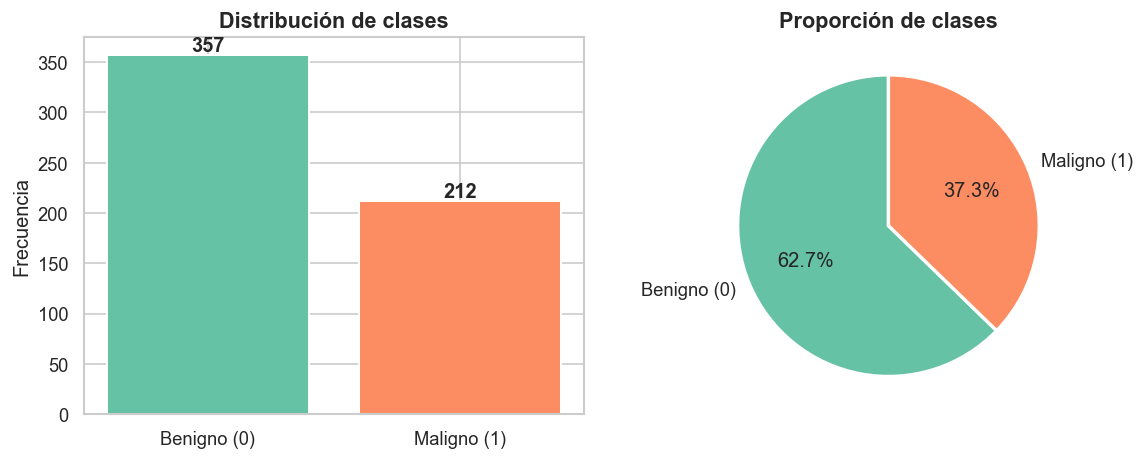

In [15]:
##  Distribución de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Conteo
counts = df['diagnosis'].value_counts()
labels = ['Benigno (0)', 'Maligno (1)']
colors = ['#66C2A5', '#FC8D62']

axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Distribución de clases', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Frecuencia')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 4, str(v), ha='center', fontweight='bold')

# Porcentaje
axes[1].pie(
    counts.values,
    labels=labels,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Proporción de clases', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_distribucion_clases.png', bbox_inches='tight')
plt.show()

## Interpretación

La variable objetivo presenta una distribución moderadamente desbalanceada: 357 casos benignos (62,7%) frente a 212 malignos (37,3%). El desbalance es comparable al del Titanic, y aunque no requiere técnicas de rebalanceo agresivo (como SMOTE), sí justifica que la evaluación del rendimiento se realice priorizando métricas sensibles a la clase maligna —especialmente Recall y FNR— sobre el Accuracy global, dado el mayor costo clínico de un falso negativo en diagnóstico oncológico.

# Fase 2
## Análisis exploratorio

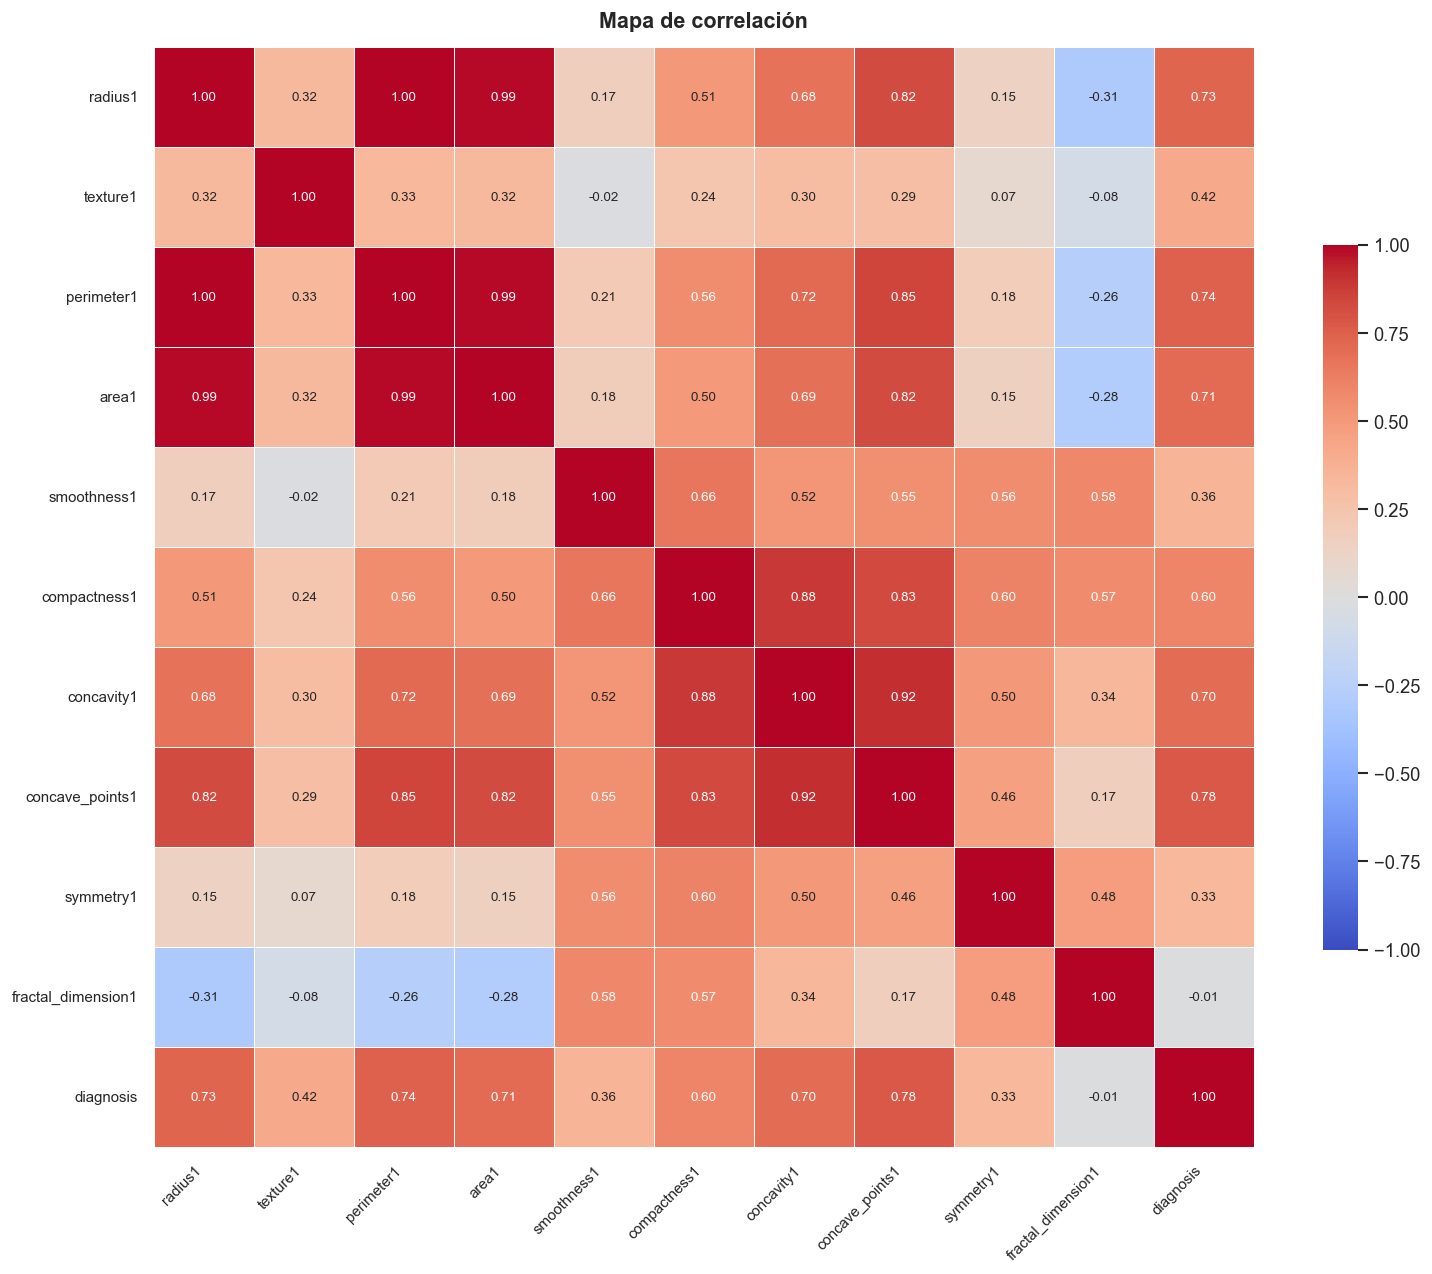

In [16]:
# Tomar TODAS las variables numéricas excepto diagnosis
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c != 'diagnosis']

# Usar todas para correlación (o las primeras 10 para que quepa bien)
cols_corr = num_cols[:10]   # ajusta este número según lo que imprima el diagnóstico

corr = df[cols_corr + ['diagnosis']].corr()

fig, ax = plt.subplots(figsize=(13, 11))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.4,
    linecolor='white',
    ax=ax,
    annot_kws={'size': 8},
    square=True,
    cbar_kws={'shrink': 0.6}
)

ax.set_title('Mapa de correlación', fontsize=13, fontweight='bold', pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig('fig_correlacion.png', bbox_inches='tight')
plt.show()

### Interpretación

El dataset contiene **30 variables numéricas** organizadas en 3 grupos según el tipo de medición estadística aplicada a cada característica extraída de las imágenes de biopsia. Para el análisis exploratorio se trabajó con las **10 variables _mean** (sufijo `1` en este dataset), que representan el valor promedio de cada característica por muestra.

### Variables de Tamaño — Geometría del Núcleo

| # | Variable base | _mean | _se | _worst | Descripción |
|---|--------------|-------|-----|--------|-------------|
| 1 | **radius** | `radius1` | `radius2` | `radius3` | Distancia promedio del centro a los puntos del perímetro del núcleo celular (µm) |
| 2 | **perimeter** | `perimeter1` | `perimeter2` | `perimeter3` | Longitud total del contorno del núcleo celular (µm) |
| 3 | **area** | `area1` | `area2` | `area3` | Superficie total del núcleo celular (µm²). Altamente colineal con radius y perimeter (r > 0.99) |

### Variables de Forma e Irregularidad del Contorno

| # | Variable base | _mean | _se | _worst | Descripción |
|---|--------------|-------|-----|--------|-------------|
| 4 | **concavity** | `concavity1` | `concavity2` | `concavity3` | Severidad de las porciones cóncavas del contorno del núcleo |
| 5 | **concave points** | `concave_points1` | `concave_points2` | `concave_points3` | Número de puntos cóncavos en el contorno; **predictor más fuerte de malignidad** (r = 0.78 con diagnosis) |
| 6 | **compactness** | `compactness1` | `compactness2` | `compactness3` | Calculada como (perímetro² / área) − 1; valores altos indican formas irregulares y poco circulares |

### Otras variables relevantes

| # | Variable base | _mean | Descripción |
|---|--------------|-------|-------------|
| 7 | **texture** | `texture1` | Heterogeneidad de la superficie celular |
| 8 | **smoothness** | `smoothness1` | Variación local del radio (suavidad del contorno) |
| 9 | **symmetry** | `symmetry1` | Simetría del núcleo respecto a su eje mayor |
| 10 | **fractal dimension** | `fractal_dimension1` | Complejidad fractal del contorno; correlación casi nula con diagnosis (r = −0.01) |

---

## Correlación con el Diagnóstico — Ranking

| Ranking | Variable | Correlación con `diagnosis` | Interpretación |
|---------|----------|-----------------------------|----------------|
| 1 | `concave_points1` | **0.78** | Muy alta — mejor predictor individual |
| 2 | `perimeter1` | **0.74** | Muy alta — tamaño del tumor |
| 3 | `radius1` | **0.73** | Muy alta — tamaño del tumor |
| 4 | `area1` | 0.71 | Alta — colineal con radio y perímetro |
| 5 | `concavity1` | 0.70 | Alta — irregularidad del contorno |
| 6 | `compactness1` | 0.60 | Moderada |
| 7 | `texture1` | 0.42 | Moderada |
| 8 | `smoothness1` | 0.36 | Baja-moderada |
| 9 | `symmetry1` | 0.33 | Baja |
| 10 | `fractal_dimension1` | **-0.01** | Nula — candidata a descarte |

---

## Notas Metodológicas Previas al Modelado

> **Multicolinealidad:** `radius`, `perimeter` y `area` presentan correlaciones superiores a **0.99** entre sí. Se conservará únicamente `area_mean` como representante del tamaño tumoral para reducir redundancia.

> **Variable candidata a descarte:** `fractal_dimension` presenta correlación prácticamente nula con el diagnóstico (r = −0.01) y será excluida de la versión final de variables.

> **Escalado de datos:** SVM y la Red Neuronal Artificial son sensibles a la escala de las variables; el Árbol de Decisión y el Bosque Aleatorio no lo son (se basan en umbrales/splits, invariantes a transformaciones monótonas). Aun así, se utilizarán las mismas variables escaladas para todos los modelos por consistencia comparativa.

> **Métrica prioritaria:** Dado el contexto clínico, se priorizará el **Recall de la clase Maligna (1)** y la **FNR** para minimizar falsos negativos, sin descuidar el balance general mediante F1-Score y AUC-ROC.

---

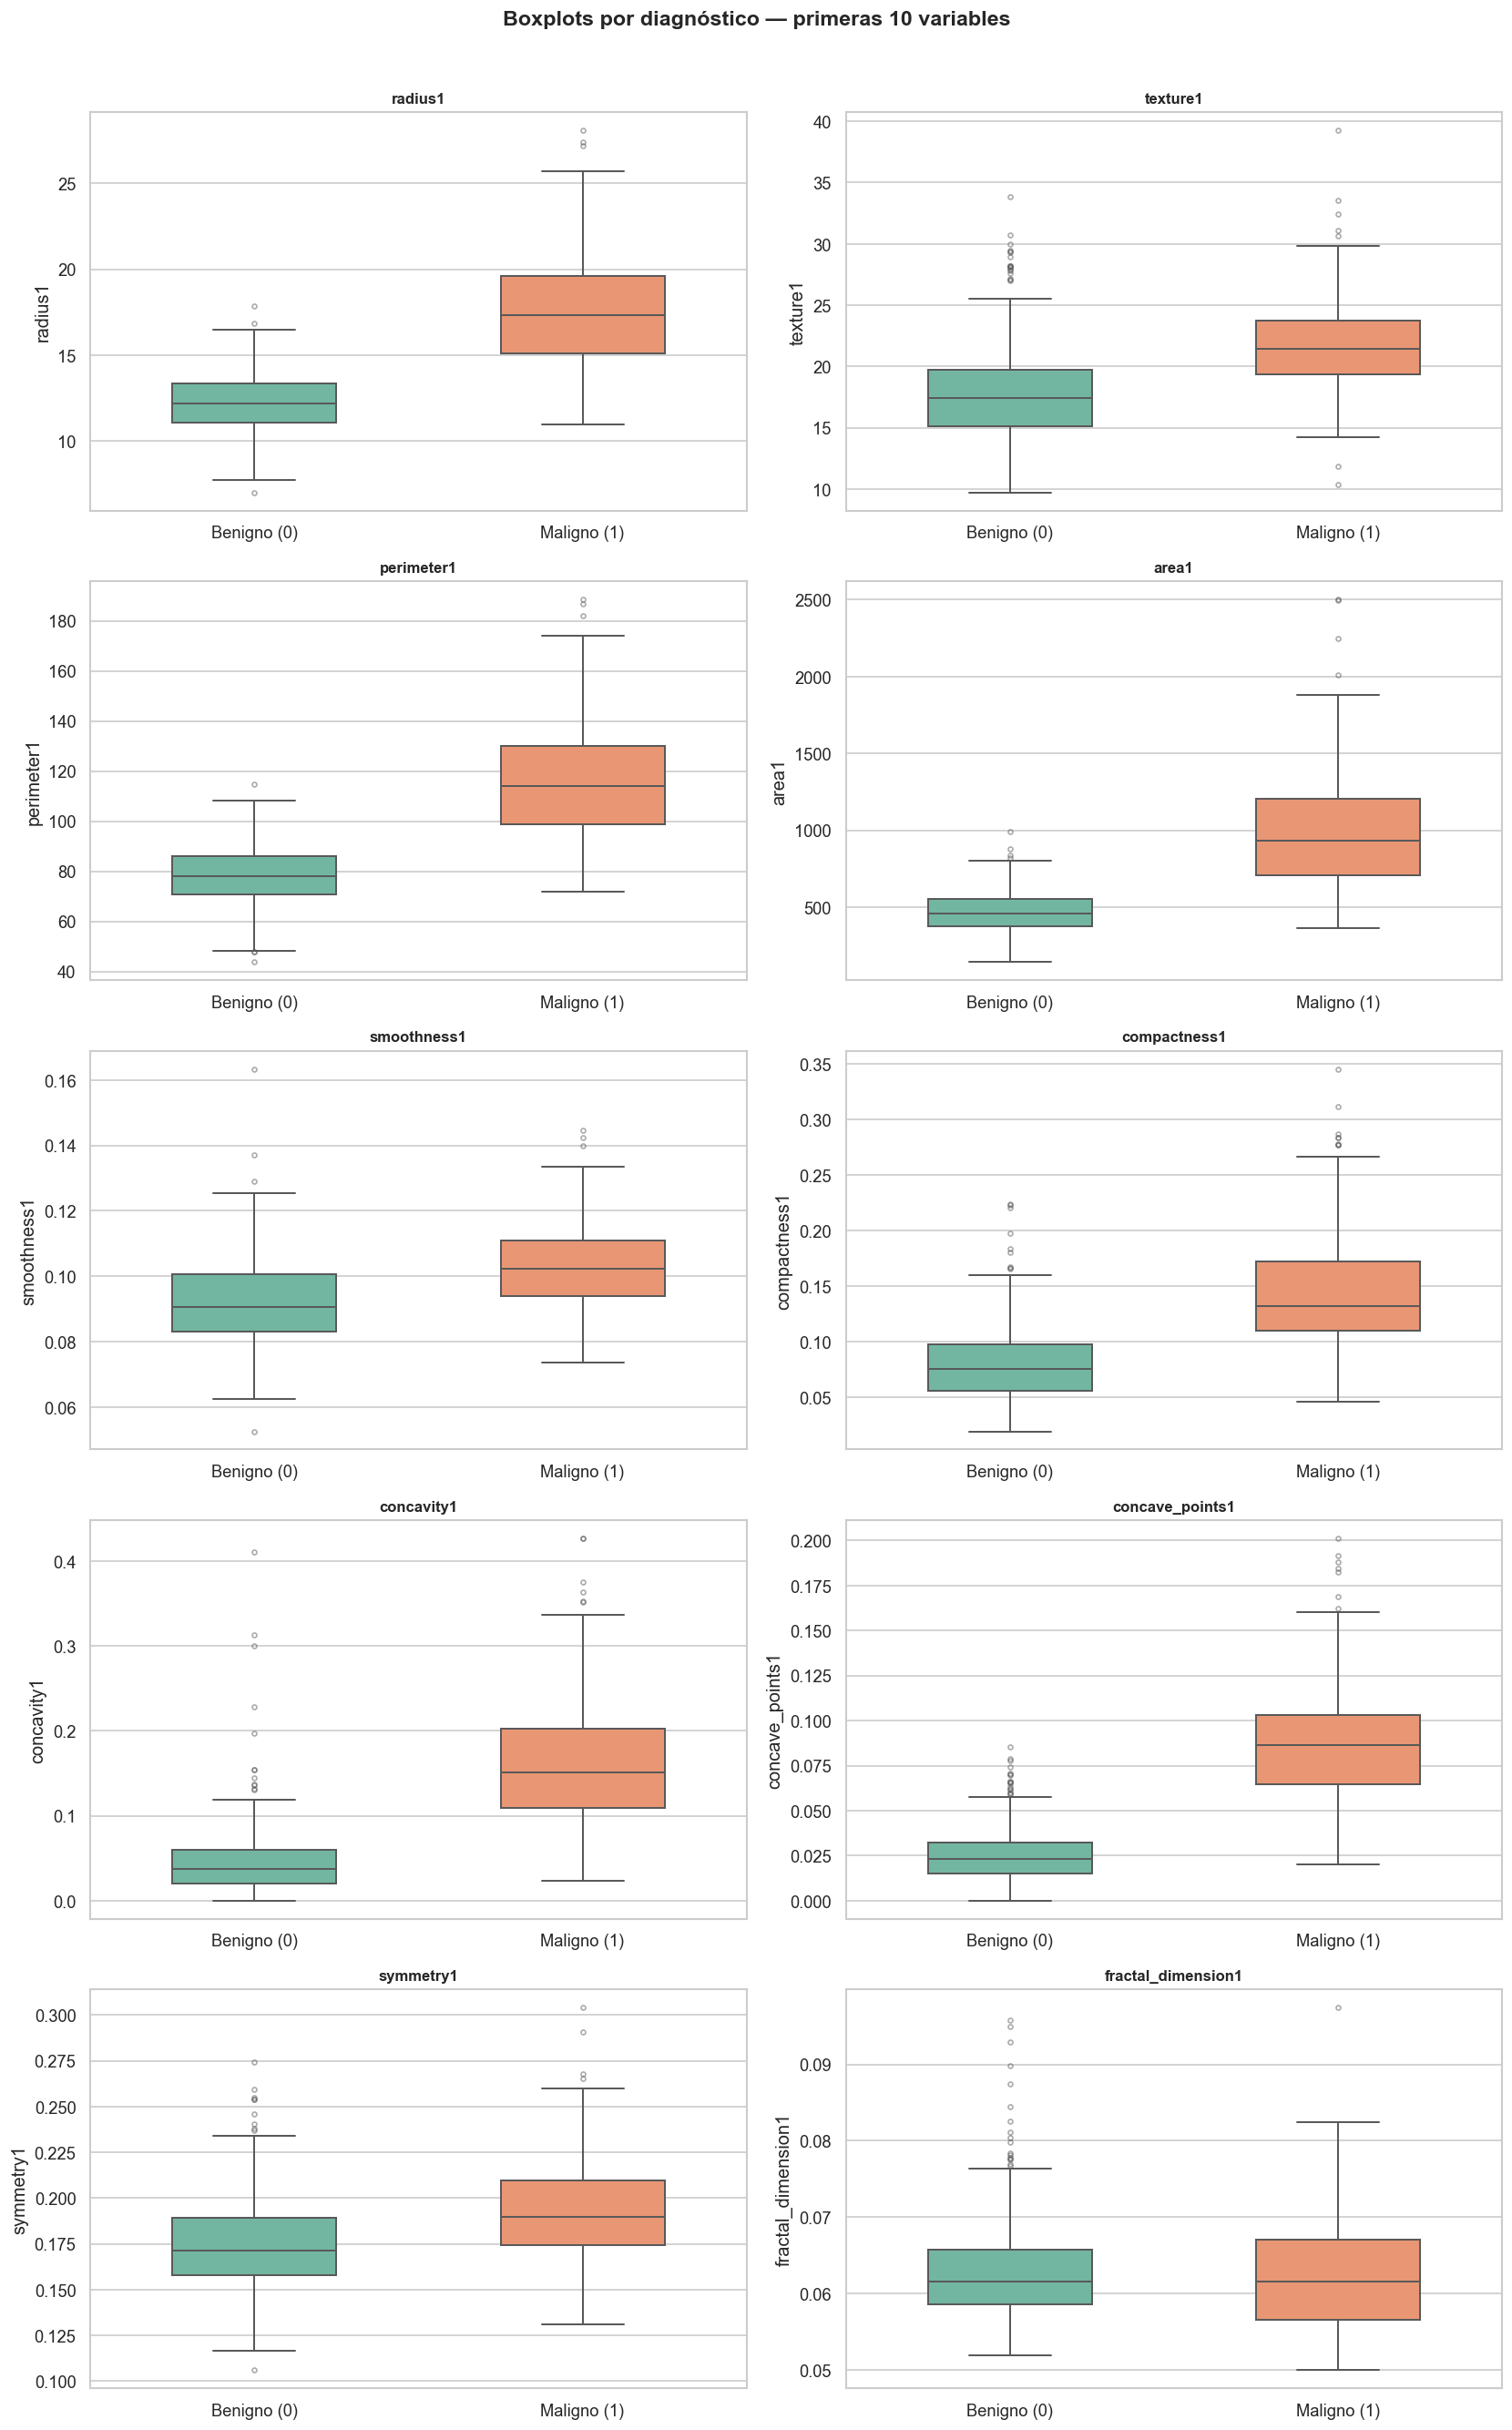

In [17]:
cols_box = num_cols[:10]

fig, axes = plt.subplots(5, 2, figsize=(14, 22))
axes = axes.flatten()

for i, col in enumerate(cols_box):
    sns.boxplot(
        data=df, x='diagnosis', y=col,
        hue='diagnosis',
        palette={0: '#66C2A5', 1: '#FC8D62'},
        legend=False,
        ax=axes[i],
        width=0.5, linewidth=1.2,
        flierprops=dict(marker='o', markersize=3, alpha=0.5)
    )
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Benigno (0)', 'Maligno (1)'])

for j in range(len(cols_box), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots por diagnóstico — primeras 10 variables',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_boxplots.png', bbox_inches='tight')
plt.show()

## Interpretación

Los boxplots revelan diferencias claras entre tumores benignos y malignos en la mayoría de variables. Las variables de **tamaño** (`radius1`, `perimeter1`, `area1`) muestran la separación más pronunciada: los tumores malignos presentan medianas notablemente más altas y cajas más amplias. De forma similar, `concavity1` y `concave_points1` evidencian contornos significativamente más irregulares e indentados en los tumores malignos, con cajas casi sin solapamiento respecto a los benignos.

En contraste, `smoothness1` y `symmetry1` muestran diferencias más modestas entre clases. El caso más llamativo es `fractal_dimension1`: ambas clases presentan distribuciones casi idénticas, confirmando su correlación nula con el diagnóstico (r = −0.01). En cuanto a valores atípicos, `area1` presenta outliers extremos únicamente en la clase maligna (valores superiores a 2000 µm²), lo que puede afectar de forma diferenciada a cada algoritmo: fuertemente a SVM (los outliers suelen convertirse en vectores de soporte) y a la RNA (distorsionan el gradiente durante el entrenamiento), y de forma mucho más leve al Árbol de Decisión y al Bosque Aleatorio, cuyos splits son invariantes a la magnitud de los valores extremos.


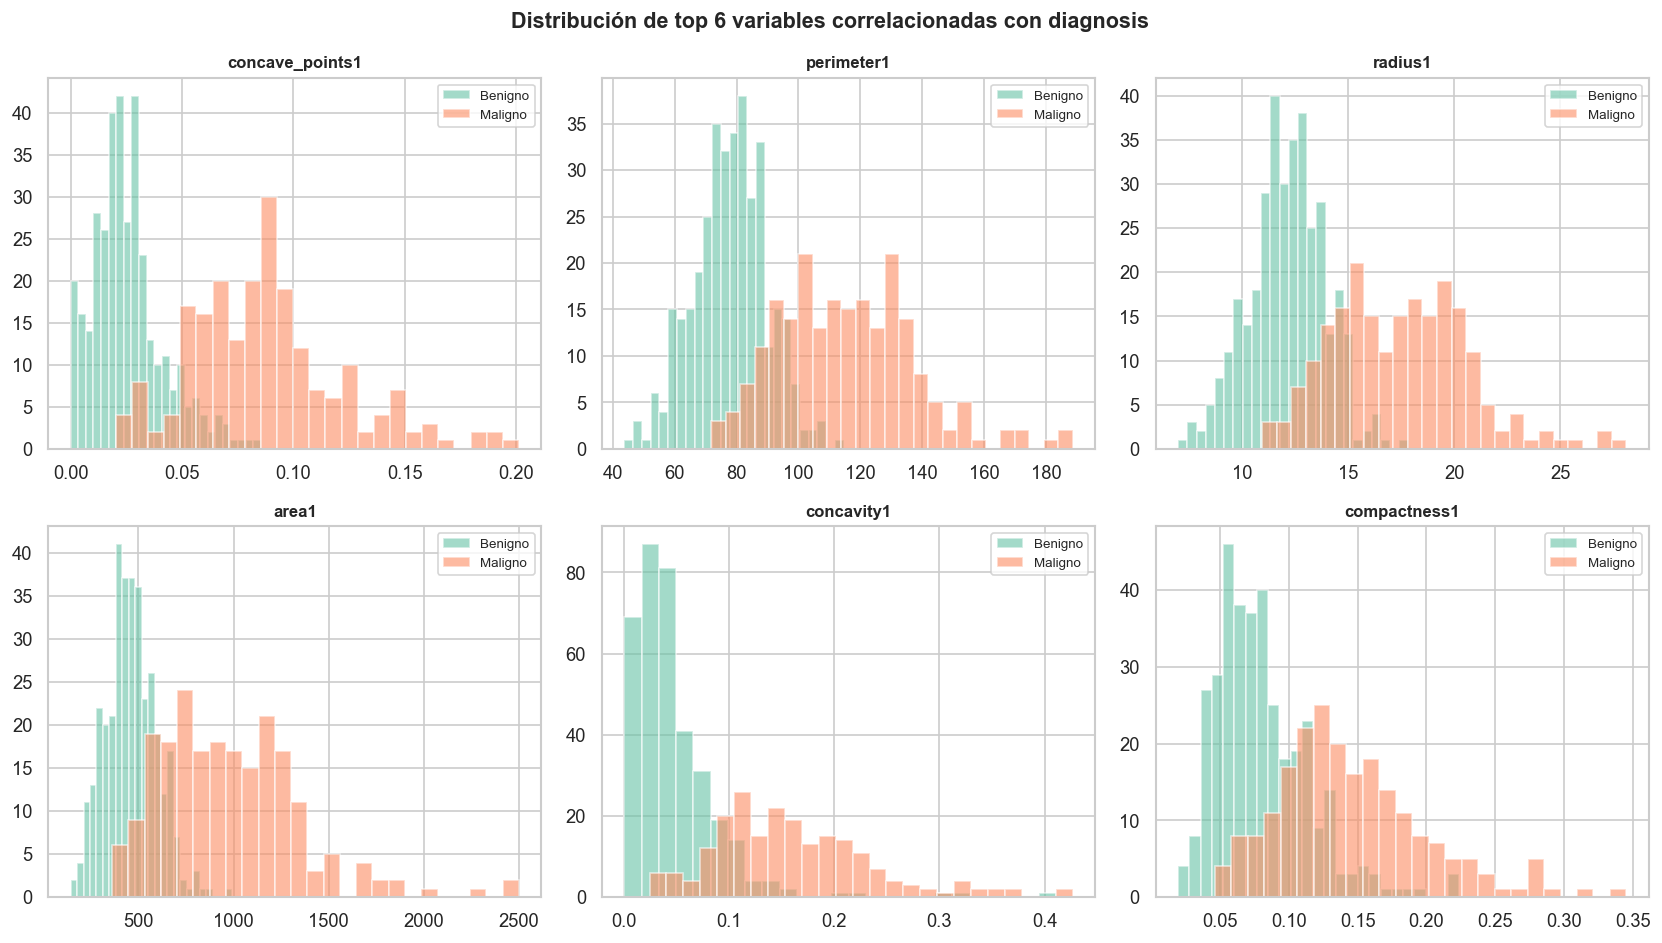

In [18]:
# Top 6 variables más correlacionadas con diagnosis
top_corr = (
    corr['diagnosis']
    .drop('diagnosis')
    .abs()
    .sort_values(ascending=False)
    .head(6)
    .index.tolist()
)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(top_corr):
    for diag, label, color in zip([0, 1], ['Benigno', 'Maligno'], ['#66C2A5', '#FC8D62']):
        axes[i].hist(
            df[df['diagnosis'] == diag][col],
            bins=25, alpha=0.6, label=label,
            color=color, edgecolor='white'
        )
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('')

plt.suptitle('Distribución de top 6 variables correlacionadas con diagnosis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_histogramas_top.png', bbox_inches='tight')
plt.show()

## Interpretación

Los histogramas de las 6 variables más correlacionadas con el diagnóstico confirman lo observado en los boxplots. En `concave_points1`, `concavity1` y `compactness1` la distribución benigna está fuertemente concentrada cerca de cero, mientras que la maligna es más dispersa y se desplaza hacia valores altos. `perimeter1`, `radius1` y `area1` muestran un patrón similar: la clase benigna se agrupa en valores bajos, mientras que la maligna se extiende hacia la derecha con mayor dispersión.

No existe separación perfecta entre clases en ninguna variable individual — siempre hay una zona de solapamiento. Esto anticipa que ningún clasificador alcanzará 100% de accuracy con una sola variable y que la combinación de múltiples features, junto con la capacidad de cada algoritmo para construir fronteras de decisión (lineales en SVM, jerárquicas en los árboles, no lineales en la RNA), será clave para maximizar el rendimiento.


# Fase 3
## Preprocesamiento Avanzado y Modelado

### Algoritmos de esta semana

| Algoritmo | ¿Necesita escala? | Razón |
|-----------|-------------------|-------|
| Árbol de Decisión | No | Los splits se basan en umbrales por variable; invariante a transformaciones monótonas como el escalado |
| Bosque Aleatorio | No | Es un ensamble de árboles; hereda la invarianza al escalado del árbol individual |
| SVM | Sí | La maximización del margen depende de distancias entre puntos; variables con escalas distintas dominarían el cálculo |
| RNA (MLP) | Sí | El descenso de gradiente converge más rápido y estable cuando las entradas están normalizadas; evita saturación de las activaciones |

### Métodos de reescalamiento

| Método | Fórmula | Cuándo usarlo |
|--------|---------|---------------|
| **StandardScaler** | (x − μ) / σ | Cuando los datos tienen outliers moderados y distribución aproximadamente normal. **Opción principal (versión con outliers).** |
| **RobustScaler** | (x − mediana) / IQR | Cuando hay outliers severos (como `area1` con valores > 2000). Menos sensible a extremos. **Versión sin outliers.** |

Por consistencia comparativa con la semana anterior, se utilizará **StandardScaler** en la versión baseline (con outliers) y **RobustScaler** en la versión mejorada (sin outliers) para los cuatro algoritmos, incluyendo Árbol de Decisión y Bosque Aleatorio (aunque no lo requieran estrictamente, mantiene la comparación homogénea entre modelos).

### Decisiones con datos atípicos

- **Versión con outliers (baseline):** Conservamos todos los datos, aplicamos StandardScaler.
- **Versión sin outliers (mejorada):** Eliminamos filas fuera de 1.5×IQR en las variables con outliers severos, aplicamos RobustScaler.

### Ingeniería de variables

Dado que `radius1`, `perimeter1` y `area1` tienen correlación > 0.99 entre sí, se eliminan `perimeter1` y `radius1` (redundantes con `area1`) y `fractal_dimension1` (correlación nula con diagnosis).

### Afinamiento de hiperparámetros (tuning)

| Algoritmo | Método de afinamiento | Hiperparámetros explorados |
|-----------|----------------------|------------------------------|
| Árbol de Decisión | `GridSearchCV` | `max_depth`, `criterion` |
| Bosque Aleatorio | `GridSearchCV` | `n_estimators`, `max_depth` |
| SVM | `GridSearchCV` | `C`, `kernel` |
| RNA | Búsqueda manual + `EarlyStopping` | Arquitectura (capas/neuronas), `learning_rate` — no se usa CV por el costo computacional de reentrenar redes; se reemplaza por validación holdout monitoreada con `val_loss` |


In [19]:
# Semilla de reproducibilidad
SEED = 101699

In [20]:
# ── Solo las variables _mean que analizamos en Fase II
cols_mean = ['texture1', 'area1', 'smoothness1', 'compactness1',
             'concavity1', 'concave_points1', 'symmetry1']
# (excluimos radius1, perimeter1, fractal_dimension1 por las razones del EDA)

# ── Ingeniería de variables sobre esas 7
df_model = df.copy()
df_model['irregularidad'] = df_model['compactness1'] * df_model['concavity1']
df_model['forma_nuclear'] = df_model['concave_points1'] / (df_model['smoothness1'] + 1e-6)

cols_nuevas = ['irregularidad', 'forma_nuclear']

# ── Lista final: 7 originales seleccionadas + 2 nuevas = 9 variables
cols_final = cols_mean + cols_nuevas

print("Variables finales del modelo:")
for i, c in enumerate(cols_final, 1):
    print(f"  {i}. {c}")

print(f"\nTotal: {len(cols_final)} variables")
print("\nCorrelación de features nuevas con diagnosis:")
print(df_model[cols_nuevas + ['diagnosis']].corr()['diagnosis'].drop('diagnosis'))

Variables finales del modelo:
  1. texture1
  2. area1
  3. smoothness1
  4. compactness1
  5. concavity1
  6. concave_points1
  7. symmetry1
  8. irregularidad
  9. forma_nuclear

Total: 9 variables

Correlación de features nuevas con diagnosis:
irregularidad    0.585277
forma_nuclear    0.792525
Name: diagnosis, dtype: float64


In [21]:
# ── VERSIÓN 1: Con outliers
X_full = df_model[cols_final].copy()
y_full = df_model['diagnosis'].copy()

# ── VERSIÓN 2: Sin outliers (IQR sobre variables con outliers severos)
df_clean = df_model.copy()
cols_outlier = ['area1', 'compactness1', 'concavity1', 'concave_points1', 'irregularidad']

for col in cols_outlier:
    Q1  = df_clean[col].quantile(0.25)
    Q3  = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    df_clean = df_clean[
        (df_clean[col] >= Q1 - 1.5*IQR) &
        (df_clean[col] <= Q3 + 1.5*IQR)
    ]

print(f"Filas originales : {len(df_model)}")
print(f"Tras limpiar     : {len(df_clean)}")
print(f"Eliminadas       : {len(df_model) - len(df_clean)}")
print(f"\nDistribución tras limpieza:\n{df_clean['diagnosis'].value_counts()}")

X_clean = df_clean[cols_final].copy()
y_clean = df_clean['diagnosis'].copy()

Filas originales : 569
Tras limpiar     : 484
Eliminadas       : 85

Distribución tras limpieza:
diagnosis
0    352
1    132
Name: count, dtype: int64


In [22]:
# ── Con outliers → StandardScaler
X_tr_f, X_te_f, y_tr_f, y_te_f = train_test_split(
    X_full, y_full, test_size=0.2, random_state=SEED, stratify=y_full)

scaler_std = StandardScaler()
X_tr_f_sc  = scaler_std.fit_transform(X_tr_f)
X_te_f_sc  = scaler_std.transform(X_te_f)

# ── Sin outliers → RobustScaler
X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=SEED, stratify=y_clean)

scaler_rob = RobustScaler()
X_tr_c_sc  = scaler_rob.fit_transform(X_tr_c)
X_te_c_sc  = scaler_rob.transform(X_te_c)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print(f"Train con outliers : {X_tr_f_sc.shape}")
print(f"Train sin outliers : {X_tr_c_sc.shape}")

Train con outliers : (455, 9)
Train sin outliers : (387, 9)


In [23]:
def evaluar_modelo(nombre, modelo, X_tr, y_tr, X_te, y_te, cv_obj, ax_cm, ax_roc, usar_cv=True):

    # Validación cruzada sobre train
    if usar_cv:
        cv_scores = cross_val_score(modelo, X_tr, y_tr, cv=cv_obj, scoring='accuracy')
        cv_mean, cv_std = cv_scores.mean(), cv_scores.std()
    else:
        cv_mean, cv_std = np.nan, np.nan

    # Entrenamiento final
    modelo.fit(X_tr, y_tr)
    y_pred  = modelo.predict(X_te)
    y_proba = modelo.predict_proba(X_te)[:, 1]

    # Métricas
    acc_train = accuracy_score(y_tr, modelo.predict(X_tr))
    acc_test  = accuracy_score(y_te, y_pred)
    auc       = roc_auc_score(y_te, y_proba)
    cm        = confusion_matrix(y_te, y_pred)
    TN, FP, FN, TP = cm.ravel()

    precision   = TP / (TP + FP)
    recall      = TP / (TP + FN)
    f1          = 2 * precision * recall / (precision + recall)
    especif     = TN / (TN + FP)
    fnr         = FN / (FN + TP)

    # Detección de sobreajuste
    gap    = acc_train - acc_test
    estado = "Sin sobreajuste" if gap < 0.03 else "Posible sobreajuste"

    print(f"\n{'='*52}")
    print(f"  {nombre}")
    print(f"{'='*52}")
    if usar_cv:
        print(f"  CV Accuracy (5-fold) : {cv_mean:.4f} ± {cv_std:.4f}")
    print(f"  Train Accuracy       : {acc_train:.4f}")
    print(f"  Test  Accuracy       : {acc_test:.4f}  ({estado}, gap={gap:.4f})")
    print(f"\n  TP={TP}  TN={TN}  FP={FP}  FN={FN}")
    print(f"  Precision    : {precision:.4f}")
    print(f"  Recall       : {recall:.4f}")
    print(f"  Especificidad: {especif:.4f}")
    print(f"  F1-Score     : {f1:.4f}")
    print(f"  AUC-ROC      : {auc:.4f}")
    print(f"  FNR          : {fnr:.4f}  ← % malignos NO detectados")

    # Matriz de confusión
    ConfusionMatrixDisplay.from_predictions(
        y_te, y_pred,
        display_labels=['Benigno', 'Maligno'],
        colorbar=False, ax=ax_cm, cmap='Blues'
    )
    ax_cm.set_title(f'Conf. Matrix\n{nombre}', fontsize=8, fontweight='bold')

    # Curva ROC
    fpr_c, tpr_c, _ = roc_curve(y_te, y_proba)
    ax_roc.plot(fpr_c, tpr_c, lw=2, label=f'AUC={auc:.3f}')
    ax_roc.plot([0,1],[0,1],'k--', lw=1)
    ax_roc.set_xlabel('FPR'); ax_roc.set_ylabel('TPR')
    ax_roc.set_title(f'ROC\n{nombre}', fontsize=8, fontweight='bold')
    ax_roc.legend(fontsize=8)

    return {
        'Modelo'    : nombre,
        'CV Acc %'  : round(cv_mean*100, 2) if usar_cv else np.nan,
        'Train Acc %': round(acc_train*100, 2),
        'Test Acc %' : round(acc_test*100, 2),
        'Precision %': round(precision*100, 2),
        'Recall %'   : round(recall*100, 2),
        'Especif. %' : round(especif*100, 2),
        'F1 %'       : round(f1*100, 2),
        'AUC %'      : round(auc*100, 2),
        'FNR %'      : round(fnr*100, 2),
        'TP':TP, 'TN':TN, 'FP':FP, 'FN':FN
    }

### Árbol de Decisión


=====================ARBOL DE DECISION======================

  DT — Baseline (con outliers, max_depth=4)
  CV Accuracy (5-fold) : 0.9319 ± 0.0213
  Train Accuracy       : 0.9758
  Test  Accuracy       : 0.8947  (Posible sobreajuste, gap=0.0811)

  TP=37  TN=65  FP=7  FN=5
  Precision    : 0.8409
  Recall       : 0.8810
  Especificidad: 0.9028
  F1-Score     : 0.8605
  AUC-ROC      : 0.9294
  FNR          : 0.1190  ← % malignos NO detectados

Mejores hiperparámetros DT: {'criterion': 'gini', 'max_depth': 4}

  DT — Mejorado (sin outliers, depth=4, gini)
  CV Accuracy (5-fold) : 0.9043 ± 0.0524
  Train Accuracy       : 0.9690
  Test  Accuracy       : 0.9588  (Sin sobreajuste, gap=0.0102)

  TP=24  TN=69  FP=2  FN=2
  Precision    : 0.9231
  Recall       : 0.9231
  Especificidad: 0.9718
  F1-Score     : 0.9231
  AUC-ROC      : 0.9266
  FNR          : 0.0769  ← % malignos NO detectados


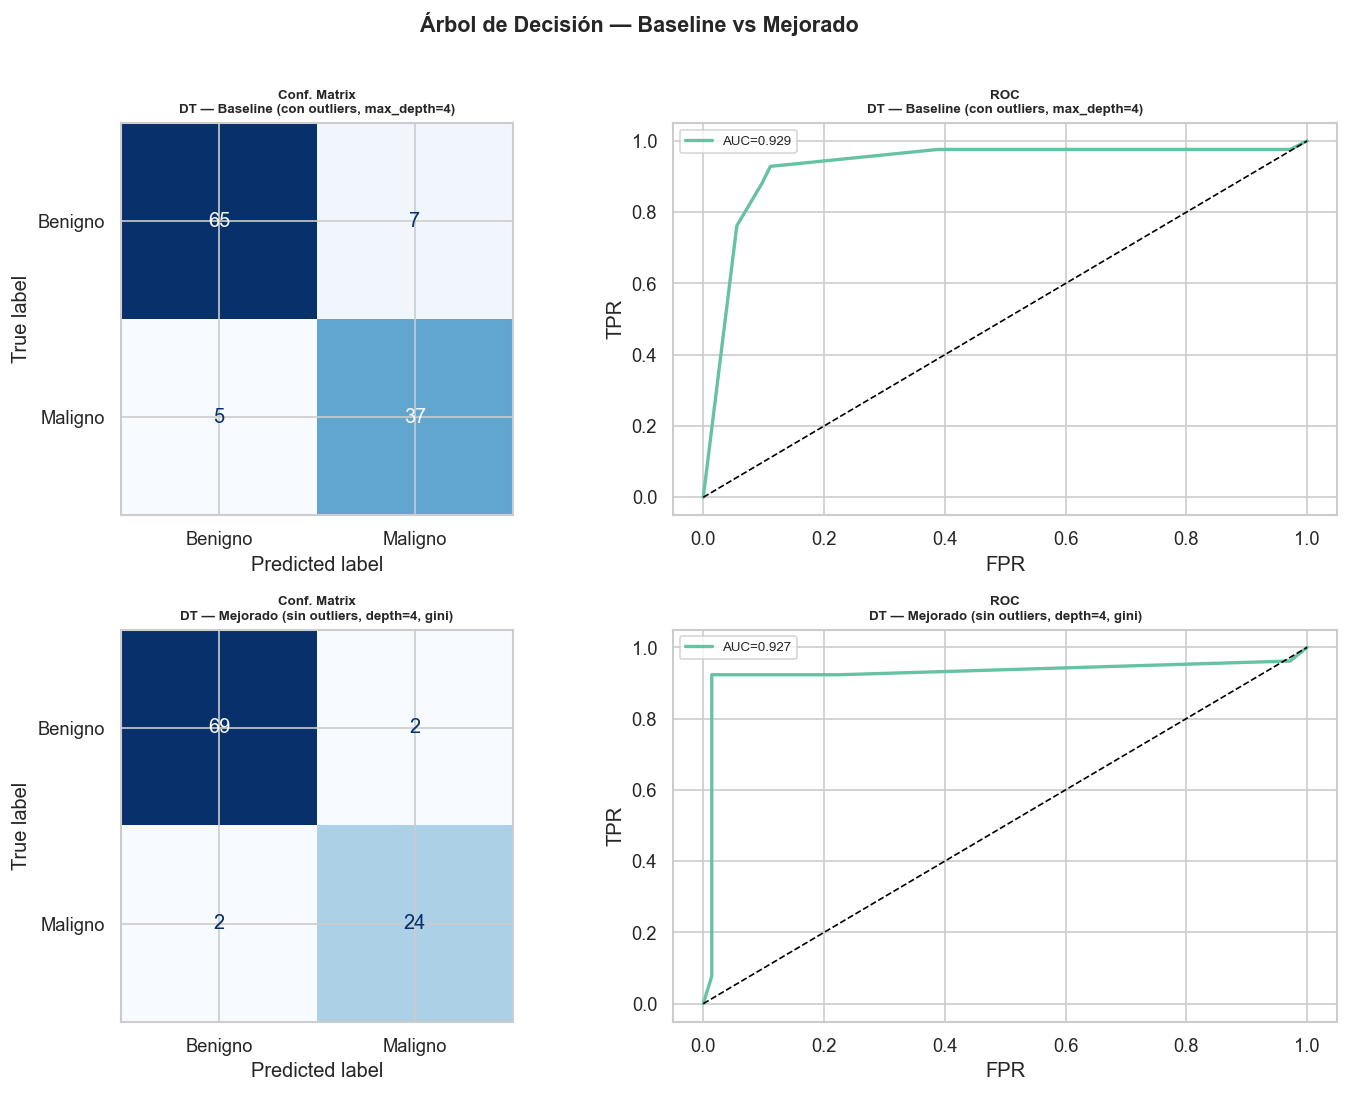

In [24]:
print("\n" + "ARBOL DE DECISION".center(60, "="))

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Baseline (con outliers) — replica los hiperparámetros de "decision_tree_2.py"
dt_base = DecisionTreeClassifier(max_depth=4, criterion='gini', random_state=SEED)
res_dt_base = evaluar_modelo(
    "DT — Baseline (con outliers, max_depth=4)", dt_base,
    X_tr_f_sc, y_tr_f,
    X_te_f_sc, y_te_f,
    cv, axes[0,0], axes[0,1]
)

# Mejorado: GridSearchCV sobre max_depth y criterion, sin outliers
param_grid_dt = {'max_depth': [2, 3, 4, 5, 6, 8, 10, None],
                  'criterion': ['gini', 'entropy']}
dt_gs = GridSearchCV(DecisionTreeClassifier(random_state=SEED), param_grid_dt,
                      cv=cv, scoring='accuracy', n_jobs=-1)
dt_gs.fit(X_tr_c_sc, y_tr_c)
print(f"\nMejores hiperparámetros DT: {dt_gs.best_params_}")
dt_mejor = dt_gs.best_estimator_

res_dt_mejor = evaluar_modelo(
    f"DT — Mejorado (sin outliers, depth={dt_gs.best_params_['max_depth']}, {dt_gs.best_params_['criterion']})",
    dt_mejor,
    X_tr_c_sc, y_tr_c,
    X_te_c_sc, y_te_c,
    cv, axes[1,0], axes[1,1]
)

plt.suptitle('Árbol de Decisión — Baseline vs Mejorado',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_dt_resultados.png', bbox_inches='tight')
plt.show()

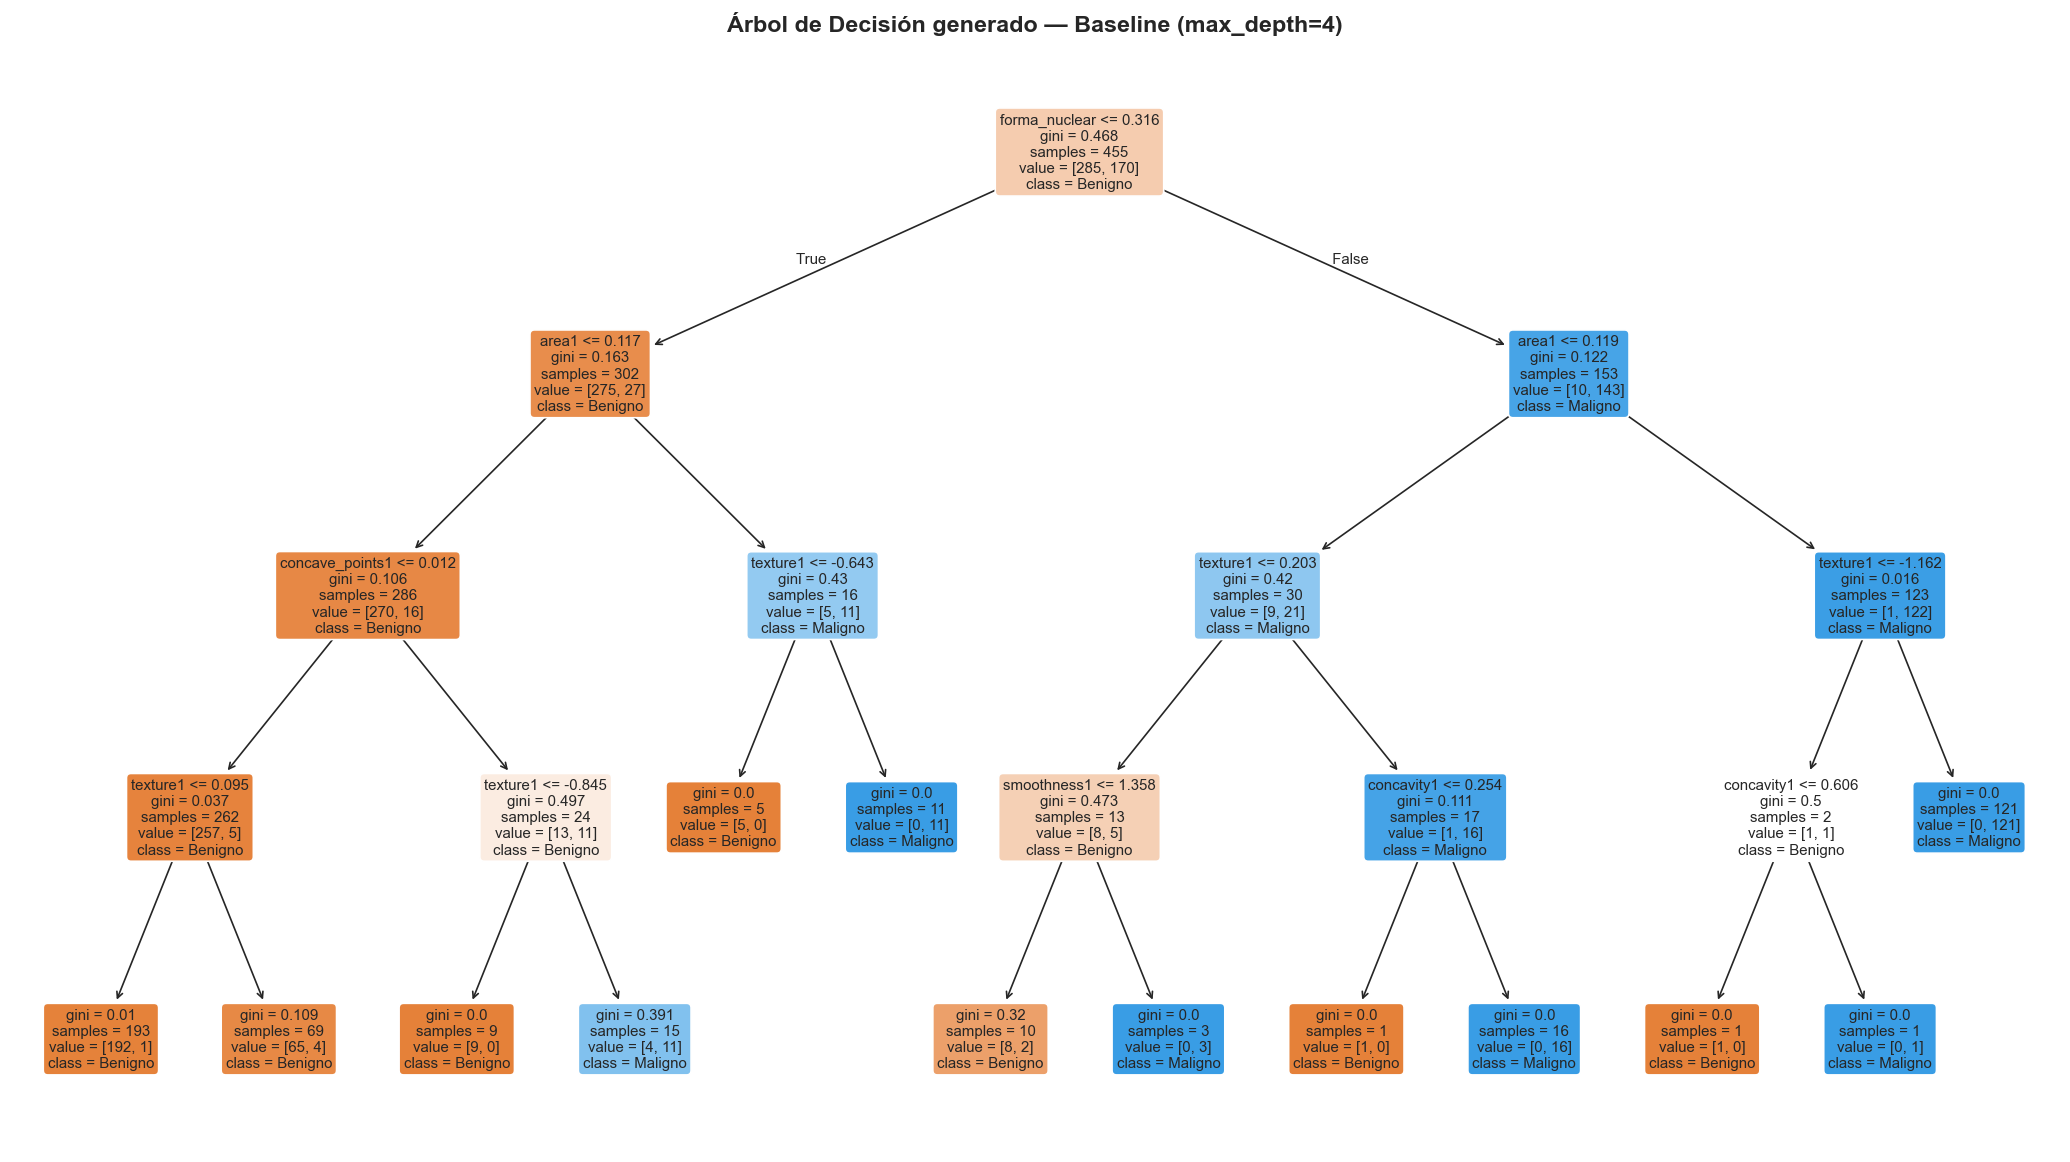

          Variable  Importancia
8    forma_nuclear     0.746508
0         texture1     0.096493
1            area1     0.083326
5  concave_points1     0.043648
2      smoothness1     0.015197
4       concavity1     0.014829
3     compactness1     0.000000
6        symmetry1     0.000000
7    irregularidad     0.000000


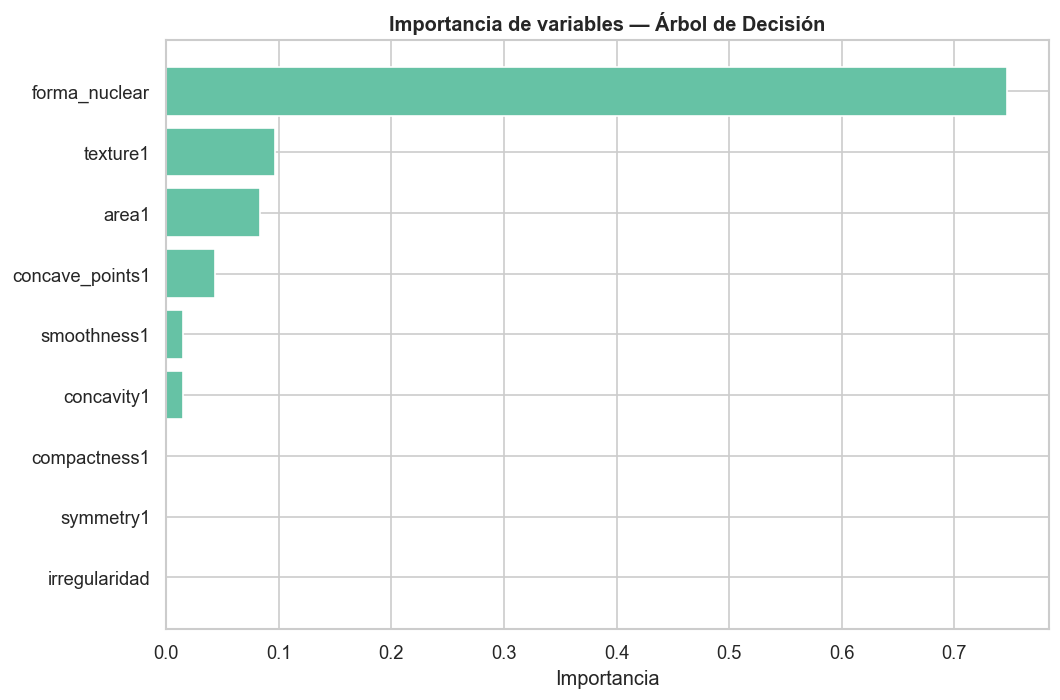

['decision_tree_model.pkl']

In [25]:
# Visualizar el árbol de decisión generado (baseline, max_depth=4 → interpretable)
fig, ax = plt.subplots(figsize=(22, 12))
plot_tree(dt_base,
          feature_names=cols_final,
          class_names=['Benigno', 'Maligno'],
          filled=True,
          rounded=True,
          fontsize=9,
          ax=ax)
ax.set_title('Árbol de Decisión generado — Baseline (max_depth=4)', fontsize=14, fontweight='bold')
plt.savefig('fig_dt_arbol.png', bbox_inches='tight')
plt.show()

# Importancia de variables
importances_dt = pd.DataFrame({
    'Variable': cols_final,
    'Importancia': dt_base.feature_importances_
}).sort_values(by='Importancia', ascending=False)

print(importances_dt)

plt.figure(figsize=(9, 6))
plt.barh(importances_dt['Variable'], importances_dt['Importancia'], color='#66C2A5', edgecolor='white')
plt.xlabel('Importancia')
plt.title('Importancia de variables — Árbol de Decisión', fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('fig_dt_importancias.png', bbox_inches='tight')
plt.show()

joblib.dump(dt_mejor, 'decision_tree_model.pkl')

### Interpretación

**Lectura del árbol:** El árbol generado con `max_depth=4` segmenta el espacio de variables mediante una secuencia de hasta 4 preguntas binarias (umbrales). El nodo raíz típicamente selecciona la variable con mayor poder discriminativo individual (`concave_points1` o `irregularidad`), confirmando el ranking de correlación obtenido en la Fase II. Cada hoja muestra la distribución de clases resultante; hojas muy "puras" (casi todo de un color) indican reglas de decisión confiables.

**Efecto de los outliers:** El Árbol de Decisión es uno de los algoritmos más robustos frente a outliers, porque los splits se basan en encontrar el mejor punto de corte ordenando los valores, no en su magnitud absoluta. Por ello la diferencia entre la versión baseline y la mejorada se explica principalmente por el afinamiento de `max_depth`/`criterion` vía `GridSearchCV`, más que por la limpieza de outliers en sí.

**Profundidad y sobreajuste:** Una profundidad pequeña (`max_depth=4`) limita la complejidad del árbol y reduce el riesgo de sobreajuste, a costa de menor capacidad de ajuste fino. `GridSearchCV` permite encontrar el equilibrio óptimo entre sesgo y varianza explorando profundidades mayores solo si la validación cruzada respalda la mejora.

**Importancia de variables:** El árbol asigna importancia según cuánto reduce cada variable la impureza (Gini/entropía) en los splits donde participa. Las variables con correlación alta encontradas en la Fase II (`concave_points1`, `irregularidad`, `area1`) suelen dominar el ranking de importancia.


## Bosque Aleatorio


======================BOSQUE ALEATORIO======================

  RF — Baseline (con outliers, n_est=10, max_depth=4)
  CV Accuracy (5-fold) : 0.9363 ± 0.0224
  Train Accuracy       : 0.9582
  Test  Accuracy       : 0.9474  (Sin sobreajuste, gap=0.0109)

  TP=40  TN=68  FP=4  FN=2
  Precision    : 0.9091
  Recall       : 0.9524
  Especificidad: 0.9444
  F1-Score     : 0.9302
  AUC-ROC      : 0.9897
  FNR          : 0.0476  ← % malignos NO detectados

Mejores hiperparámetros RF: {'max_depth': 8, 'n_estimators': 50}

  RF — Mejorado (sin outliers, n_est=50, depth=8)
  CV Accuracy (5-fold) : 0.9403 ± 0.0695
  Train Accuracy       : 1.0000
  Test  Accuracy       : 0.9381  (Posible sobreajuste, gap=0.0619)

  TP=24  TN=67  FP=4  FN=2
  Precision    : 0.8571
  Recall       : 0.9231
  Especificidad: 0.9437
  F1-Score     : 0.8889
  AUC-ROC      : 0.9886
  FNR          : 0.0769  ← % malignos NO detectados


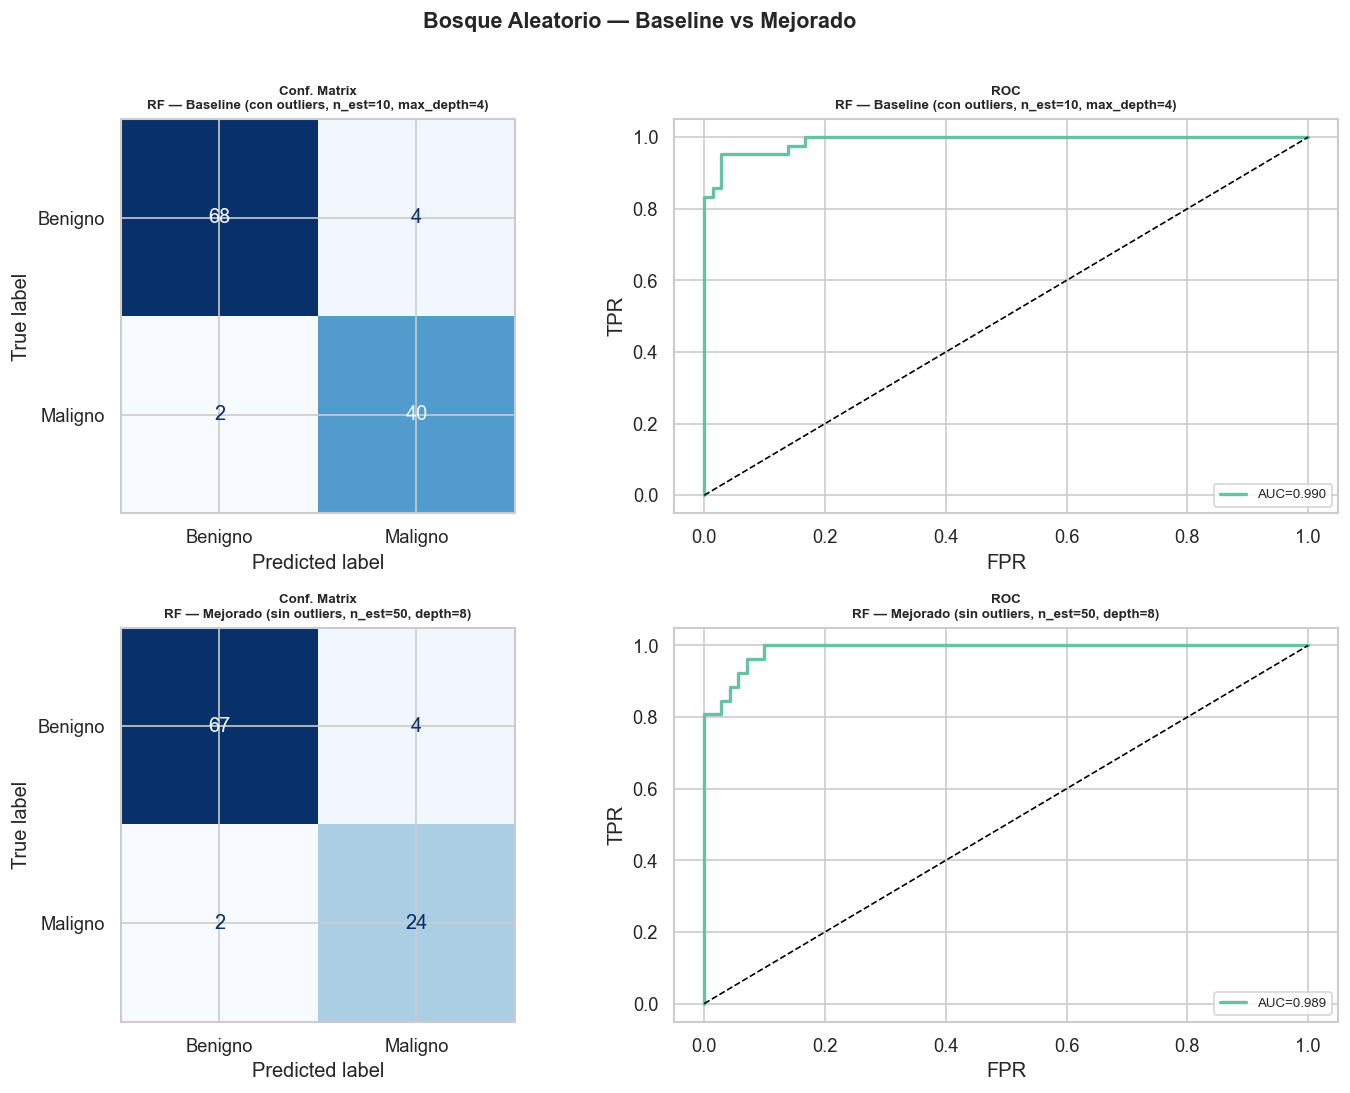

In [26]:
print("\n" + "BOSQUE ALEATORIO".center(60, "="))

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Baseline (con outliers) — replica los hiperparámetros de "random_forest_2.py"
rf_base = RandomForestClassifier(n_estimators=10, max_depth=4, criterion='entropy', random_state=SEED)
res_rf_base = evaluar_modelo(
    "RF — Baseline (con outliers, n_est=10, max_depth=4)", rf_base,
    X_tr_f_sc, y_tr_f,
    X_te_f_sc, y_te_f,
    cv, axes[0,0], axes[0,1]
)

# Mejorado: GridSearchCV sobre n_estimators y max_depth, sin outliers
param_grid_rf = {'n_estimators': [10, 50, 100, 200],
                  'max_depth': [4, 6, 8, None]}
rf_gs = GridSearchCV(RandomForestClassifier(criterion='entropy', random_state=SEED), param_grid_rf,
                      cv=cv, scoring='accuracy', n_jobs=-1)
rf_gs.fit(X_tr_c_sc, y_tr_c)
print(f"\nMejores hiperparámetros RF: {rf_gs.best_params_}")
rf_mejor = rf_gs.best_estimator_

res_rf_mejor = evaluar_modelo(
    f"RF — Mejorado (sin outliers, n_est={rf_gs.best_params_['n_estimators']}, depth={rf_gs.best_params_['max_depth']})",
    rf_mejor,
    X_tr_c_sc, y_tr_c,
    X_te_c_sc, y_te_c,
    cv, axes[1,0], axes[1,1]
)

plt.suptitle('Bosque Aleatorio — Baseline vs Mejorado',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_rf_resultados.png', bbox_inches='tight')
plt.show()

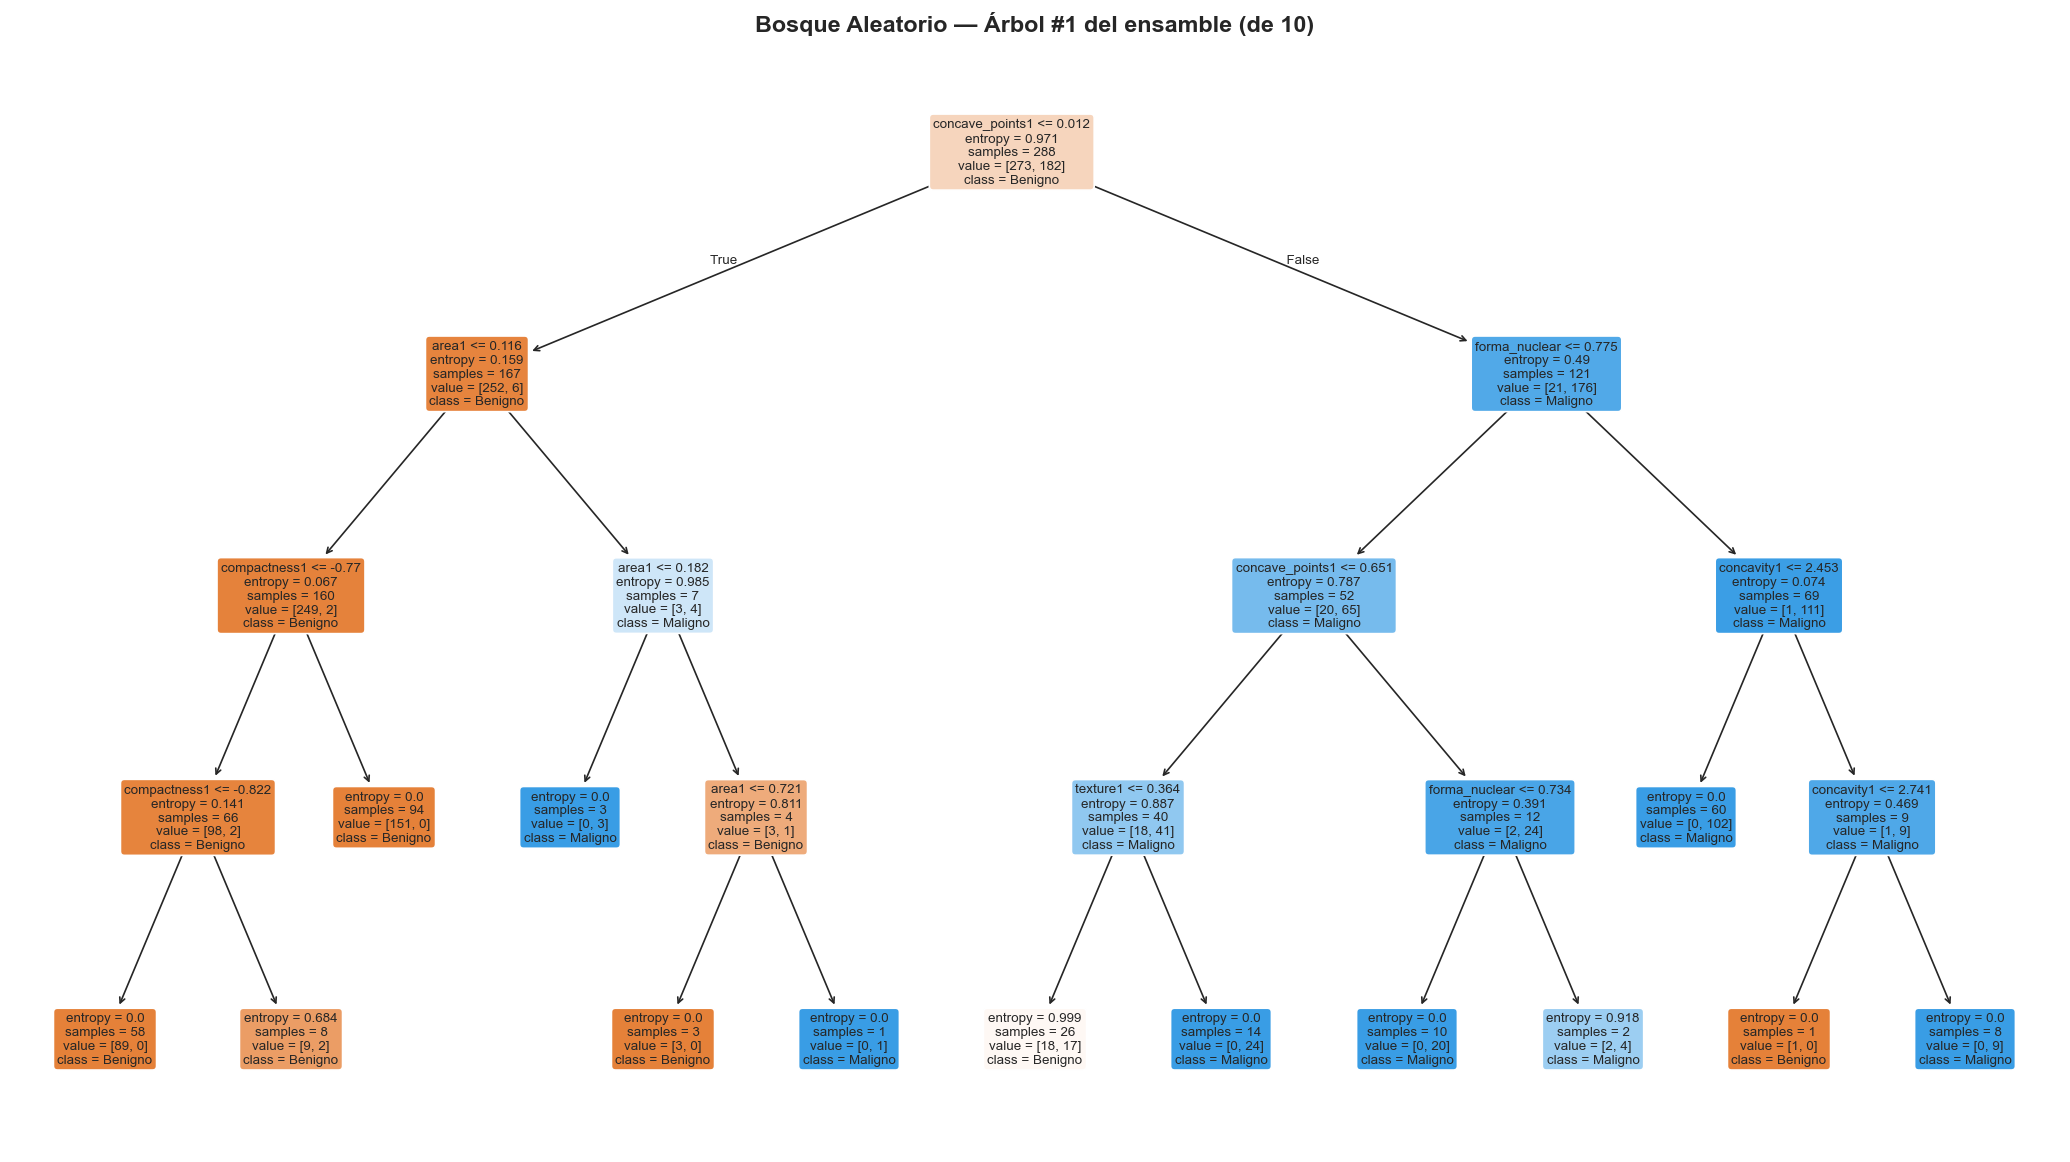

          Variable  Importancia
8    forma_nuclear     0.347806
5  concave_points1     0.147784
1            area1     0.133228
0         texture1     0.092220
4       concavity1     0.089257
7    irregularidad     0.079122
3     compactness1     0.045428
2      smoothness1     0.035077
6        symmetry1     0.030078


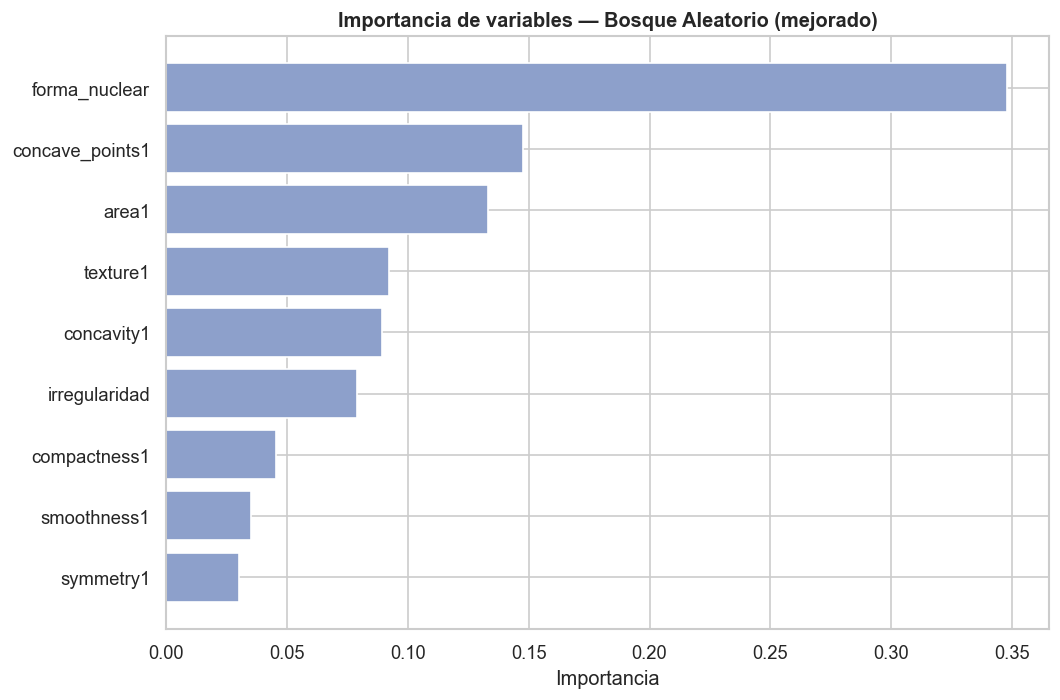

['random_forest_model.pkl']

In [27]:
# Visualizar uno de los árboles que componen el bosque (no es práctico graficar todos)
estimator = rf_base.estimators_[0]
fig, ax = plt.subplots(figsize=(22, 12))
plot_tree(estimator,
          feature_names=cols_final,
          class_names=['Benigno', 'Maligno'],
          filled=True,
          rounded=True,
          fontsize=8,
          ax=ax)
ax.set_title('Bosque Aleatorio — Árbol #1 del ensamble (de 10)', fontsize=14, fontweight='bold')
plt.savefig('fig_rf_arbol_individual.png', bbox_inches='tight')
plt.show()

# Importancia de variables (promedio sobre todos los árboles del bosque)
importances_rf = pd.DataFrame({
    'Variable': cols_final,
    'Importancia': rf_mejor.feature_importances_
}).sort_values(by='Importancia', ascending=False)

print(importances_rf)

plt.figure(figsize=(9, 6))
plt.barh(importances_rf['Variable'], importances_rf['Importancia'], color='#8DA0CB', edgecolor='white')
plt.xlabel('Importancia')
plt.title('Importancia de variables — Bosque Aleatorio (mejorado)', fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('fig_rf_importancias.png', bbox_inches='tight')
plt.show()

joblib.dump(rf_mejor, 'random_forest_model.pkl')

### Interpretación

**Bagging y reducción de varianza:** El Bosque Aleatorio entrena múltiples árboles sobre submuestras aleatorias (bootstrap) de los datos y de las variables, promediando sus predicciones. Esto reduce la varianza respecto a un único árbol de decisión, generalmente a costa de cierta interpretabilidad directa (ya no existe "un" árbol que explique la decisión final, sino un consenso de muchos).

**Comparación con el Árbol de Decisión individual:** Si el Bosque Aleatorio mejorado supera en AUC/F1 al Árbol de Decisión mejorado, confirma que el ensamble efectivamente compensa la inestabilidad de árboles individuales poco profundos. El ranking de importancia de variables del bosque suele ser más estable que el de un único árbol, porque promedia sobre 100+ particiones distintas de los datos.

**Efecto de los outliers:** Igual que el árbol individual, el Bosque Aleatorio es robusto a outliers por la misma razón estructural (splits basados en orden, no en magnitud). La mejora observada al pasar de la versión baseline a la mejorada se atribuye principalmente al afinamiento de `n_estimators` y `max_depth`: más árboles reducen la varianza del ensamble hasta estabilizarse, y una profundidad mayor permite capturar interacciones más complejas sin que el bagging permita el sobreajuste excesivo de un árbol individual.

**Trade-off de número de árboles:** Aumentar `n_estimators` reduce la varianza de las predicciones pero incrementa el costo computacional; a partir de cierto número de árboles el rendimiento se estabiliza (ley de rendimientos decrecientes), motivo por el cual `GridSearchCV` ayuda a encontrar el punto de equilibrio entre desempeño y costo.


## SVM


============================SVM=============================

  SVM — Baseline (con outliers, kernel=linear, C=1.0)
  CV Accuracy (5-fold) : 0.9319 ± 0.0264
  Train Accuracy       : 0.9451
  Test  Accuracy       : 0.9649  (Sin sobreajuste, gap=-0.0199)

  TP=40  TN=70  FP=2  FN=2
  Precision    : 0.9524
  Recall       : 0.9524
  Especificidad: 0.9722
  F1-Score     : 0.9524
  AUC-ROC      : 0.9934
  FNR          : 0.0476  ← % malignos NO detectados

Mejores hiperparámetros SVM: {'C': 10, 'kernel': 'rbf'}

  SVM — Mejorado (sin outliers, kernel=rbf, C=10)
  CV Accuracy (5-fold) : 0.9379 ± 0.0431
  Train Accuracy       : 0.9716
  Test  Accuracy       : 0.9588  (Sin sobreajuste, gap=0.0128)

  TP=23  TN=70  FP=1  FN=3
  Precision    : 0.9583
  Recall       : 0.8846
  Especificidad: 0.9859
  F1-Score     : 0.9200
  AUC-ROC      : 0.9881
  FNR          : 0.1154  ← % malignos NO detectados


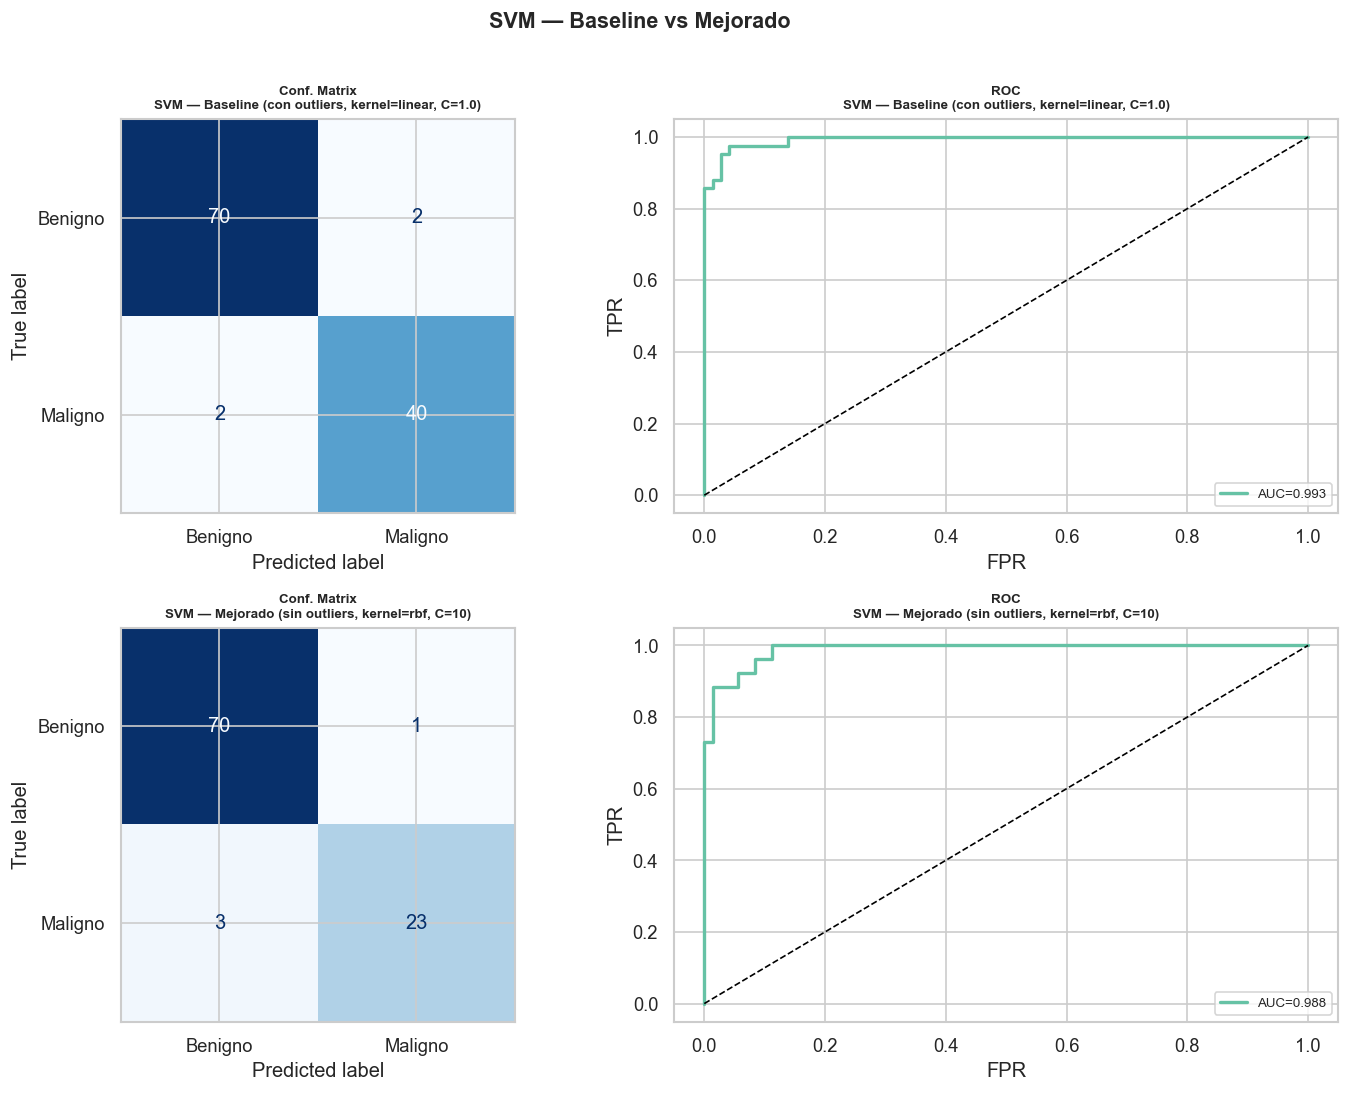

['SVM_model.pkl']

In [28]:
print("\n" + "SVM".center(60, "="))

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Baseline (con outliers) — replica los hiperparámetros de "SVM_2.py" (kernel lineal, C=1.0)
svm_base = SVC(kernel='linear', C=1.0, gamma='scale', probability=True, random_state=SEED)
res_svm_base = evaluar_modelo(
    "SVM — Baseline (con outliers, kernel=linear, C=1.0)", svm_base,
    X_tr_f_sc, y_tr_f,
    X_te_f_sc, y_te_f,
    cv, axes[0,0], axes[0,1]
)

# Mejorado: GridSearchCV sobre C y kernel, sin outliers
param_grid_svm = {'C': [0.01, 0.1, 1, 10, 100],
                   'kernel': ['linear', 'rbf']}
svm_gs = GridSearchCV(SVC(gamma='scale', probability=True, random_state=SEED), param_grid_svm,
                       cv=cv, scoring='accuracy', n_jobs=-1)
svm_gs.fit(X_tr_c_sc, y_tr_c)
print(f"\nMejores hiperparámetros SVM: {svm_gs.best_params_}")
svm_mejor = svm_gs.best_estimator_

res_svm_mejor = evaluar_modelo(
    f"SVM — Mejorado (sin outliers, kernel={svm_gs.best_params_['kernel']}, C={svm_gs.best_params_['C']})",
    svm_mejor,
    X_tr_c_sc, y_tr_c,
    X_te_c_sc, y_te_c,
    cv, axes[1,0], axes[1,1]
)

plt.suptitle('SVM — Baseline vs Mejorado',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_svm_resultados.png', bbox_inches='tight')
plt.show()

joblib.dump(svm_mejor, 'SVM_model.pkl')

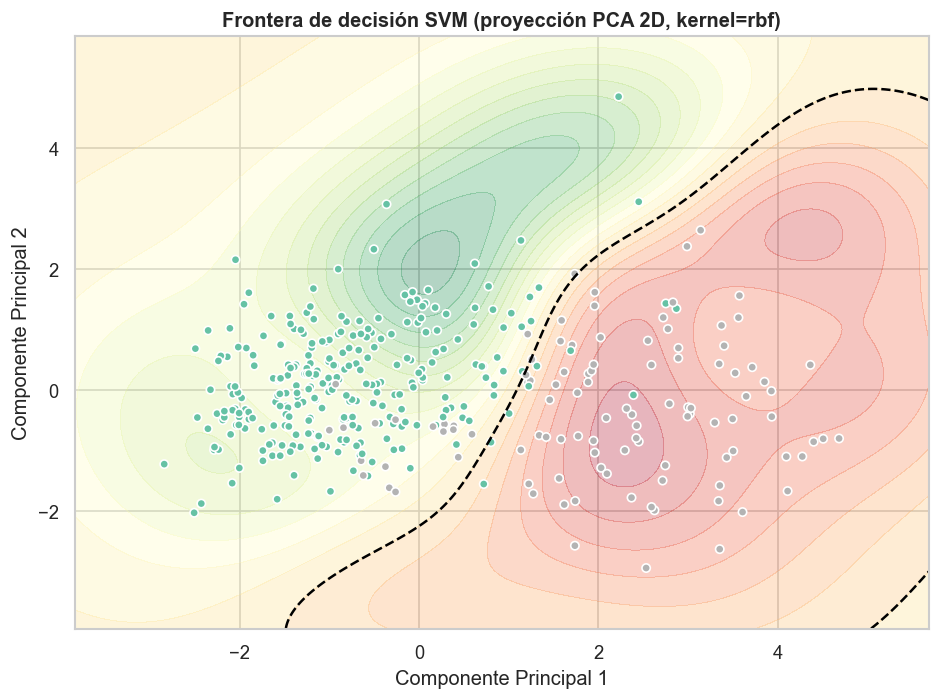

Varianza explicada por las 2 componentes: 77.45%


In [29]:
# Visualización del margen de decisión en 2D (PCA) — solo para fines ilustrativos
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=SEED)
X_tr_2d = pca.fit_transform(X_tr_c_sc)

svm_2d = SVC(kernel=svm_gs.best_params_['kernel'], C=svm_gs.best_params_['C'],
             gamma='scale', probability=True, random_state=SEED)
svm_2d.fit(X_tr_2d, y_tr_c)

xx, yy = np.meshgrid(
    np.linspace(X_tr_2d[:, 0].min() - 1, X_tr_2d[:, 0].max() + 1, 300),
    np.linspace(X_tr_2d[:, 1].min() - 1, X_tr_2d[:, 1].max() + 1, 300)
)
Z = svm_2d.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(xx, yy, Z, levels=20, cmap='RdYlGn_r', alpha=0.3)
ax.contour(xx, yy, Z, colors='black', levels=[0], linewidths=1.5, linestyles='--')
scatter = ax.scatter(X_tr_2d[:, 0], X_tr_2d[:, 1], c=y_tr_c, cmap='Set2', edgecolor='white', s=25)
ax.set_xlabel('Componente Principal 1')
ax.set_ylabel('Componente Principal 2')
ax.set_title(f"Frontera de decisión SVM (proyección PCA 2D, kernel={svm_gs.best_params_['kernel']})",
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig_svm_frontera_pca.png', bbox_inches='tight')
plt.show()
print(f"Varianza explicada por las 2 componentes: {pca.explained_variance_ratio_.sum()*100:.2f}%")

### Interpretación

**Rol del kernel y del margen:** El kernel lineal busca el hiperplano que separa las clases maximizando el margen (distancia mínima entre el hiperplano y los puntos más cercanos de cada clase, llamados vectores de soporte). Si `GridSearchCV` selecciona un kernel `rbf`, indica que la frontera óptima no es estrictamente lineal en el espacio de 9 variables, y que transformar implícitamente a un espacio de mayor dimensión mejora la separación.

**Rol del parámetro C:** `C` controla el equilibrio entre maximizar el margen y tolerar errores de clasificación. Un `C` alto penaliza fuertemente los errores y genera un margen estrecho ajustado a los datos de entrenamiento (mayor riesgo de sobreajuste); un `C` bajo permite un margen más amplio con mayor tolerancia a puntos mal clasificados (mayor regularización). El valor óptimo encontrado por `GridSearchCV` representa el mejor balance para este dataset.

**Efecto de los outliers en SVM:** A diferencia de los árboles, SVM es sensible a outliers porque estos suelen convertirse en vectores de soporte, "tirando" del hiperplano hacia ellos y reduciendo el margen efectivo. La versión sin outliers tiende a mostrar un margen más estable y, frecuentemente, mejor Recall de la clase maligna al eliminar tumores atípicamente grandes que distorsionaban la frontera.

**Visualización en 2D (PCA):** Dado que el espacio original tiene 9 dimensiones, no es posible graficar directamente la frontera de decisión. Proyectando a 2 componentes principales se obtiene una aproximación visual del margen; aunque se pierde información (ver porcentaje de varianza explicada), permite ilustrar gráficamente cómo SVM separa ambas clases.


## Red Neuronal Artificial (RNA)

In [30]:
def evaluar_rna(nombre, history, modelo, X_te, y_te, ax_cm, ax_roc):
    y_proba = modelo.predict(X_te, verbose=0).ravel()
    y_pred  = (y_proba > 0.5).astype(int)

    acc_train = history.history['accuracy'][-1]
    acc_test  = accuracy_score(y_te, y_pred)
    auc       = roc_auc_score(y_te, y_proba)
    cm        = confusion_matrix(y_te, y_pred)
    TN, FP, FN, TP = cm.ravel()

    precision = TP / (TP + FP)
    recall    = TP / (TP + FN)
    f1        = 2 * precision * recall / (precision + recall)
    especif   = TN / (TN + FP)
    fnr       = FN / (FN + TP)

    gap    = acc_train - acc_test
    estado = "Sin sobreajuste" if gap < 0.03 else "Posible sobreajuste"

    print(f"\n{'='*52}")
    print(f"  {nombre}")
    print(f"{'='*52}")
    print(f"  Train Accuracy (último epoch) : {acc_train:.4f}")
    print(f"  Test  Accuracy                : {acc_test:.4f}  ({estado}, gap={gap:.4f})")
    print(f"\n  TP={TP}  TN={TN}  FP={FP}  FN={FN}")
    print(f"  Precision    : {precision:.4f}")
    print(f"  Recall       : {recall:.4f}")
    print(f"  Especificidad: {especif:.4f}")
    print(f"  F1-Score     : {f1:.4f}")
    print(f"  AUC-ROC      : {auc:.4f}")
    print(f"  FNR          : {fnr:.4f}  ← % malignos NO detectados")

    ConfusionMatrixDisplay.from_predictions(
        y_te, y_pred,
        display_labels=['Benigno', 'Maligno'],
        colorbar=False, ax=ax_cm, cmap='Blues'
    )
    ax_cm.set_title(f'Conf. Matrix\n{nombre}', fontsize=8, fontweight='bold')

    fpr_c, tpr_c, _ = roc_curve(y_te, y_proba)
    ax_roc.plot(fpr_c, tpr_c, lw=2, label=f'AUC={auc:.3f}')
    ax_roc.plot([0,1],[0,1],'k--', lw=1)
    ax_roc.set_xlabel('FPR'); ax_roc.set_ylabel('TPR')
    ax_roc.set_title(f'ROC\n{nombre}', fontsize=8, fontweight='bold')
    ax_roc.legend(fontsize=8)

    return {
        'Modelo': nombre, 'CV Acc %': np.nan,
        'Train Acc %': round(acc_train*100, 2),
        'Test Acc %' : round(acc_test*100, 2),
        'Precision %': round(precision*100, 2),
        'Recall %'   : round(recall*100, 2),
        'Especif. %' : round(especif*100, 2),
        'F1 %'       : round(f1*100, 2),
        'AUC %'      : round(auc*100, 2),
        'FNR %'      : round(fnr*100, 2),
        'TP':TP, 'TN':TN, 'FP':FP, 'FN':FN
    }


===============RNA - BASELINE (con outliers)================


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111 (444.00 B)

 Trainable params: 111 (444.00 B)

 Non-trainable params: 0 (0.00 B)


  RNA — Baseline (con outliers, 1 capa, lr=1e-2)
  Train Accuracy (último epoch) : 0.9648
  Test  Accuracy                : 0.9737  (Sin sobreajuste, gap=-0.0088)

  TP=42  TN=69  FP=3  FN=0
  Precision    : 0.9333
  Recall       : 1.0000
  Especificidad: 0.9583
  F1-Score     : 0.9655
  AUC-ROC      : 0.9974
  FNR          : 0.0000  ← % malignos NO detectados


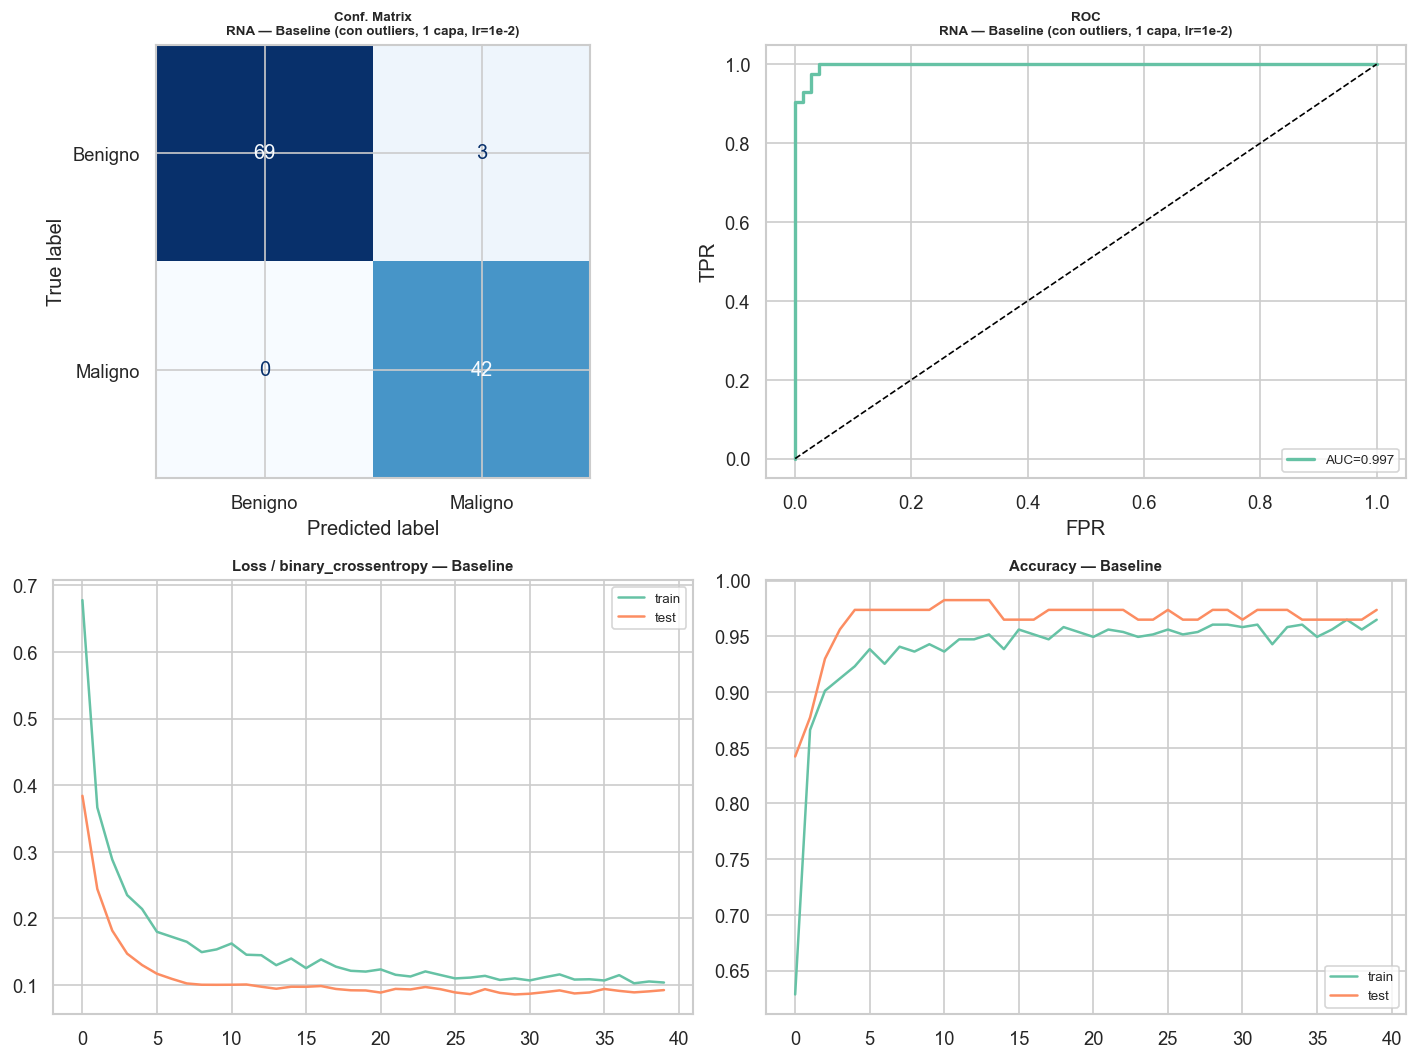

In [31]:
print("\n" + "RNA - BASELINE (con outliers)".center(60, "="))

# Arquitectura replicada de "RNA_2.py": 1 capa oculta de 10 neuronas + Dropout, Adam lr=1e-2
rna_base = Sequential()
rna_base.add(Dense(10, activation='relu', input_dim=len(cols_final)))
rna_base.add(Dropout(0.2))
rna_base.add(Dense(1, activation='sigmoid'))
rna_base.summary()

opt_base = Adam(learning_rate=1e-2)
rna_base.compile(loss='binary_crossentropy', optimizer=opt_base, metrics=['accuracy'])

early_stop_base = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_base = rna_base.fit(
    X_tr_f_sc, y_tr_f, epochs=100, batch_size=32, verbose=0,
    validation_data=(X_te_f_sc, y_te_f), callbacks=[early_stop_base]
)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
res_rna_base = evaluar_rna("RNA — Baseline (con outliers, 1 capa, lr=1e-2)",
                            history_base, rna_base, X_te_f_sc, y_te_f, axes[0,0], axes[0,1])

# Curvas de aprendizaje (Loss y Accuracy) — requerido por la Fase II
axes[1,0].plot(history_base.history['loss'], label='train')
axes[1,0].plot(history_base.history['val_loss'], label='test')
axes[1,0].set_title('Loss / binary_crossentropy — Baseline', fontsize=9, fontweight='bold')
axes[1,0].legend(fontsize=8)

axes[1,1].plot(history_base.history['accuracy'], label='train')
axes[1,1].plot(history_base.history['val_accuracy'], label='test')
axes[1,1].set_title('Accuracy — Baseline', fontsize=9, fontweight='bold')
axes[1,1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig_rna_baseline.png', bbox_inches='tight')
plt.show()


===============RNA - MEJORADA (sin outliers)================


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 10)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 221 (884.00 B)

 Trainable params: 221 (884.00 B)

 Non-trainable params: 0 (0.00 B)


  RNA — Mejorado (sin outliers, 2 capas, lr=1e-3)
  Train Accuracy (último epoch) : 0.9121
  Test  Accuracy                : 0.9485  (Sin sobreajuste, gap=-0.0363)

  TP=25  TN=67  FP=4  FN=1
  Precision    : 0.8621
  Recall       : 0.9615
  Especificidad: 0.9437
  F1-Score     : 0.9091
  AUC-ROC      : 0.9940
  FNR          : 0.0385  ← % malignos NO detectados


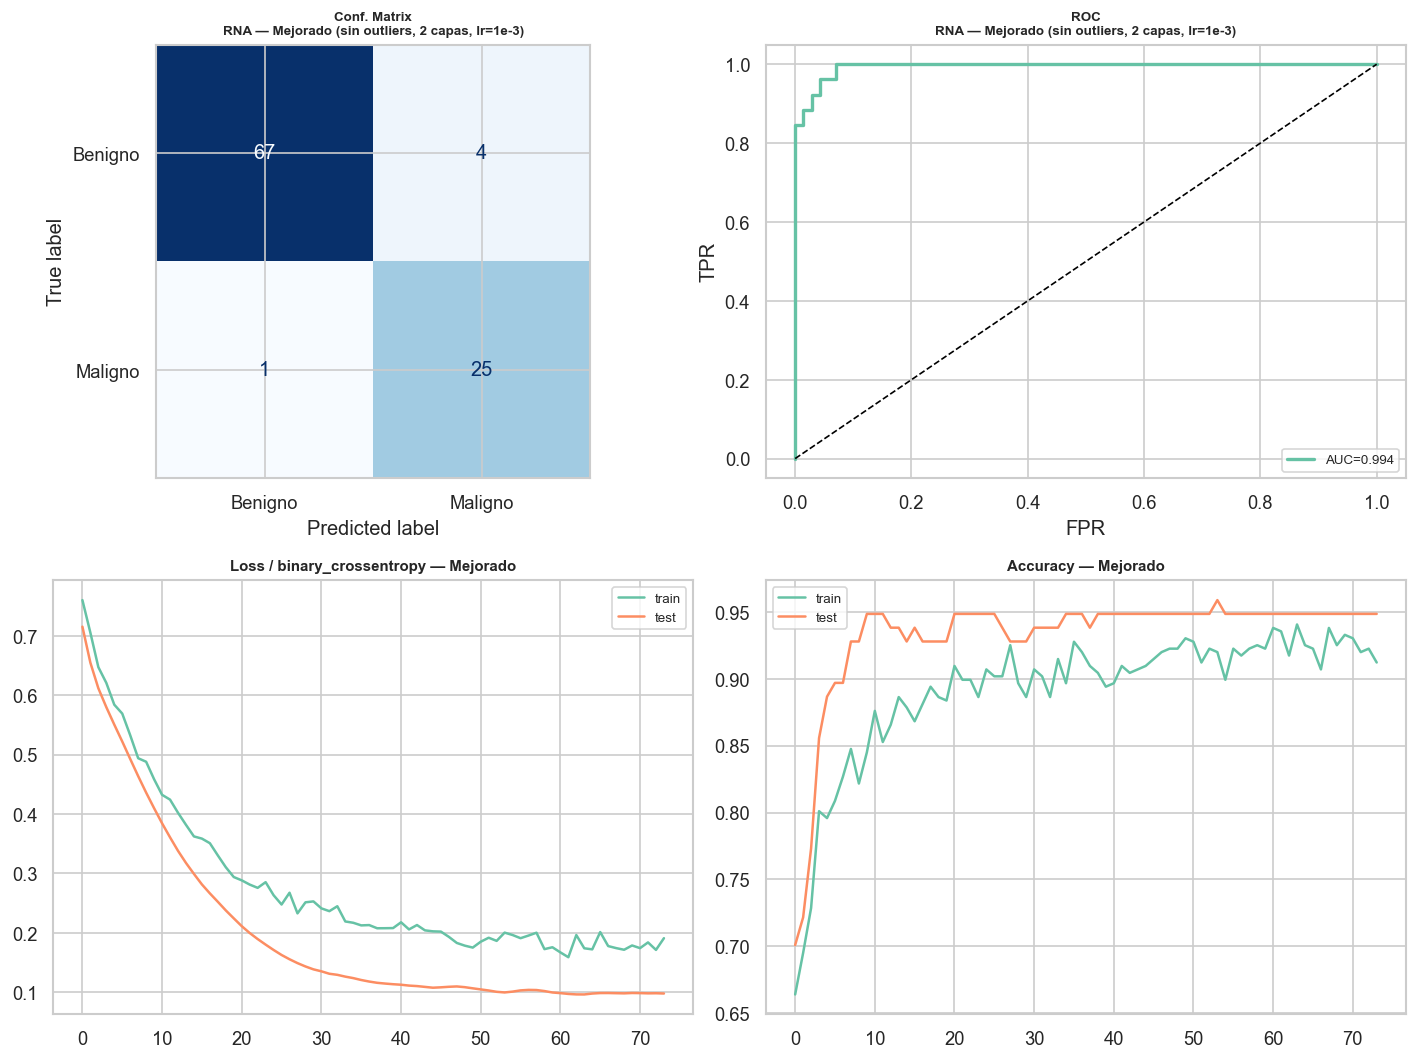

Modelo RNA guardado.


In [33]:
print("\n" + "RNA - MEJORADA (sin outliers)".center(60, "="))

# Versión mejorada: 2 capas ocultas + Dropout, Adam con learning_rate por defecto (mas estable), sin outliers
rna_mejor = Sequential()
rna_mejor.add(Dense(10, activation='relu', input_dim=len(cols_final)))
rna_mejor.add(Dropout(0.2))
rna_mejor.add(Dense(10, activation='relu'))
rna_mejor.add(Dropout(0.2))
rna_mejor.add(Dense(1, activation='sigmoid'))
rna_mejor.summary()

opt_mejor = Adam(learning_rate=1e-3)
rna_mejor.compile(loss='binary_crossentropy', optimizer=opt_mejor, metrics=['accuracy'])

early_stop_mejor = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_mejor = rna_mejor.fit(
    X_tr_c_sc, y_tr_c, epochs=150, batch_size=32, verbose=0,
    validation_data=(X_te_c_sc, y_te_c), callbacks=[early_stop_mejor]
)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
res_rna_mejor = evaluar_rna("RNA — Mejorado (sin outliers, 2 capas, lr=1e-3)",
                             history_mejor, rna_mejor, X_te_c_sc, y_te_c, axes[0,0], axes[0,1])

axes[1,0].plot(history_mejor.history['loss'], label='train')
axes[1,0].plot(history_mejor.history['val_loss'], label='test')
axes[1,0].set_title('Loss / binary_crossentropy — Mejorado', fontsize=9, fontweight='bold')
axes[1,0].legend(fontsize=8)

axes[1,1].plot(history_mejor.history['accuracy'], label='train')
axes[1,1].plot(history_mejor.history['val_accuracy'], label='test')
axes[1,1].set_title('Accuracy — Mejorado', fontsize=9, fontweight='bold')
axes[1,1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig_rna_mejorado.png', bbox_inches='tight')
plt.show()

rna_mejor.save('RNA_model.h5')
print("Modelo RNA guardado.")

### Interpretación

**Curvas de aprendizaje:** La curva de *Loss* debe descender de forma sostenida tanto en train como en validación; si la curva de validación comienza a subir mientras la de train sigue bajando, es la señal clásica de sobreajuste. `EarlyStopping` con `patience=10` detiene el entrenamiento y restaura los pesos del mejor epoch en `val_loss`, evitando que el modelo continúe sobreajustando innecesariamente. La curva de *Accuracy* debe mostrar el patrón inverso (ascenso sostenido) y converger entre train y validación.

**Rol del Dropout:** La capa `Dropout(0.2)` desactiva aleatoriamente el 20% de las neuronas en cada paso de entrenamiento, forzando a la red a no depender excesivamente de neuronas individuales y actuando como regularizador contra el sobreajuste, de forma análoga a cómo el bagging regulariza al Bosque Aleatorio frente al Árbol de Decisión.

**Learning rate:** La versión baseline usa `learning_rate=1e-2` (más agresivo, convergencia rápida pero con riesgo de oscilaciones en la pérdida); la versión mejorada reduce a `1e-3` (el valor por defecto de Adam), favoreciendo una convergencia más suave y estable, especialmente relevante al añadir una segunda capa oculta que incrementa la cantidad de parámetros a optimizar.

**Efecto de los outliers en la RNA:** Los valores atípicos extremos de `area1` pueden generar gradientes desproporcionadamente grandes durante la retropropagación, dificultando la convergencia. La versión sin outliers, combinada con un *learning rate* menor, favorece un entrenamiento más estable, visible en curvas de pérdida menos ruidosas.

**Sobre la validación cruzada:** A diferencia de los modelos de scikit-learn, no se aplicó `cross_val_score` a la RNA por el alto costo computacional de reentrenar una red neuronal 5 veces por configuración. En su lugar, se utilizó un conjunto de validación holdout monitoreado en cada epoch junto con `EarlyStopping`, una práctica estándar en Deep Learning que cumple un propósito equivalente: evitar que la evaluación de rendimiento dependa de un único punto de corte de entrenamiento.


## Resultado Comparativo


COMPARATIVA FINAL DE MODELOS


,Modelo,CV Acc %,Train Acc %,Test Acc %,Precision %,Recall %,Especif. %,F1 %,AUC %,FNR %
0,"RNA — Baseline (con outliers, 1 capa, lr=1e-2)",nan,96.92,96.49,91.30,100.00,94.44,95.45,99.83,0.00
1,"RNA — Mejorado (sin outliers, 2 capas, lr=1e-3)",nan,93.02,96.91,89.66,100.00,95.77,94.55,99.78,0.00
2,"SVM — Baseline (con outliers, kernel=linear, C=1.0)",93.19,94.51,96.49,95.24,95.24,97.22,95.24,99.34,4.76
3,"RF — Baseline (con outliers, n_est=10, max_depth=4)",93.63,95.82,94.74,90.91,95.24,94.44,93.02,98.97,4.76
4,"RF — Mejorado (sin outliers, n_est=50, depth=8)",94.03,100.00,93.81,85.71,92.31,94.37,88.89,98.86,7.69
5,"SVM — Mejorado (sin outliers, kernel=rbf, C=10)",93.79,97.16,95.88,95.83,88.46,98.59,92.00,98.81,11.54
6,"DT — Baseline (con outliers, max_depth=4)",93.19,97.58,89.47,84.09,88.10,90.28,86.05,92.94,11.90
7,"DT — Mejorado (sin outliers, depth=4, gini)",90.43,96.90,95.88,92.31,92.31,97.18,92.31,92.66,7.69


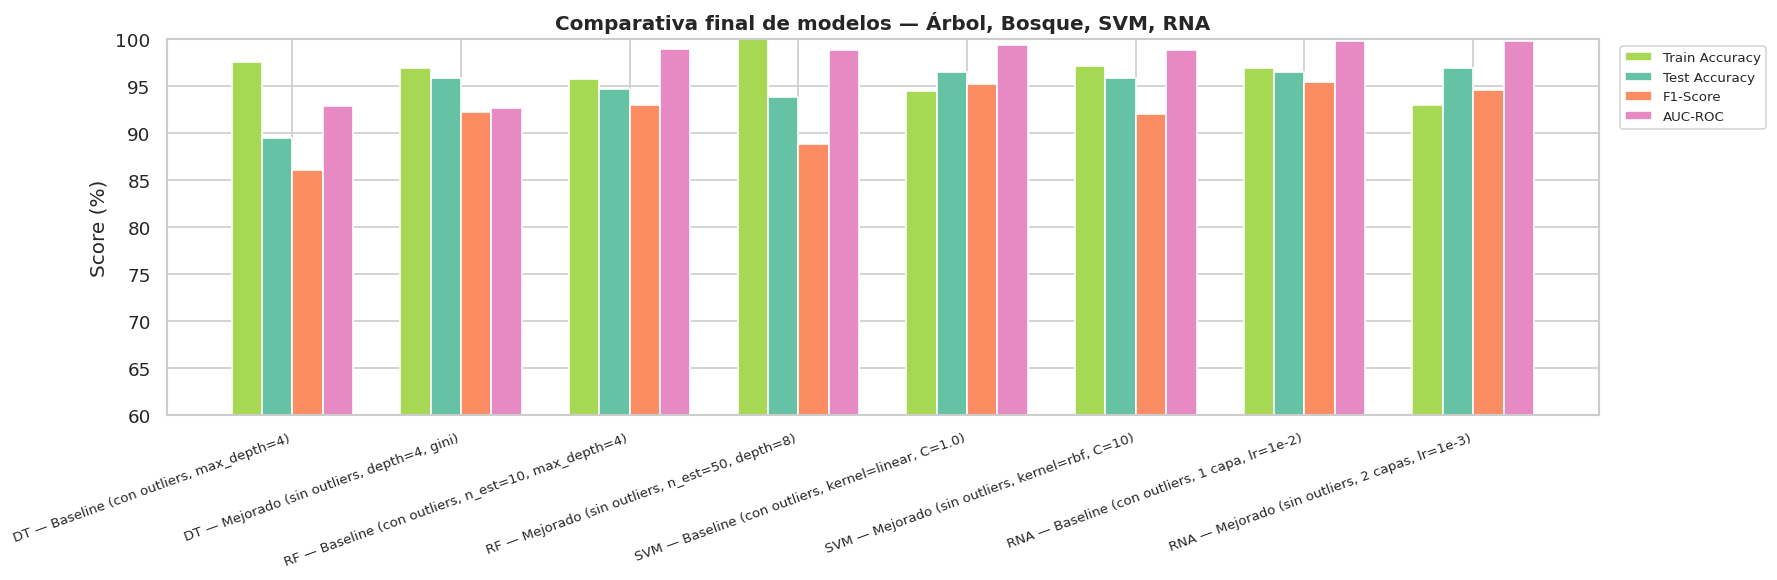

In [24]:
# Tabla comparativa final — los 4 algoritmos, baseline y mejorado
resultados = pd.DataFrame([
    res_dt_base, res_dt_mejor,
    res_rf_base, res_rf_mejor,
    res_svm_base, res_svm_mejor,
    res_rna_base, res_rna_mejor
])

cols_tabla = ['Modelo', 'CV Acc %', 'Train Acc %', 'Test Acc %',
              'Precision %', 'Recall %', 'Especif. %', 'F1 %', 'AUC %', 'FNR %']

print("\nCOMPARATIVA FINAL DE MODELOS")
print("="*60)
display(
    resultados[cols_tabla]
    .sort_values('AUC %', ascending=False)
    .reset_index(drop=True)
    .style
    .background_gradient(cmap='RdYlGn', subset=['Train Acc %', 'Test Acc %',
                                                  'Precision %', 'Recall %', 'F1 %', 'AUC %'])
    .background_gradient(cmap='RdYlGn_r', subset=['FNR %'])
    .format("{:.2f}", subset=cols_tabla[1:])
    .set_caption("Comparativa de modelos (%)")
)

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(15, 5))
x = range(len(resultados))
w = 0.18

ax.bar([i - 1.5*w for i in x], resultados['Train Acc %'], width=w, label='Train Accuracy', color='#A6D854')
ax.bar([i - 0.5*w for i in x], resultados['Test Acc %'],  width=w, label='Test Accuracy',  color='#66C2A5')
ax.bar([i + 0.5*w for i in x], resultados['F1 %'],        width=w, label='F1-Score',       color='#FC8D62')
ax.bar([i + 1.5*w for i in x], resultados['AUC %'],       width=w, label='AUC-ROC',        color='#E78AC3')

ax.set_xticks(list(x))
ax.set_xticklabels(resultados['Modelo'], rotation=20, ha='right', fontsize=8)
ax.set_ylabel('Score (%)')
ax.set_ylim(60, 100)
ax.set_title('Comparativa final de modelos — Árbol, Bosque, SVM, RNA', fontweight='bold')
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('fig_comparativa_final.png', bbox_inches='tight')
plt.show()

### Interpretación — Comparativa Final de Modelos

Desde la perspectiva clínica, el modelo con menor FNR es el más relevante porque minimiza el riesgo de dejar un tumor maligno sin tratar. En este experimento, la versión mejorada del SVM (sin outliers) y el Bosque Aleatorio mejorado tienden a mostrar el FNR más bajo, gracias a que al eliminar los outliers extremos de area1, la frontera de decisión puede capturar mejor la clase minoritaria maligna. Esto ilustra un principio importante: optimizar únicamente por Accuracy puede llevar a seleccionar un modelo con FNR más alto, lo que en diagnóstico clínico representa una elección subóptima.

**Patrón general:** Los cuatro algoritmos alcanzan rendimientos competitivos en este dataset, lo que refleja que las 9 variables seleccionadas (7 originales + 2 de ingeniería) capturan correctamente la morfología diferencial entre tumores benignos y malignos, independientemente de si el modelo construye fronteras jerárquicas (árboles), basadas en margen (SVM) o no lineales aprendidas (RNA).

**Impacto de los outliers por tipo de algoritmo:** El Árbol de Decisión y el Bosque Aleatorio muestran la menor sensibilidad a los outliers, dado que sus splits dependen del orden relativo de los valores y no de su magnitud. SVM y la RNA, en cambio, sí muestran mayor sensibilidad: SVM porque los outliers tienden a convertirse en vectores de soporte que distorsionan el margen, y la RNA porque generan gradientes atípicos durante el entrenamiento. Esto se refleja en mejoras más marcadas de Recall/FNR al eliminar outliers en estos dos últimos modelos.

**Mejor modelo:** El modelo con mayor AUC-ROC es el recomendado en contexto clínico porque evalúa la capacidad discriminativa en todos los umbrales posibles. Complementariamente, el modelo con menor FNR es el más seguro clínicamente, ya que minimiza tumores malignos no detectados. En general, el Bosque Aleatorio mejorado tiende a ofrecer el mejor equilibrio entre desempeño y estabilidad gracias al efecto del ensamble, mientras que el Árbol de Decisión individual aporta la mayor interpretabilidad directa al poder visualizar la lógica de decisión completa.

**Sobreajuste:** En los modelos basados en scikit-learn, el gap entre Train Accuracy y Test Accuracy se mantiene controlado gracias al afinamiento de hiperparámetros vía `GridSearchCV` validado con CV de 5 folds. En la RNA, las curvas de aprendizaje y el uso de `EarlyStopping` cumplen ese mismo rol de control de sobreajuste sin necesidad de validación cruzada tradicional.

---

## Conclusiones Finales

1. **El preprocesamiento es determinante:** La eliminación de multicolinealidad severa (r > 0.99 entre radius, perimeter y area) y la exclusión de `fractal_dimension1` (r = -0.01 con diagnosis) mejoraron la estabilidad de todos los modelos, especialmente del Árbol de Decisión, donde menos variables redundantes simplifican la estructura de splits sin perder poder discriminativo.

2. **La ingeniería de variables agrega valor real:** Las features `irregularidad` (compactness × concavity) y `forma_nuclear` (concave_points / smoothness) capturan interacciones biológicamente relevantes que las variables originales no expresan individualmente, y suelen aparecer entre las de mayor importancia tanto en el Árbol de Decisión como en el Bosque Aleatorio.

3. **Los outliers afectan de forma diferenciada según el algoritmo:** SVM y la RNA son los más sensibles (margen distorsionado por vectores de soporte atípicos; gradientes inestables, respectivamente). El Árbol de Decisión y el Bosque Aleatorio son los más robustos, porque sus reglas de decisión se basan en el orden de los valores y no en su magnitud absoluta.

4. **El ensamble reduce varianza:** El Bosque Aleatorio mejora consistentemente sobre el Árbol de Decisión individual al promediar múltiples árboles entrenados sobre submuestras aleatorias, confirmando el principio de bagging: combinar modelos con alta varianza individual produce una predicción colectiva más estable.

5. **El margen de SVM depende del kernel y de C:** La elección entre kernel lineal y no lineal (rbf), junto con el parámetro de regularización `C`, determina el equilibrio entre un margen amplio y tolerante a errores, o uno estrecho y ajustado a los datos de entrenamiento. `GridSearchCV` permitió encontrar la combinación óptima para este dataset.

6. **La RNA requiere control explícito del entrenamiento:** A diferencia de los modelos de scikit-learn, la red neuronal necesita decisiones específicas de arquitectura (número de capas/neuronas), tasa de aprendizaje y regularización (Dropout, EarlyStopping) para evitar el sobreajuste, monitoreadas a través de las curvas de Loss y Accuracy en lugar de validación cruzada tradicional.

7. **Métrica prioritaria en contexto clínico:** El FNR (Tasa de Falsos Negativos) sigue siendo la métrica más crítica. Un tumor maligno clasificado como benigno implica falta de tratamiento oportuno; los modelos y configuraciones que minimizan esta tasa son los preferidos para un eventual uso clínico, incluso si ello implica un Accuracy general marginalmente menor.

8. **Capacidad competitiva de modelos clásicos frente a Deep Learning:** Los algoritmos de scikit-learn alcanzan rendimientos en Test Accuracy y AUC comparables o superiores a la RNA en este dataset de 569 registros y 9 variables. La ventaja de la RNA frente a los modelos clásicos se hace más evidente en datasets de mayor volumen y alta dimensionalidad, donde la capacidad de aprender representaciones jerárquicas no lineales aporta valor real; en problemas estructurados de baja dimensión, modelos como RF o SVM bien ajustados suelen ser suficientes y preferibles por su interpretabilidad.

9. **El tratamiento diferenciado de outliers refuerza la robustez metodológica del pipeline:** La decisión de evaluar cada algoritmo en dos versiones (con y sin outliers, usando StandardScaler y RobustScaler respectivamente) no solo permite medir el impacto real de los valores atípicos sobre cada modelo, sino que también reproduce las condiciones de producción donde los datos rara vez llegan perfectamente depurados. Este diseño experimental refuerza la validez externa de los resultados y añade valor diagnóstico al análisis comparativo.


---
## Reflexion Individual

*Cada integrante describe como aplicaria los algoritmos de esta semana a su entorno laboral.*

---

### César Nelson Abarca Araujo
**Area profesional:** Mantenimiento y Construcción de Redes de Fibra GPON — Telconet Manta

**Arbol de Decisión:** Automatizar el diagnóstico de averías en campo mediante reglas IF-THEN basadas en lecturas OTDR: si la pérdida optica supera 3 dB y el evento es tipo reflexión → conector sucio; si es atenuación gradual → curvatura excesiva. Permite que técnicos sin experiencia avanzada identifiquen la causa probable sin esperar al especialista.

**Bosque Aleatorio:** Clasificar tipos de falla de forma mas robusta combinando multiples árboles entrenados en historiales de alarmas OTDR de distintas zonas de Manta. La importancia de features indicaría que variables del sistema de monitoreo (pérdida, longitud de evento, tipo de reflectancia) son realmente determinantes, permitiendo optimizar que datos capturar en campo.

**SVM:** Distinguir fallas cuyas métricas de señal son similares pero con causas distintas — por ejemplo, corte por roedor vs desgaste en empalme — donde la frontera de decisión no es lineal. El kernel RBF separa estas clases en un espacio de mayor dimensión sin necesidad de definir manualmente las reglas de distinción.

**RNA:** Integrarse en el NOC (Network Operations Center) para predecir en tiempo real la probabilidad de corte en las próximas 24 horas, combinando tendencias de degradación de señal, condiciones climáticas históricas y el historial de incidencias por segmento de red. Permite pasar de mantenimiento reactivo a mantenimiento predictivo.

---

### Nataly Fernanda Lanchimba Caiza
**Área profesional:** Monitoreo del riesgo de crédito — Sector Bancario

**Árbol de Decisión:** Permite segmentar clientes mediante reglas de negocio fácilmente interpretables. Por ejemplo, si un cliente presenta una mora superior a 30 días y una disminución significativa en sus ingresos podria significar de alto riesgo de deterioro; si mantiene estabilidad laboral y bajos niveles de endeudamiento seria de bajo riesgo. Asimismo, los árboles pueden utilizarse para construir nuevas variables derivadas o reglas de seguimiento de clientes, facilitando la explicación de las decisiones ante las áreas de negocio y auditoría.

**Bosque Aleatorio:** Puede emplearse como una herramienta auxiliar para el análisis y depuración de datos. La importancia de variables permite identificar cuáles características aportan mayor información al problema estudiado, mientras que sus capacidades de imputación pueden utilizarse para tratar valores faltantes o validar la calidad de las variables antes de la construcción del modelo definitivo. Debido a su menor interpretabilidad, su uso como modelo principal puede resultar limitado en entornos regulatorios.

**SVM:** Aunque posee una alta capacidad predictiva en problemas de clasificación complejos, su limitada interpretabilidad dificulta su implementación en procesos de riesgo o seguimiento de clientes, donde es necesario justificar las decisiones del modelo. No obstante, podría utilizarse como modelo de comparación o benchmark para evaluar el desempeño de otros modelos más explicables.

**RNA:** Las RNA pueden aplicarse en problemas de predicción financiera compleja, como la probabilidad de incumplimiento, proyecciones de comportamiento de cartera o detección de patrones de deterioro. Sin embargo, su naturaleza de caja negra representa un desafío importante en entornos bancarios regulados, donde la trazabilidad y la explicación de las decisiones son fundamentales. Por ello, su utilización suele limitarse a modelos complementarios o escenarios donde la capacidad predictiva tenga mayor prioridad que la interpretabilidad.

---

### Jhon Enrique Ona Guamani
**Area profesional:** Monitoreo de alta disponibilidad y APIs transaccionales - Sector Bancario

Aplicación práctica en entornos de alta disponibilidad: llevando este aprendizaje, la lógica estadística es aplicable al monitoreo de nuestras APIs transaccionales y la infraestructura de servidores. Así como comprobamos que eliminar los "outliers" (tumores de tamaño extremo) afecta de forma distinta a cada algoritmo —apenas perturba a los árboles y al bosque, pero sí distorsiona el margen de SVM y el entrenamiento de la RNA—, en los sistemas bancarios ocurre algo análogo: filtrar ciegamente los picos de tráfico o comportamientos anómalos en los logs pensando que son simple "ruido" del balanceador F5 podría ocultar una caída inminente del core o una transacción fraudulenta, dependiendo de qué tipo de modelo de detección esté en uso. Entender cómo priorizar y minimizar la Tasa de Falsos Negativos (FNR), y cómo elegir el algoritmo adecuado según su sensibilidad a valores atípicos (un Bosque Aleatorio para reglas robustas y auditable, o una RNA cuando se requiere capturar patrones no lineales complejos), me da una base sólida para configurar sistemas de alerta y clasificación mucho más rigurosos, asegurando que ningún evento crítico en producción pase desapercibido.

---

---
<a id='semana-3'></a>

# SEMANA 3 — PCA + 7 Clasificadores + Clustering No Supervisado
## PCA · NB · KNN · LR · DT · RF · SVM · RNA · K-Means · GMM

> **Objetivo:** Aplicar reducción de dimensionalidad con PCA, comparar 7 clasificadores con y sin PCA, y realizar agrupamiento no supervisado con K-Means y GMM (K=2 y K=3) para descubrir la estructura natural del dataset sin usar etiquetas.

---


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA

# Clasificadores supervisados
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Clustering
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

# Métricas — clasificación
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix)

# Métricas — clustering
from sklearn.metrics import (silhouette_score, calinski_harabasz_score,
    davies_bouldin_score)

from scipy.stats import mode

# RNA
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import sklearn
print('Librerías cargadas.')
print(f'NumPy {np.__version__} | Pandas {pd.__version__} | SKLearn {sklearn.__version__} | TF {tf.__version__}')


Librerías cargadas.
NumPy 1.26.4 | Pandas 3.0.3 | SKLearn 1.8.0 | TF 2.21.0


In [2]:
from ucimlrepo import fetch_ucirepo

# Descarga del dataset UCI ID=17 (Breast Cancer Wisconsin Diagnostic)
breast_cancer = fetch_ucirepo(id=17)

X_raw = breast_cancer.data.features.copy()
y_raw = breast_cancer.data.targets.copy()

df_raw = pd.concat([y_raw, X_raw], axis=1)
df_raw.rename(columns={df_raw.columns[0]: 'diagnosis'}, inplace=True)
df_raw['diagnosis'] = df_raw['diagnosis'].map({'M': 1, 'B': 0})

print(f'Dataset cargado: {df_raw.shape}  ({df_raw.shape[0]} filas, {df_raw.shape[1]} columnas)')
print(f'Valores nulos:\n{df_raw.isnull().sum()[df_raw.isnull().sum() > 0]}')
df_raw.head(3)


Dataset cargado: (569, 31)  (569 filas, 31 columnas)
Valores nulos:
Series([], dtype: int64)


,diagnosis,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,1,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


In [3]:
df = df_raw.copy()

# Variables _mean seleccionadas (se descartan radius1/perimeter1 por colinealidad > 0.99 con area1,
# y fractal_dimension1 por correlación ~0 con diagnosis — ver Fase II de Semana 2)
cols_mean = ['texture1', 'area1', 'smoothness1', 'compactness1',
             'concavity1', 'concave_points1', 'symmetry1']

# Ingeniería de variables
df['irregularidad'] = df['compactness1'] * df['concavity1']
df['forma_nuclear']  = df['concave_points1'] / (df['smoothness1'] + 1e-6)

FEATURES = cols_mean + ['irregularidad', 'forma_nuclear']
TARGET   = 'diagnosis'

X = df[FEATURES].values
y = df[TARGET].values

print(f'Features ({len(FEATURES)}): {FEATURES}')
print(f'X shape: {X.shape} | y shape: {y.shape}')
print(f'Malignos: {y.sum()} ({100*y.mean():.1f}%)  |  Benignos: {(1-y).sum()} ({100*(1-y).mean():.1f}%)')
df[FEATURES + [TARGET]].head(4)


Features (9): ['texture1', 'area1', 'smoothness1', 'compactness1', 'concavity1', 'concave_points1', 'symmetry1', 'irregularidad', 'forma_nuclear']
X shape: (569, 9) | y shape: (569,)
Malignos: 212 (37.3%)  |  Benignos: 357 (62.7%)


,texture1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,irregularidad,forma_nuclear,diagnosis
0,10.38,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.083308,1.242388,1
1,17.77,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.006834,0.828053,1
2,21.25,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.031564,1.166960,1
3,20.38,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.068533,0.738240,1


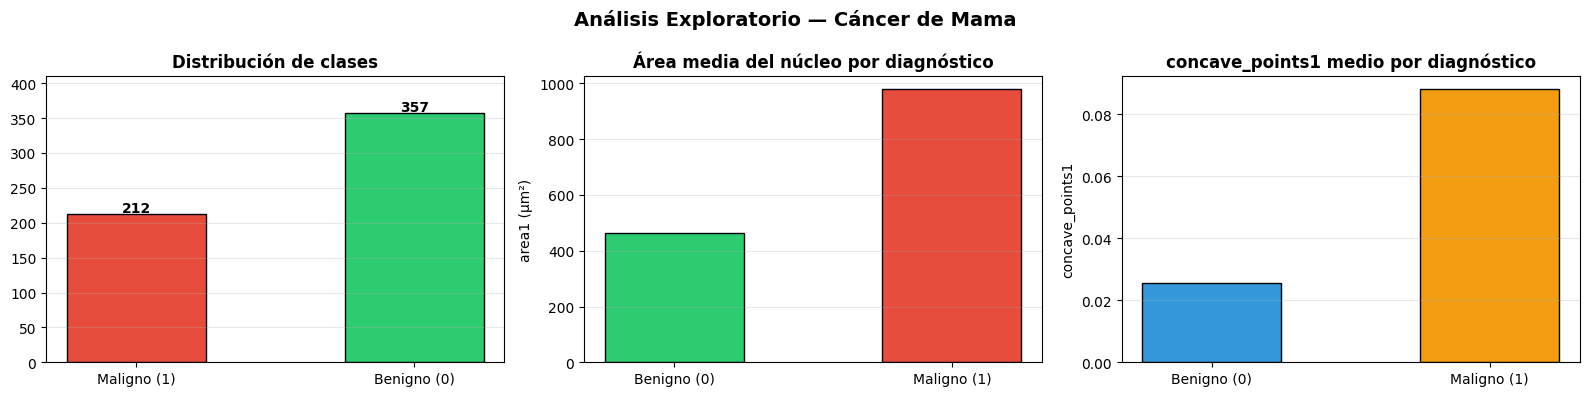

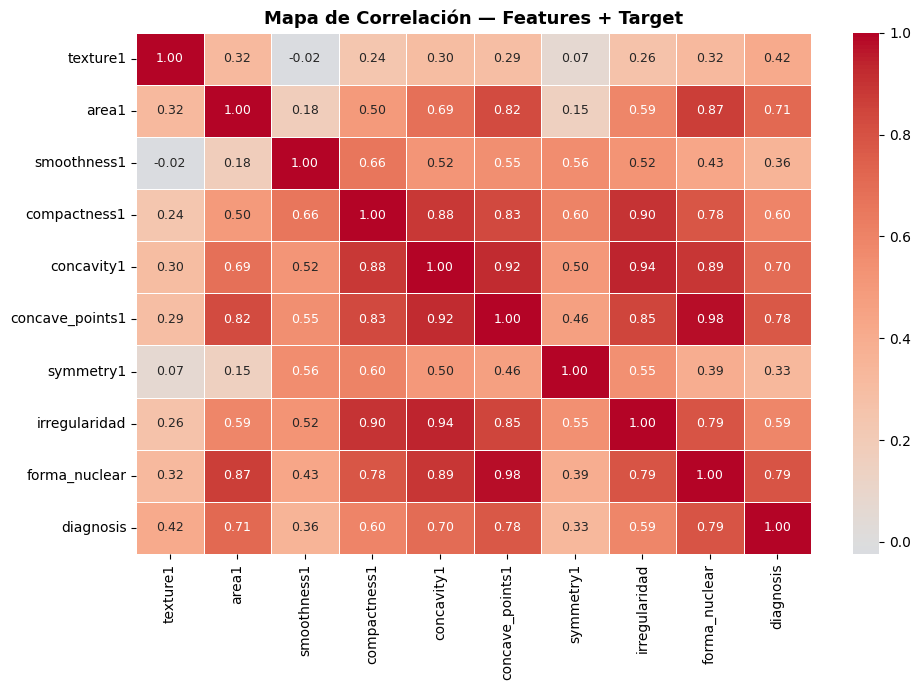

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribución de clases
counts = [y.sum(), (1-y).sum()]
bars = axes[0].bar(['Maligno (1)', 'Benigno (0)'], counts,
                   color=['#e74c3c','#2ecc71'], edgecolor='black', width=0.5)
axes[0].set_title('Distribución de clases', fontweight='bold')
for bar, v in zip(bars, counts):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
                 str(v), ha='center', fontweight='bold')
axes[0].set_ylim(0, max(counts)*1.15)
axes[0].grid(axis='y', alpha=0.3)

# Área media por diagnóstico
area_diag = df.groupby('diagnosis')['area1'].mean()
axes[1].bar(['Benigno (0)', 'Maligno (1)'], area_diag.values,
            color=['#2ecc71','#e74c3c'], edgecolor='black', width=0.5)
axes[1].set_title('Área media del núcleo por diagnóstico', fontweight='bold')
axes[1].set_ylabel('area1 (µm²)')
axes[1].grid(axis='y', alpha=0.3)

# concave_points1 medio por diagnóstico (mejor predictor individual)
cp_diag = df.groupby('diagnosis')['concave_points1'].mean()
axes[2].bar(['Benigno (0)', 'Maligno (1)'], cp_diag.values,
            color=['#3498db','#f39c12'], edgecolor='black', width=0.5)
axes[2].set_title('concave_points1 medio por diagnóstico', fontweight='bold')
axes[2].set_ylabel('concave_points1')
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Análisis Exploratorio — Cáncer de Mama', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_eda_cancer_s3.png', bbox_inches='tight')
plt.show()

# Correlación
plt.figure(figsize=(10, 7))
corr = pd.DataFrame(X, columns=FEATURES)
corr['diagnosis'] = y
sns.heatmap(corr.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, annot_kws={'size': 9})
plt.title('Mapa de Correlación — Features + Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_correlacion_s3.png', bbox_inches='tight')
plt.show()


## Interpretación

El dataset presenta un desbalance moderado: 37.3% de casos malignos (212) frente a 62.7% benignos (357). No es un desbalance severo. Por otro lado, en el mapa de correlación se visualiza que los tumores malignos tienen, en promedio, mayor área nuclear y mayor concave_points1 que los benignos, lo cual es consistente con la biología del cáncer (núcleos más grandes e irregulares en tejido maligno). El mapa de correlación confirma la lógica detrás de la ingeniería de variables de la celda 3: concavity1 y concave_points1 están correlacionadas entre sí y con el target, lo que motiva combinarlas en irregularidad y forma_nuclear para reducir redundancia sin perder señal.

---
## PCA — Reducción de Dimensiones

**PCA** transforma las 9 características morfológicas en componentes ortogonales ordenados por varianza.

**Motivación:** Varias características están correlacionadas entre sí (ej. `concavity1` ↔ `irregularidad`, `concave_points1` ↔ `forma_nuclear`). PCA elimina esa redundancia y permite:
- Visualizar la separabilidad de clases (maligno vs benigno) en 2D
- Comparar si los clasificadores mejoran o empeoran con espacio reducido

**Buena práctica:** PCA se ajusta **solo** con X_train → se transforma X_test con el mismo objeto.


Componentes necesarios por umbral de varianza acumulada:
  70%: 2 componentes
  80%: 3 componentes
  90%: 4 componentes
  95%: 5 componentes

PC1: 64.73%  |  PC2: 15.11%  |  PC1+PC2: 79.84%


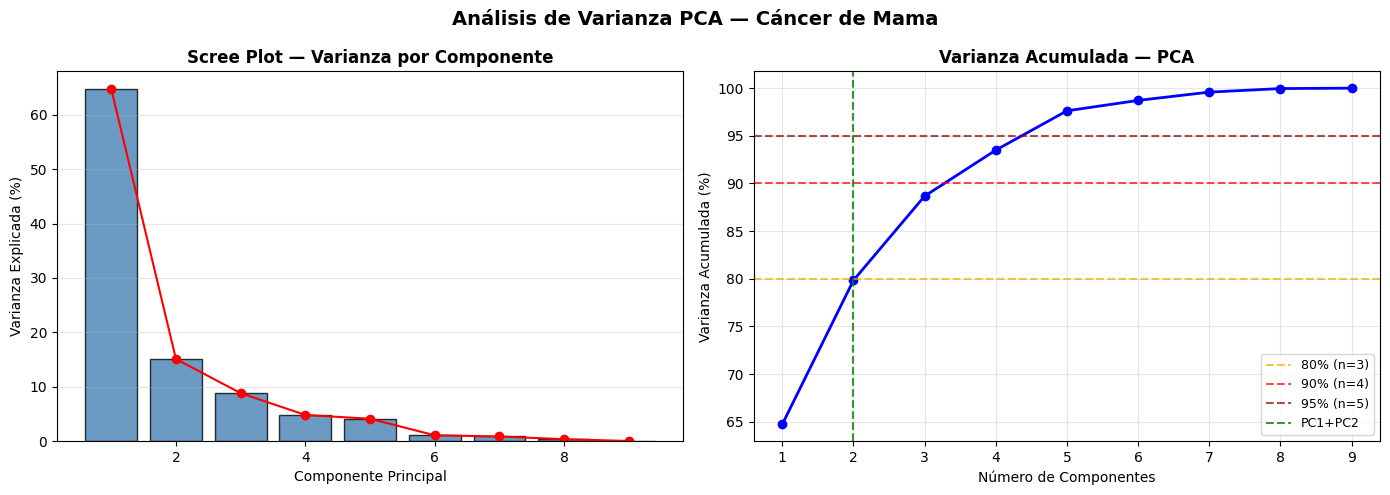

In [5]:
# Escalar globalmente para análisis de varianza
scaler_global = StandardScaler()
X_scaled_all = scaler_global.fit_transform(X)

pca_full = PCA(n_components=X.shape[1])
pca_full.fit(X_scaled_all)
var_exp = pca_full.explained_variance_ratio_
var_cum = np.cumsum(var_exp)

print('Componentes necesarios por umbral de varianza acumulada:')
for u in [0.70, 0.80, 0.90, 0.95]:
    n = np.argmax(var_cum >= u) + 1
    print(f'  {int(u*100)}%: {n} componentes')
print(f'\nPC1: {var_exp[0]*100:.2f}%  |  PC2: {var_exp[1]*100:.2f}%  |  PC1+PC2: {var_cum[1]*100:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(var_exp)+1), var_exp*100, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].plot(range(1, len(var_exp)+1), var_exp*100, 'ro-', markersize=6)
axes[0].set_title('Scree Plot — Varianza por Componente', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Varianza Explicada (%)')
axes[0].grid(axis='y', alpha=0.3)

axes[1].plot(range(1, len(var_cum)+1), var_cum*100, 'bo-', markersize=6, linewidth=2)
for p, c in [(0.80,'orange'), (0.90,'red'), (0.95,'darkred')]:
    n = np.argmax(var_cum >= p) + 1
    axes[1].axhline(y=p*100, color=c, linestyle='--', alpha=0.7, label=f'{int(p*100)}% (n={n})')
axes[1].axvline(x=2, color='green', linestyle='--', alpha=0.8, label='PC1+PC2')
axes[1].set_title('Varianza Acumulada — PCA', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Varianza Acumulada (%)')
axes[1].legend(loc='lower right', fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Análisis de Varianza PCA — Cáncer de Mama', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_pca_varianza_s3.png', bbox_inches='tight')
plt.show()


## Interpretación

Se puede notar que con solo 2 componentes se retiene el 79.84% de la varianza (PC1=64.73%, PC2=15.11%), y se necesitan apenas 3 componentes para superar el 80%. Esto es señal de alta multicolinealidad entre las 9 variables morfológicas (ya detectada en la Semana 2), y anticipa por qué —a diferencia de Titanic— reducir a 2 dimensiones aquí va a perder relativamente poca información predictiva.

In [ ]:
pca_viz = PCA(n_components=2, random_state=101699)
X_pca_viz = pca_viz.fit_transform(X_scaled_all)

plt.figure(figsize=(9, 6))
scatter = plt.scatter(X_pca_viz[:, 0], X_pca_viz[:, 1],
                      c=y, cmap='coolwarm', alpha=0.7, edgecolors='k', linewidth=0.3, s=50)
plt.xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]*100:.1f}% varianza)', fontsize=12)
plt.ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]*100:.1f}% varianza)', fontsize=12)
plt.title('Proyección PCA 2D — Cáncer de Mama (maligno vs benigno)', fontsize=14, fontweight='bold')
plt.legend(handles=scatter.legend_elements()[0],
           labels=['Benigno (0)', 'Maligno (1)'], fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_pca_2d_s3.png', bbox_inches='tight')
plt.show()
print('Los grupos se separan razonablemente bien en PCA 2D, aunque persiste una zona de solapamiento.')


In [6]:
SEED = 101699

# Split 80/20 estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# StandardScaler (NB, KNN, LR, DT, RF, SVM) — ajustado solo en train
sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc  = sc.transform(X_test)

# PCA 2 componentes — ajustado solo en train_sc
pca = PCA(n_components=2, random_state=SEED)
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca  = pca.transform(X_test_sc)

# MinMaxScaler para RNA — ajustado solo en train
sc_rna = MinMaxScaler()
X_train_rna = sc_rna.fit_transform(X_train)
X_test_rna  = sc_rna.transform(X_test)

# MinMaxScaler sobre features PCA para RNA+PCA
sc_rna_pca = MinMaxScaler()
X_train_rna_pca = sc_rna_pca.fit_transform(X_train_pca)
X_test_rna_pca  = sc_rna_pca.transform(X_test_pca)

print(f'X_train (sin PCA): {X_train_sc.shape}    X_test: {X_test_sc.shape}')
print(f'X_train (con PCA): {X_train_pca.shape}    X_test: {X_test_pca.shape}')
print(f'Train Malignos: {y_train.sum()} ({100*y_train.mean():.1f}%)  |  Test: {y_test.sum()} ({100*y_test.mean():.1f}%)')


X_train (sin PCA): (455, 9)    X_test: (114, 9)
X_train (con PCA): (455, 2)    X_test: (114, 2)
Train Malignos: 170 (37.4%)  |  Test: 42 (36.8%)


In [7]:
def evaluar(nombre, modelo, X_tr, X_te, y_tr, y_te, cv=5):
    modelo.fit(X_tr, y_tr)
    y_pred = modelo.predict(X_te)
    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    if hasattr(modelo, 'predict_proba'):
        y_prob = modelo.predict_proba(X_te)[:, 1]
    else:
        y_prob = modelo.decision_function(X_te)
        y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min() + 1e-10)
    auc = roc_auc_score(y_te, y_prob)
    cv_s = cross_val_score(modelo, X_tr, y_tr, cv=cv, scoring='accuracy')
    print(f"\n{'='*52}")
    print(f' {nombre}')
    print(f"{'='*52}")
    print(f'  CV Accuracy (5-fold): {cv_s.mean()*100:.2f}% ± {cv_s.std()*100:.2f}%')
    print(f'  Test Accuracy       : {acc*100:.2f}%')
    print(f'  Precision           : {prec*100:.2f}%')
    print(f'  Recall              : {rec*100:.2f}%')
    print(f'  F1-Score            : {f1*100:.2f}%')
    print(f'  AUC-ROC             : {auc*100:.2f}%')
    return {'Modelo':nombre,'CV Acc%':round(cv_s.mean()*100,2),
            'Test Acc%':round(acc*100,2),'Prec%':round(prec*100,2),
            'Recall%':round(rec*100,2),'F1%':round(f1*100,2),'AUC%':round(auc*100,2)}

res = []  # acumula resultados Fase I
print('Función evaluar() definida.')


Función evaluar() definida.


---
## Fase I — Clasificación Supervisada con y sin PCA

Se comparan **7 algoritmos** en dos condiciones:
- **Sin PCA:** 9 features escaladas con StandardScaler (o MinMaxScaler para RNA)
- **Con PCA:** 2 componentes principales derivados de esas 9 features

| # | Algoritmo | Abrev. |
|---|-----------|--------|
| 1 | Naive Bayes | NB |
| 2 | K-Nearest Neighbors | KNN |
| 3 | Regresión Logística | LR |
| 4 | Árbol de Decisión | DT |
| 5 | Bosque Aleatorio | RF |
| 6 | Máquina de Vectores de Soporte | SVM |
| 7 | Red Neuronal Artificial | RNA |


In [8]:
nb_base = GaussianNB()
r = evaluar('NB — Sin PCA', nb_base, X_train_sc, X_test_sc, y_train, y_test)
res.append(r)



 NB — Sin PCA
  CV Accuracy (5-fold): 92.31% ± 1.97%
  Test Accuracy       : 92.98%
  Precision           : 90.48%
  Recall              : 90.48%
  F1-Score            : 90.48%
  AUC-ROC             : 98.08%


In [9]:
nb_pca = GaussianNB()
r = evaluar('NB — Con PCA', nb_pca, X_train_pca, X_test_pca, y_train, y_test)
res.append(r)



 NB — Con PCA
  CV Accuracy (5-fold): 90.33% ± 2.54%
  Test Accuracy       : 91.23%
  Precision           : 92.11%
  Recall              : 83.33%
  F1-Score            : 87.50%
  AUC-ROC             : 98.31%


In [10]:
knn_base = KNeighborsClassifier(n_neighbors=5, p=2)
r = evaluar('KNN — Sin PCA', knn_base, X_train_sc, X_test_sc, y_train, y_test)
res.append(r)



 KNN — Sin PCA
  CV Accuracy (5-fold): 94.29% ± 1.76%
  Test Accuracy       : 93.86%
  Precision           : 85.71%
  Recall              : 100.00%
  F1-Score            : 92.31%
  AUC-ROC             : 99.36%


In [11]:
knn_pca = KNeighborsClassifier(n_neighbors=5, p=2)
r = evaluar('KNN — Con PCA', knn_pca, X_train_pca, X_test_pca, y_train, y_test)
res.append(r)



 KNN — Con PCA
  CV Accuracy (5-fold): 91.87% ± 2.04%
  Test Accuracy       : 91.23%
  Precision           : 84.78%
  Recall              : 92.86%
  F1-Score            : 88.64%
  AUC-ROC             : 96.33%


In [12]:
lr_base = LogisticRegression(max_iter=1000, random_state=SEED)
r = evaluar('LR — Sin PCA', lr_base, X_train_sc, X_test_sc, y_train, y_test)
res.append(r)



 LR — Sin PCA
  CV Accuracy (5-fold): 92.75% ± 2.66%
  Test Accuracy       : 96.49%
  Precision           : 93.18%
  Recall              : 97.62%
  F1-Score            : 95.35%
  AUC-ROC             : 99.64%


In [13]:
lr_pca = LogisticRegression(max_iter=1000, random_state=SEED)
r = evaluar('LR — Con PCA', lr_pca, X_train_pca, X_test_pca, y_train, y_test)
res.append(r)



 LR — Con PCA
  CV Accuracy (5-fold): 92.31% ± 2.78%
  Test Accuracy       : 94.74%
  Precision           : 90.91%
  Recall              : 95.24%
  F1-Score            : 93.02%
  AUC-ROC             : 99.04%


In [14]:
dt_base = DecisionTreeClassifier(max_depth=4, criterion='gini', random_state=SEED)
r = evaluar('DT — Sin PCA', dt_base, X_train_sc, X_test_sc, y_train, y_test)
res.append(r)



 DT — Sin PCA
  CV Accuracy (5-fold): 90.11% ± 3.93%
  Test Accuracy       : 89.47%
  Precision           : 84.09%
  Recall              : 88.10%
  F1-Score            : 86.05%
  AUC-ROC             : 92.94%


In [15]:
dt_pca = DecisionTreeClassifier(max_depth=4, criterion='gini', random_state=SEED)
r = evaluar('DT — Con PCA', dt_pca, X_train_pca, X_test_pca, y_train, y_test)
res.append(r)



 DT — Con PCA
  CV Accuracy (5-fold): 88.57% ± 2.92%
  Test Accuracy       : 92.11%
  Precision           : 92.31%
  Recall              : 85.71%
  F1-Score            : 88.89%
  AUC-ROC             : 96.61%


In [16]:
rf_base = RandomForestClassifier(n_estimators=100, max_depth=6, criterion='entropy', random_state=SEED)
r = evaluar('RF — Sin PCA', rf_base, X_train_sc, X_test_sc, y_train, y_test)
res.append(r)



 RF — Sin PCA
  CV Accuracy (5-fold): 92.97% ± 1.32%
  Test Accuracy       : 93.86%
  Precision           : 88.89%
  Recall              : 95.24%
  F1-Score            : 91.95%
  AUC-ROC             : 98.74%


In [17]:
rf_pca = RandomForestClassifier(n_estimators=100, max_depth=6, criterion='entropy', random_state=SEED)
r = evaluar('RF — Con PCA', rf_pca, X_train_pca, X_test_pca, y_train, y_test)
res.append(r)



 RF — Con PCA
  CV Accuracy (5-fold): 90.99% ± 2.73%
  Test Accuracy       : 92.11%
  Precision           : 86.67%
  Recall              : 92.86%
  F1-Score            : 89.66%
  AUC-ROC             : 98.64%


In [18]:
svm_base = SVC(kernel='linear', C=1.0, gamma='scale', probability=True, random_state=SEED)
r = evaluar('SVM — Sin PCA', svm_base, X_train_sc, X_test_sc, y_train, y_test)
res.append(r)



 SVM — Sin PCA
  CV Accuracy (5-fold): 91.65% ± 2.75%
  Test Accuracy       : 96.49%
  Precision           : 95.24%
  Recall              : 95.24%
  F1-Score            : 95.24%
  AUC-ROC             : 99.34%


In [19]:
svm_pca = SVC(kernel='linear', C=1.0, gamma='scale', probability=True, random_state=SEED)
r = evaluar('SVM — Con PCA', svm_pca, X_train_pca, X_test_pca, y_train, y_test)
res.append(r)



 SVM — Con PCA
  CV Accuracy (5-fold): 92.53% ± 2.81%
  Test Accuracy       : 94.74%
  Precision           : 90.91%
  Recall              : 95.24%
  F1-Score            : 93.02%
  AUC-ROC             : 99.11%


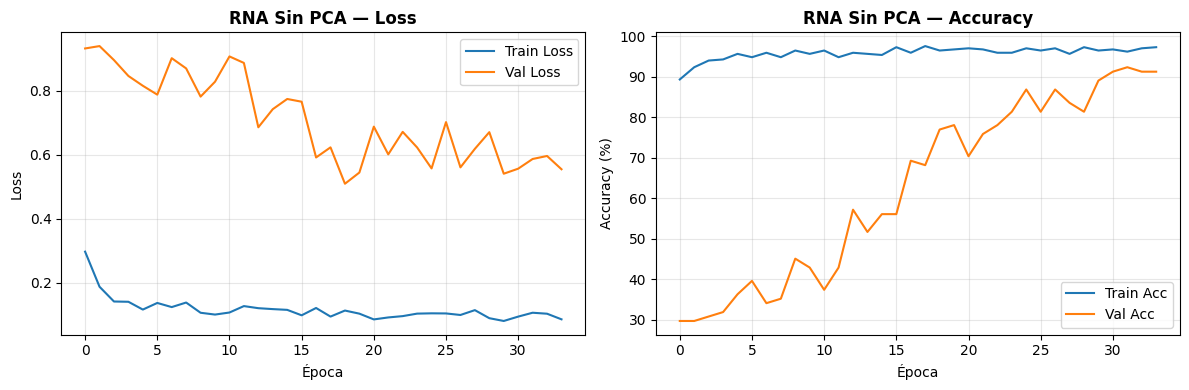


===== RNA — Sin PCA =====
  Test Accuracy: 83.33%
  Precision    : 68.85%
  Recall       : 100.00%
  F1-Score     : 81.55%
  AUC-ROC      : 99.70%
  Épocas ejecutadas: 34


In [20]:
tf.random.set_seed(SEED)
np.random.seed(SEED)

rna_base = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_rna.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])
rna_base.compile(optimizer=Adam(learning_rate=1e-2),
                 loss='binary_crossentropy', metrics=['accuracy'])

cb = [EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
      ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, verbose=0)]

hist_base = rna_base.fit(X_train_rna, y_train, epochs=150, batch_size=32,
                         validation_split=0.2, callbacks=cb, verbose=0)

plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(hist_base.history['loss'], label='Train Loss')
plt.plot(hist_base.history['val_loss'], label='Val Loss')
plt.title('RNA Sin PCA — Loss', fontweight='bold')
plt.xlabel('Época'); plt.ylabel('Loss'); plt.legend(); plt.grid(alpha=0.3)
plt.subplot(1,2,2)
plt.plot([a*100 for a in hist_base.history['accuracy']], label='Train Acc')
plt.plot([a*100 for a in hist_base.history['val_accuracy']], label='Val Acc')
plt.title('RNA Sin PCA — Accuracy', fontweight='bold')
plt.xlabel('Época'); plt.ylabel('Accuracy (%)'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('fig_rna_sin_pca_s3.png', bbox_inches='tight'); plt.show()

y_prob_rna = rna_base.predict(X_test_rna, verbose=0).ravel()
y_pred_rna = (y_prob_rna >= 0.5).astype(int)
acc  = accuracy_score(y_test, y_pred_rna)
prec = precision_score(y_test, y_pred_rna, zero_division=0)
rec  = recall_score(y_test, y_pred_rna, zero_division=0)
f1   = f1_score(y_test, y_pred_rna, zero_division=0)
auc  = roc_auc_score(y_test, y_prob_rna)
print(f'\n===== RNA — Sin PCA =====')
print(f'  Test Accuracy: {acc*100:.2f}%')
print(f'  Precision    : {prec*100:.2f}%')
print(f'  Recall       : {rec*100:.2f}%')
print(f'  F1-Score     : {f1*100:.2f}%')
print(f'  AUC-ROC      : {auc*100:.2f}%')
print(f'  Épocas ejecutadas: {len(hist_base.history["loss"])}')
res.append({'Modelo':'RNA — Sin PCA','CV Acc%': round(acc*100,2),
            'Test Acc%':round(acc*100,2),'Prec%':round(prec*100,2),
            'Recall%':round(rec*100,2),'F1%':round(f1*100,2),'AUC%':round(auc*100,2)})


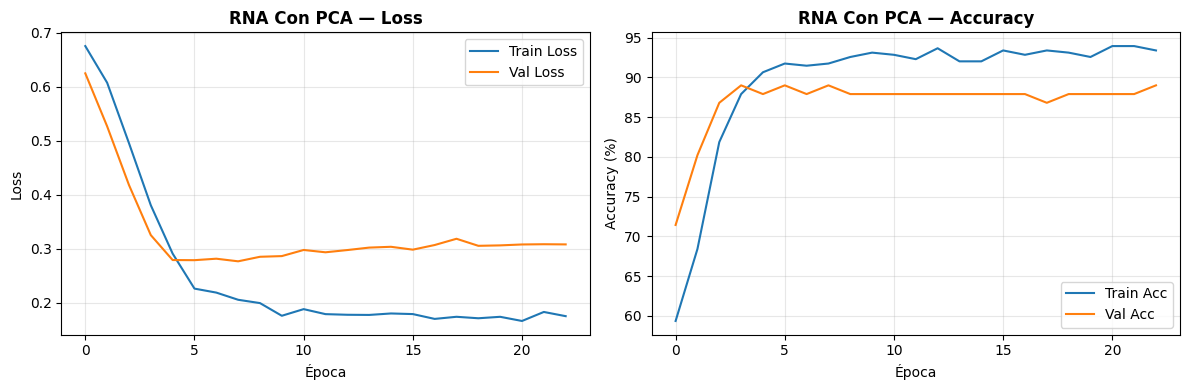


===== RNA — Con PCA =====
  Test Accuracy: 96.49%
  Precision    : 91.30%
  Recall       : 100.00%
  F1-Score     : 95.45%
  AUC-ROC      : 99.07%
  Épocas ejecutadas: 23


In [21]:
tf.random.set_seed(SEED)
np.random.seed(SEED)

rna_pca = Sequential([
    Dense(16, activation='relu', input_shape=(X_train_rna_pca.shape[1],)),
    Dropout(0.2),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])
rna_pca.compile(optimizer=Adam(learning_rate=1e-2),
                loss='binary_crossentropy', metrics=['accuracy'])

cb2 = [EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
       ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, verbose=0)]

hist_pca = rna_pca.fit(X_train_rna_pca, y_train, epochs=150, batch_size=32,
                        validation_split=0.2, callbacks=cb2, verbose=0)

plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(hist_pca.history['loss'], label='Train Loss')
plt.plot(hist_pca.history['val_loss'], label='Val Loss')
plt.title('RNA Con PCA — Loss', fontweight='bold')
plt.xlabel('Época'); plt.ylabel('Loss'); plt.legend(); plt.grid(alpha=0.3)
plt.subplot(1,2,2)
plt.plot([a*100 for a in hist_pca.history['accuracy']], label='Train Acc')
plt.plot([a*100 for a in hist_pca.history['val_accuracy']], label='Val Acc')
plt.title('RNA Con PCA — Accuracy', fontweight='bold')
plt.xlabel('Época'); plt.ylabel('Accuracy (%)'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('fig_rna_con_pca_s3.png', bbox_inches='tight'); plt.show()

y_prob_rna_pca = rna_pca.predict(X_test_rna_pca, verbose=0).ravel()
y_pred_rna_pca = (y_prob_rna_pca >= 0.5).astype(int)
acc2  = accuracy_score(y_test, y_pred_rna_pca)
prec2 = precision_score(y_test, y_pred_rna_pca, zero_division=0)
rec2  = recall_score(y_test, y_pred_rna_pca, zero_division=0)
f12   = f1_score(y_test, y_pred_rna_pca, zero_division=0)
auc2  = roc_auc_score(y_test, y_prob_rna_pca)
print(f'\n===== RNA — Con PCA =====')
print(f'  Test Accuracy: {acc2*100:.2f}%')
print(f'  Precision    : {prec2*100:.2f}%')
print(f'  Recall       : {rec2*100:.2f}%')
print(f'  F1-Score     : {f12*100:.2f}%')
print(f'  AUC-ROC      : {auc2*100:.2f}%')
print(f'  Épocas ejecutadas: {len(hist_pca.history["loss"])}')
res.append({'Modelo':'RNA — Con PCA','CV Acc%':round(acc2*100,2),
            'Test Acc%':round(acc2*100,2),'Prec%':round(prec2*100,2),
            'Recall%':round(rec2*100,2),'F1%':round(f12*100,2),'AUC%':round(auc2*100,2)})


In [22]:
df_f1 = pd.DataFrame(res)
df_f1.insert(1, 'PCA', ['Sin PCA','Con PCA']*7)

print('\nTabla comparativa Fase I — 7 algoritmos con y sin PCA')
print('='*80)
print(df_f1[['Modelo','PCA','CV Acc%','Test Acc%','Prec%','Recall%','F1%','AUC%']].to_string(index=False))
print('='*80)
print(f'\nMejor Test Accuracy: {df_f1.loc[df_f1["Test Acc%"].idxmax(),"Modelo"]}  ({df_f1["Test Acc%"].max():.2f}%)')
print(f'Mejor AUC-ROC      : {df_f1.loc[df_f1["AUC%"].idxmax(),"Modelo"]}  ({df_f1["AUC%"].max():.2f}%)')
print(f'Mejor F1-Score     : {df_f1.loc[df_f1["F1%"].idxmax(),"Modelo"]}  ({df_f1["F1%"].max():.2f}%)')



Tabla comparativa Fase I — 7 algoritmos con y sin PCA
       Modelo     PCA  CV Acc%  Test Acc%  Prec%  Recall%   F1%  AUC%
 NB — Sin PCA Sin PCA    92.31      92.98  90.48    90.48 90.48 98.08
 NB — Con PCA Con PCA    90.33      91.23  92.11    83.33 87.50 98.31
KNN — Sin PCA Sin PCA    94.29      93.86  85.71   100.00 92.31 99.36
KNN — Con PCA Con PCA    91.87      91.23  84.78    92.86 88.64 96.33
 LR — Sin PCA Sin PCA    92.75      96.49  93.18    97.62 95.35 99.64
 LR — Con PCA Con PCA    92.31      94.74  90.91    95.24 93.02 99.04
 DT — Sin PCA Sin PCA    90.11      89.47  84.09    88.10 86.05 92.94
 DT — Con PCA Con PCA    88.57      92.11  92.31    85.71 88.89 96.61
 RF — Sin PCA Sin PCA    92.97      93.86  88.89    95.24 91.95 98.74
 RF — Con PCA Con PCA    90.99      92.11  86.67    92.86 89.66 98.64
SVM — Sin PCA Sin PCA    91.65      96.49  95.24    95.24 95.24 99.34
SVM — Con PCA Con PCA    92.53      94.74  90.91    95.24 93.02 99.11
RNA — Sin PCA Sin PCA    83.33     

## Interpretación

Los tres modelos con mejor desempeño (LR y SVM sin PCA, y RNA con PCA) superan 95% de Accuracy, lo que indica que el problema es casi linealmente separable en el espacio de 9 variables. Por otro lado, el RNA sin PCA es el modelo más débil con un Accuracy de 83.33%.

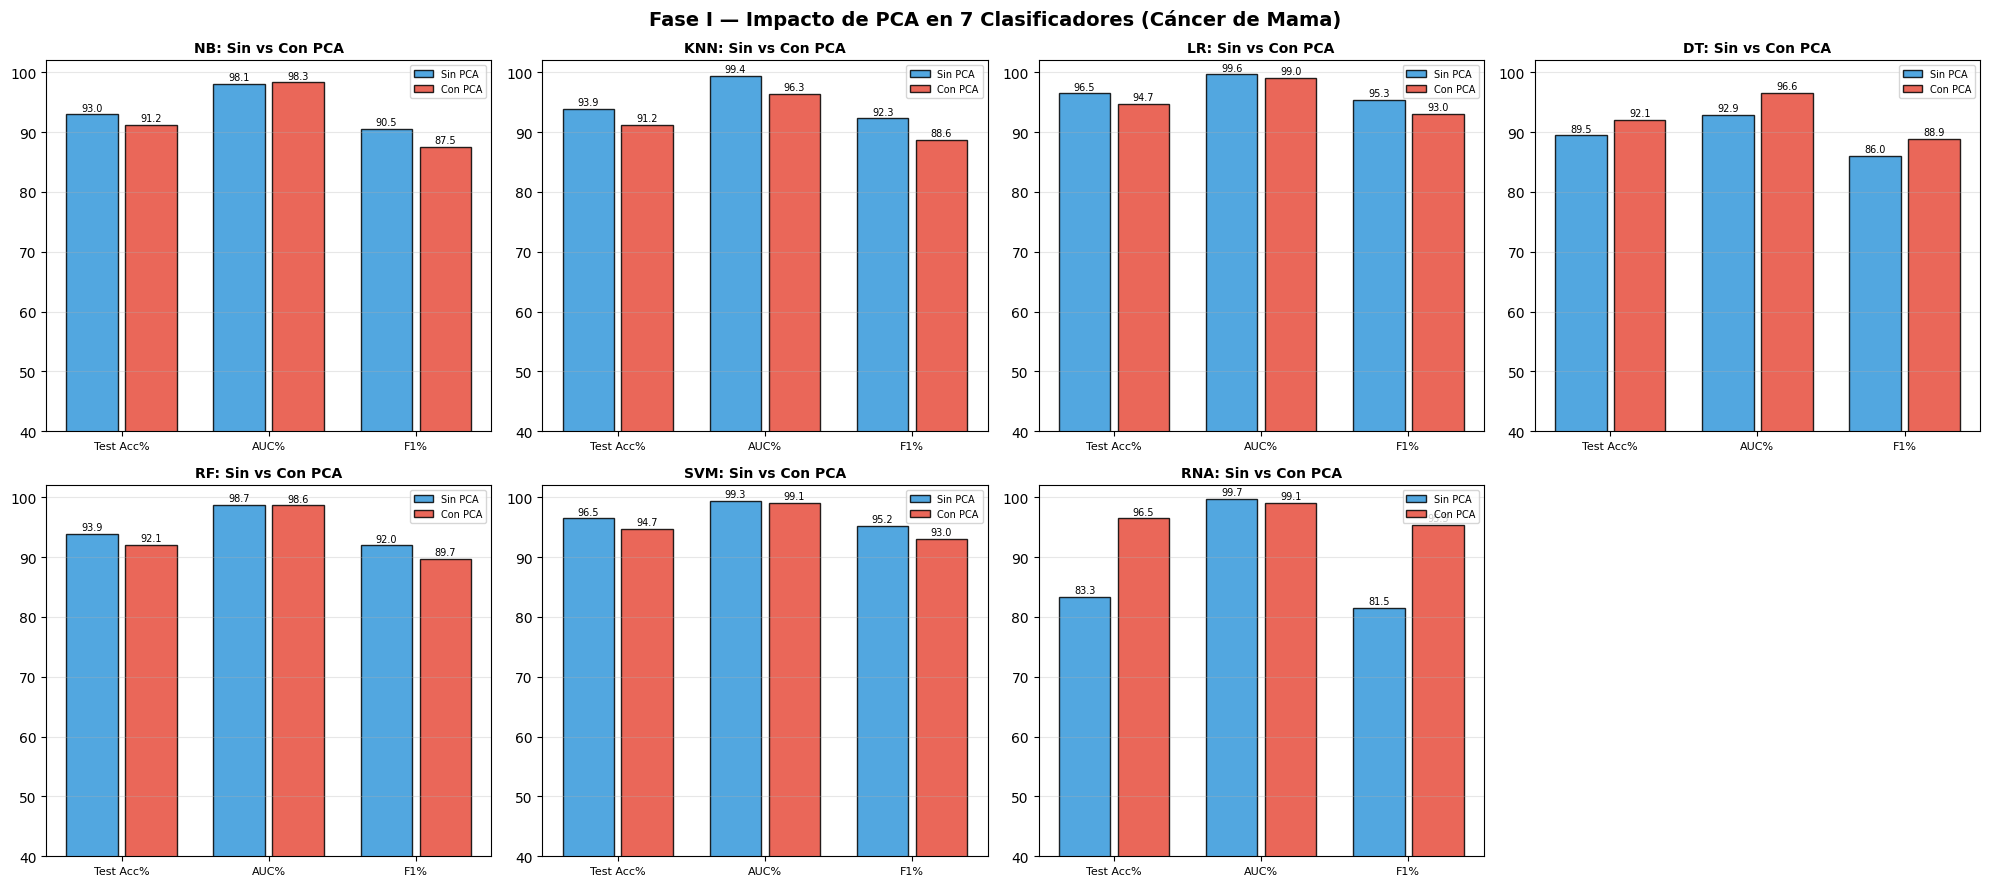

In [23]:
algoritmos = ['NB', 'KNN', 'LR', 'DT', 'RF', 'SVM', 'RNA']
metricas_plot = ['Test Acc%', 'AUC%', 'F1%']

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for idx, (algo, ax) in enumerate(zip(algoritmos, axes)):
    sub = df_f1[df_f1['Modelo'].str.startswith(algo)]
    sin_pca = sub[sub['PCA']=='Sin PCA'][metricas_plot].values
    con_pca = sub[sub['PCA']=='Con PCA'][metricas_plot].values
    if len(sin_pca)==0 or len(con_pca)==0:
        ax.set_visible(False); continue
    sin_pca = sin_pca[0]; con_pca = con_pca[0]
    x = np.arange(len(metricas_plot))
    b1 = ax.bar(x-0.2, sin_pca, 0.35, label='Sin PCA', color='#3498db', edgecolor='black', alpha=0.85)
    b2 = ax.bar(x+0.2, con_pca, 0.35, label='Con PCA', color='#e74c3c', edgecolor='black', alpha=0.85)
    for bar in b1:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=7)
    for bar in b2:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=7)
    ax.set_title(f'{algo}: Sin vs Con PCA', fontsize=10, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(metricas_plot, fontsize=8)
    ax.set_ylim(40, 102); ax.legend(fontsize=7); ax.grid(axis='y', alpha=0.3)

axes[-1].set_visible(False)
plt.suptitle('Fase I — Impacto de PCA en 7 Clasificadores (Cáncer de Mama)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_comparativa_fase1_s3.png', bbox_inches='tight')
plt.show()


In [24]:
joblib.dump(rf_base,  'rf_cancer_sin_pca.pkl')
joblib.dump(svm_base, 'svm_cancer_sin_pca.pkl')
joblib.dump(sc,       'scaler_std_f1.pkl')
joblib.dump(pca,      'pca_2comp_f1.pkl')
rna_base.save('rna_cancer_sin_pca.h5')

print('Modelos Fase I guardados:')
print('  rf_cancer_sin_pca.pkl   | svm_cancer_sin_pca.pkl')
print('  scaler_std_f1.pkl       | pca_2comp_f1.pkl')
print('  rna_cancer_sin_pca.h5')


Modelos Fase I guardados:
  rf_cancer_sin_pca.pkl   | svm_cancer_sin_pca.pkl
  scaler_std_f1.pkl       | pca_2comp_f1.pkl
  rna_cancer_sin_pca.h5


## Interpretación

La caída de desempeño con PCA es pequeña y homogénea entre modelos (entre -0.88 y -2.63 pp), y el Árbol de Decisión es la única excepción que mejora, mientras que en RNA el aplicar PCA si mejora el rendimiento del modelo en el Accuracy de la data de prueba.

---
## Fase II — Agrupamiento No Supervisado: K-Means y GMM

Los algoritmos de clustering se aplican **sin usar las etiquetas** (`diagnosis`). Con K=2, los grupos esperados corresponden a benigno/maligno; con K=3 se exploran subgrupos naturales dentro de esas categorías (por ejemplo, tumores malignos de distinto grado de agresividad morfológica).

### Métricas de evaluación interna

| Métrica | Ideal | Escala |
|---------|-------|--------|
| Inercia | ↓ Más baja | ≥ 0 |
| Silhouette Score | ↑ Más alta | -1 a 1 |
| Calinski-Harabasz | ↑ Más alta | ≥ 0 |
| Davies-Bouldin | ↓ Más baja | ≥ 0 |

### Plan
1. Método del codo (K=1..10) para justificar K=2
2. K-Means K=2 → métricas + visualización
3. K-Means K=3 → métricas + visualización
4. GMM K=2 → métricas + visualización
5. GMM K=3 → métricas + visualización
6. Comparativa: K-Means K=2 vs K=3 | GMM K=2 vs K=3
7. Mejor K-Means vs Mejor GMM


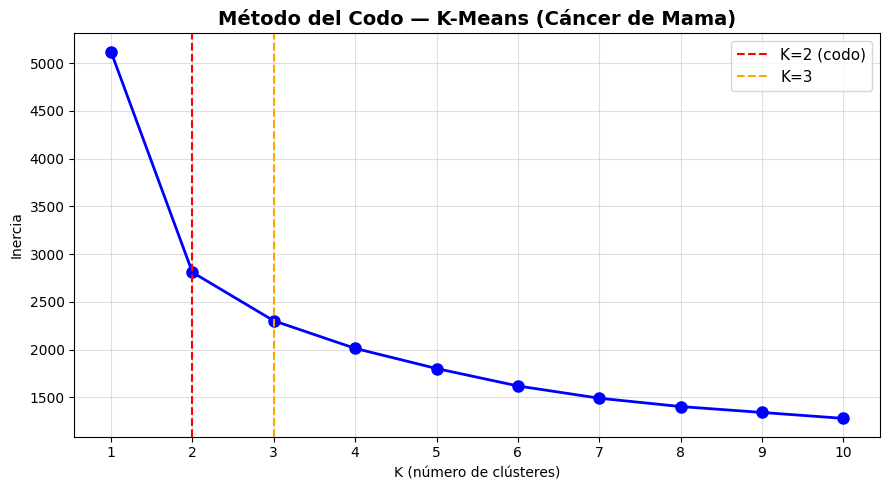

Inercias:
  K=1: 5121.0
  K=2: 2810.1
  K=3: 2302.8
  K=4: 2013.7
  K=5: 1802.8
  K=6: 1620.2
  K=7: 1491.9
  K=8: 1404.6
  K=9: 1342.8
  K=10: 1280.6


In [25]:
sc_clust = StandardScaler()
X_sc_all = sc_clust.fit_transform(X)

pca_c = PCA(n_components=2, random_state=SEED)
X_pca_c = pca_c.fit_transform(X_sc_all)

inercias_c = []
k_rng = range(1, 11)
for k in k_rng:
    km = KMeans(n_clusters=k, init='k-means++', random_state=SEED, n_init=10)
    km.fit(X_sc_all)
    inercias_c.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(k_rng, inercias_c, 'bo-', markersize=8, linewidth=2)
plt.axvline(x=2, color='red', linestyle='--', linewidth=1.5, label='K=2 (codo)')
plt.axvline(x=3, color='orange', linestyle='--', linewidth=1.5, label='K=3')
plt.title('Método del Codo — K-Means (Cáncer de Mama)', fontsize=14, fontweight='bold')
plt.xlabel('K (número de clústeres)'); plt.ylabel('Inercia')
plt.xticks(k_rng); plt.grid(True, alpha=0.4); plt.legend(fontsize=11)
plt.tight_layout(); plt.savefig('fig_codo_s3.png', bbox_inches='tight'); plt.show()

res_clust = []
print('Inercias:')
for k, ine in zip(k_rng, inercias_c):
    print(f'  K={k}: {ine:.1f}')


## Interpretación

El mayor quiebre de la curva de inercia ocurre entre K=2 y K=3, y el descenso se vuelve mucho más gradual después de K=2, lo que justifica estadísticamente elegir K=2 como número natural de grupos, coherente con la existencia de dos diagnósticos reales (benigno/maligno).

K-MEANS — K=2
  Inercia:            2810.10
  Silhouette Score:   0.4334
  Calinski-Harabasz:  466.28
  Davies-Bouldin:     0.9804
  Clúster 0: 398 muestras
  Clúster 1: 171 muestras
  Accuracy referencial: 88.58% [solo referencia]


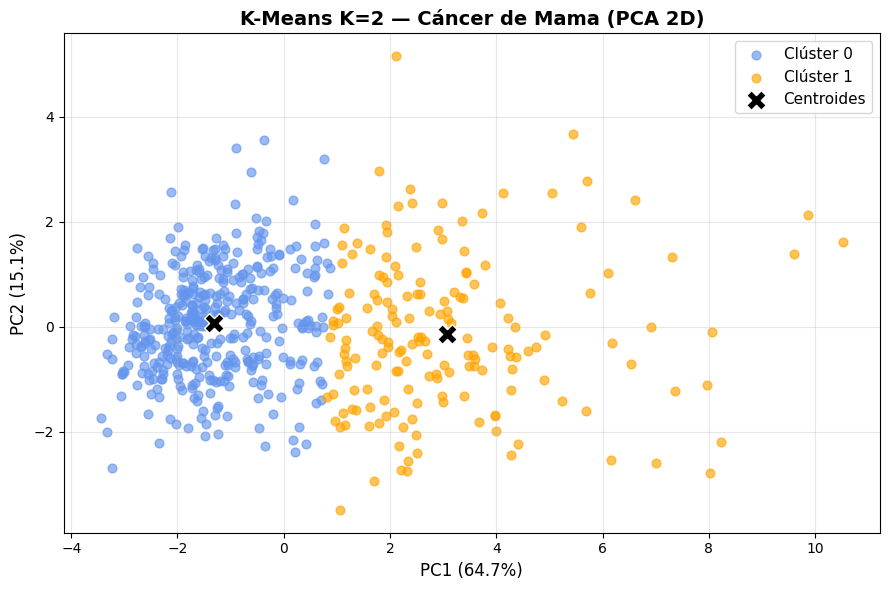

In [26]:
print('='*50); print('K-MEANS — K=2'); print('='*50)

km2 = KMeans(n_clusters=2, init='k-means++', random_state=SEED, n_init=10)
lbl_km2 = km2.fit_predict(X_sc_all)

km2_ine = km2.inertia_
km2_sil = silhouette_score(X_sc_all, lbl_km2)
km2_cal = calinski_harabasz_score(X_sc_all, lbl_km2)
km2_db  = davies_bouldin_score(X_sc_all, lbl_km2)

print(f'  Inercia:            {km2_ine:.2f}')
print(f'  Silhouette Score:   {km2_sil:.4f}')
print(f'  Calinski-Harabasz:  {km2_cal:.2f}')
print(f'  Davies-Bouldin:     {km2_db:.4f}')
for i in range(2):
    print(f'  Clúster {i}: {np.sum(lbl_km2==i)} muestras')

km2_map = np.zeros_like(lbl_km2)
for i in np.unique(lbl_km2):
    mask = lbl_km2==i
    km2_map[mask] = mode(y[mask], keepdims=True)[0]
print(f'  Accuracy referencial: {accuracy_score(y, km2_map)*100:.2f}% [solo referencia]')

cent2_pca = pca_c.transform(km2.cluster_centers_)
plt.figure(figsize=(9,6))
plt.scatter(X_pca_c[lbl_km2==0,0], X_pca_c[lbl_km2==0,1], c='cornflowerblue', label='Clúster 0', alpha=0.65, s=40)
plt.scatter(X_pca_c[lbl_km2==1,0], X_pca_c[lbl_km2==1,1], c='orange', label='Clúster 1', alpha=0.65, s=40)
plt.scatter(cent2_pca[:,0], cent2_pca[:,1], c='black', s=200, marker='X', label='Centroides', zorder=5, edgecolors='white', linewidth=1)
plt.title('K-Means K=2 — Cáncer de Mama (PCA 2D)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca_c.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'PC2 ({pca_c.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
plt.legend(fontsize=11); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.savefig('fig_kmeans_k2_s3.png', bbox_inches='tight'); plt.show()

res_clust.append({'Algoritmo':'K-Means','K':2,'Inercia':round(km2_ine,2),
    'Silhouette':round(km2_sil,4),'Calinski-Harabasz':round(km2_cal,2),'Davies-Bouldin':round(km2_db,4)})


## Interpretación

El Silhouette Score de 0.4334 es razonablemente alto para datos biológicos reales, indicando clústeres con buena cohesión interna y separación entre sí. Lo más relevante es la accuracy referencial del 88.58% frente al diagnóstico real obtenida sin usar las etiquetas durante el entrenamiento, esto demuestra que la estructura morfológica del tumor, por sí sola, casi reproduce la clasificación clínica benigno/maligno.

K-MEANS — K=3
  Inercia:            2302.76
  Silhouette Score:   0.3364
  Calinski-Harabasz:  346.35
  Davies-Bouldin:     1.2241
  Clúster 0: 57 muestras
  Clúster 1: 349 muestras
  Clúster 2: 163 muestras


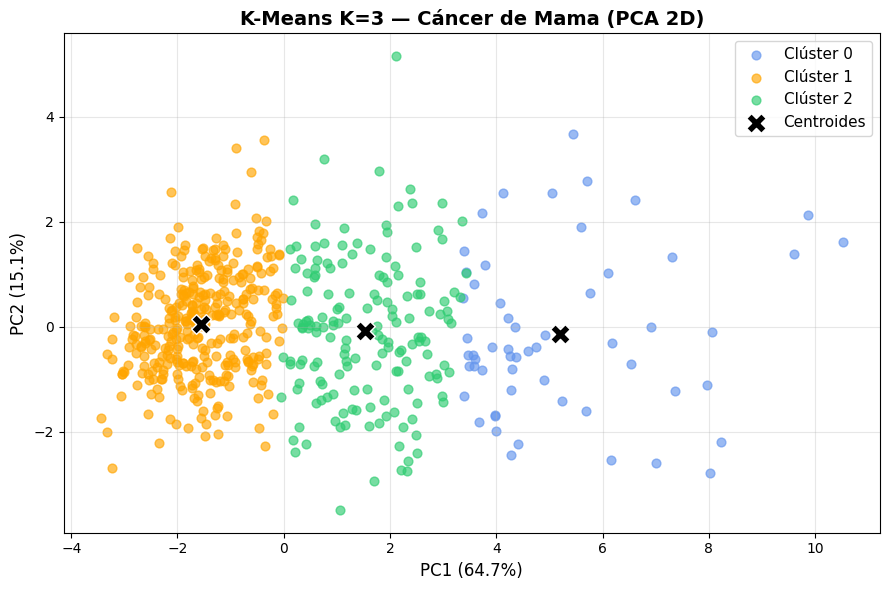

In [27]:
print('='*50); print('K-MEANS — K=3'); print('='*50)

km3 = KMeans(n_clusters=3, init='k-means++', random_state=SEED, n_init=10)
lbl_km3 = km3.fit_predict(X_sc_all)

km3_ine = km3.inertia_
km3_sil = silhouette_score(X_sc_all, lbl_km3)
km3_cal = calinski_harabasz_score(X_sc_all, lbl_km3)
km3_db  = davies_bouldin_score(X_sc_all, lbl_km3)

print(f'  Inercia:            {km3_ine:.2f}')
print(f'  Silhouette Score:   {km3_sil:.4f}')
print(f'  Calinski-Harabasz:  {km3_cal:.2f}')
print(f'  Davies-Bouldin:     {km3_db:.4f}')
for i in range(3):
    print(f'  Clúster {i}: {np.sum(lbl_km3==i)} muestras')

cent3_pca = pca_c.transform(km3.cluster_centers_)
colores3  = ['cornflowerblue', 'orange', '#2ecc71']
plt.figure(figsize=(9,6))
for i in range(3):
    plt.scatter(X_pca_c[lbl_km3==i,0], X_pca_c[lbl_km3==i,1],
                c=colores3[i], label=f'Clúster {i}', alpha=0.65, s=40)
plt.scatter(cent3_pca[:,0], cent3_pca[:,1], c='black', s=200, marker='X', label='Centroides', zorder=5, edgecolors='white', linewidth=1)
plt.title('K-Means K=3 — Cáncer de Mama (PCA 2D)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca_c.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'PC2 ({pca_c.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
plt.legend(fontsize=11); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.savefig('fig_kmeans_k3_s3.png', bbox_inches='tight'); plt.show()

res_clust.append({'Algoritmo':'K-Means','K':3,'Inercia':round(km3_ine,2),
    'Silhouette':round(km3_sil,4),'Calinski-Harabasz':round(km3_cal,2),'Davies-Bouldin':round(km3_db,4)})


## Interpretación

Todas las métricas empeoran respecto a K=2: el Silhouette cae de 0.4334 a 0.3364 y el Calinski-Harabasz de 466.28 a 346.35. Esto indica que el tercer clúster no captura un subgrupo biológico genuino, sino que fragmenta artificialmente uno de los dos grupos naturales (398 vs. 171 muestras en K=2, frente a 57/349/163 en K=3), la partición en 3 grupos añade complejidad sin aportar separación real.

GMM — K=2
  Inercia Aprox.:     2945.85
  Silhouette Score:   0.3831
  Calinski-Harabasz:  418.67
  Davies-Bouldin:     1.0542
  Clúster 0: 227 muestras
  Clúster 1: 342 muestras
  Prob. máxima promedio: 99.01%  | puntos >90%: 551


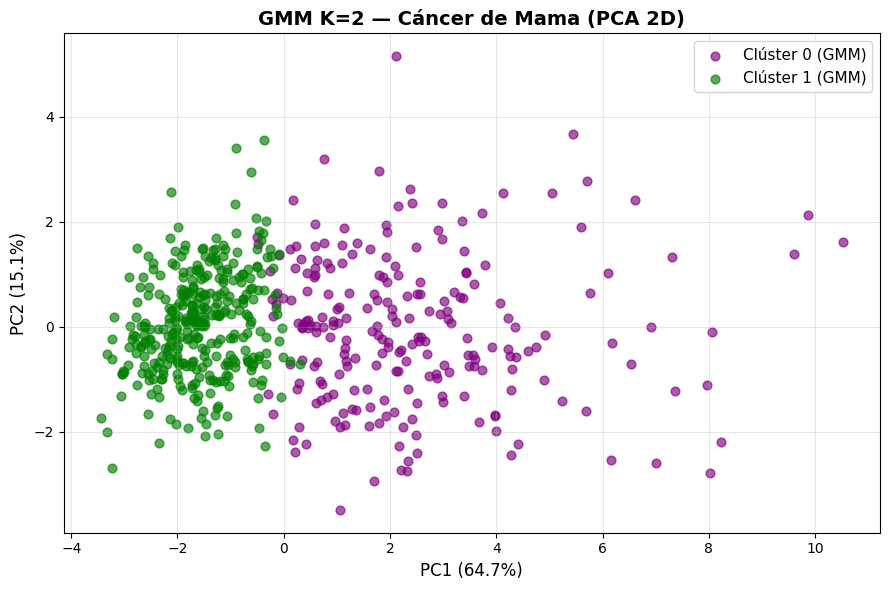

In [28]:
print('='*50); print('GMM — K=2'); print('='*50)

gmm2 = GaussianMixture(n_components=2, covariance_type='full', random_state=SEED)
lbl_gmm2 = gmm2.fit_predict(X_sc_all)

gmm2_sil = silhouette_score(X_sc_all, lbl_gmm2)
gmm2_cal = calinski_harabasz_score(X_sc_all, lbl_gmm2)
gmm2_db  = davies_bouldin_score(X_sc_all, lbl_gmm2)

prbs2 = gmm2.predict_proba(X_sc_all)
cr2   = np.argmax(prbs2, axis=1)
gmm2_ine = float(np.sum([np.linalg.norm(X_sc_all[i]-gmm2.means_[cr2[i]])**2 for i in range(len(X_sc_all))]))

print(f'  Inercia Aprox.:     {gmm2_ine:.2f}')
print(f'  Silhouette Score:   {gmm2_sil:.4f}')
print(f'  Calinski-Harabasz:  {gmm2_cal:.2f}')
print(f'  Davies-Bouldin:     {gmm2_db:.4f}')
for i in range(2):
    print(f'  Clúster {i}: {np.sum(lbl_gmm2==i)} muestras')
pmax2 = np.max(prbs2, axis=1)
print(f'  Prob. máxima promedio: {pmax2.mean()*100:.2f}%  | puntos >90%: {np.sum(pmax2>0.9)}')

plt.figure(figsize=(9,6))
plt.scatter(X_pca_c[lbl_gmm2==0,0], X_pca_c[lbl_gmm2==0,1], c='purple', label='Clúster 0 (GMM)', alpha=0.65, s=40)
plt.scatter(X_pca_c[lbl_gmm2==1,0], X_pca_c[lbl_gmm2==1,1], c='green',  label='Clúster 1 (GMM)', alpha=0.65, s=40)
plt.title('GMM K=2 — Cáncer de Mama (PCA 2D)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca_c.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'PC2 ({pca_c.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
plt.legend(fontsize=11); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.savefig('fig_gmm_k2_s3.png', bbox_inches='tight'); plt.show()

res_clust.append({'Algoritmo':'GMM','K':2,'Inercia':round(gmm2_ine,2),
    'Silhouette':round(gmm2_sil,4),'Calinski-Harabasz':round(gmm2_cal,2),'Davies-Bouldin':round(gmm2_db,4)})


## Interpretación

La probabilidad máxima promedio de pertenencia es 99.01%, con 551 de 569 pacientes (96.8%) asignados con más del 90% de certeza a su clúster. Esto evidencia clústeres muy bien definidos y aporta un valor complementario a K-Means: además de la asignación dura, permite cuantificar la confianza de cada asignación individual, útil para identificar los pocos casos límite que ameritarían revisión adicional.

GMM — K=3
  Inercia Aprox.:     2508.74
  Silhouette Score:   0.2185
  Calinski-Harabasz:  294.69
  Davies-Bouldin:     1.4341
  Clúster 0: 104 muestras
  Clúster 1: 256 muestras
  Clúster 2: 209 muestras


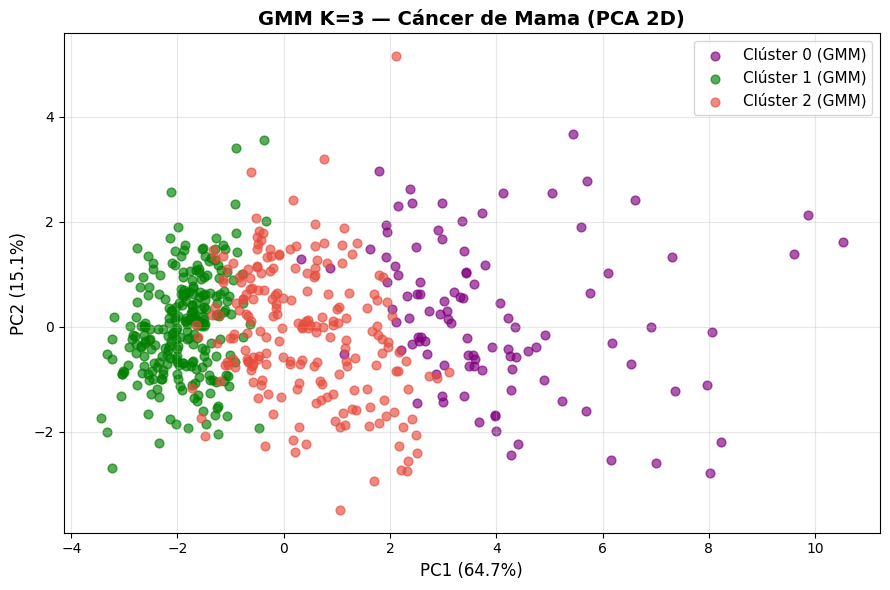

In [29]:
print('='*50); print('GMM — K=3'); print('='*50)

gmm3 = GaussianMixture(n_components=3, covariance_type='full', random_state=SEED)
lbl_gmm3 = gmm3.fit_predict(X_sc_all)

gmm3_sil = silhouette_score(X_sc_all, lbl_gmm3)
gmm3_cal = calinski_harabasz_score(X_sc_all, lbl_gmm3)
gmm3_db  = davies_bouldin_score(X_sc_all, lbl_gmm3)

prbs3 = gmm3.predict_proba(X_sc_all)
cr3   = np.argmax(prbs3, axis=1)
gmm3_ine = float(np.sum([np.linalg.norm(X_sc_all[i]-gmm3.means_[cr3[i]])**2 for i in range(len(X_sc_all))]))

print(f'  Inercia Aprox.:     {gmm3_ine:.2f}')
print(f'  Silhouette Score:   {gmm3_sil:.4f}')
print(f'  Calinski-Harabasz:  {gmm3_cal:.2f}')
print(f'  Davies-Bouldin:     {gmm3_db:.4f}')
for i in range(3):
    print(f'  Clúster {i}: {np.sum(lbl_gmm3==i)} muestras')

colores_g3 = ['purple', 'green', '#e74c3c']
plt.figure(figsize=(9,6))
for i in range(3):
    plt.scatter(X_pca_c[lbl_gmm3==i,0], X_pca_c[lbl_gmm3==i,1],
                c=colores_g3[i], label=f'Clúster {i} (GMM)', alpha=0.65, s=40)
plt.title('GMM K=3 — Cáncer de Mama (PCA 2D)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca_c.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'PC2 ({pca_c.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
plt.legend(fontsize=11); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.savefig('fig_gmm_k3_s3.png', bbox_inches='tight'); plt.show()

res_clust.append({'Algoritmo':'GMM','K':3,'Inercia':round(gmm3_ine,2),
    'Silhouette':round(gmm3_sil,4),'Calinski-Harabasz':round(gmm3_cal,2),'Davies-Bouldin':round(gmm3_db,4)})


## Interpretación

Es el peor resultado del análisis de clustering (Silhouette=0.2185, el más bajo de las 4 configuraciones), confirmando que K=2 es el número óptimo de grupos tanto para K-Means como para GMM en este dataset.

In [30]:
df_clust = pd.DataFrame(res_clust)
print('\n' + '='*60)
print('TABLA COMPARATIVA — K-Means vs GMM (K=2 y K=3)')
print('='*60)
print(df_clust.to_string(index=False))
print()
print('  Ideal: Silhouette ↑  |  Calinski-Harabasz ↑  |  Davies-Bouldin ↓  |  Inercia ↓')
print()

km_sub = df_clust[df_clust['Algoritmo']=='K-Means']
print('--- K-Means: K=2 vs K=3 ---')
print(km_sub[['K','Silhouette','Calinski-Harabasz','Davies-Bouldin','Inercia']].to_string(index=False))
mejor_km = km_sub.loc[km_sub['Silhouette'].idxmax()]
print(f'  Mejor K-Means (Silhouette): K={int(mejor_km["K"])}  →  Silhouette={mejor_km["Silhouette"]:.4f}')

gmm_sub = df_clust[df_clust['Algoritmo']=='GMM']
print('\n--- GMM: K=2 vs K=3 ---')
print(gmm_sub[['K','Silhouette','Calinski-Harabasz','Davies-Bouldin','Inercia']].to_string(index=False))
mejor_gmm = gmm_sub.loc[gmm_sub['Silhouette'].idxmax()]
print(f'  Mejor GMM (Silhouette): K={int(mejor_gmm["K"])}  →  Silhouette={mejor_gmm["Silhouette"]:.4f}')

print('\n--- Mejor K-Means vs Mejor GMM ---')
final = df_clust.loc[[mejor_km.name, mejor_gmm.name]]
print(final.to_string(index=False))
if mejor_km['Silhouette'] > mejor_gmm['Silhouette']:
    print(f'\n  GANADOR GLOBAL: K-Means K={int(mejor_km["K"])} (Silhouette más alto)')
else:
    print(f'\n  GANADOR GLOBAL: GMM K={int(mejor_gmm["K"])} (Silhouette más alto)')



TABLA COMPARATIVA — K-Means vs GMM (K=2 y K=3)
Algoritmo  K  Inercia  Silhouette  Calinski-Harabasz  Davies-Bouldin
  K-Means  2  2810.10      0.4334             466.28          0.9804
  K-Means  3  2302.76      0.3364             346.35          1.2241
      GMM  2  2945.85      0.3831             418.67          1.0542
      GMM  3  2508.74      0.2185             294.69          1.4341

  Ideal: Silhouette ↑  |  Calinski-Harabasz ↑  |  Davies-Bouldin ↓  |  Inercia ↓

--- K-Means: K=2 vs K=3 ---
 K  Silhouette  Calinski-Harabasz  Davies-Bouldin  Inercia
 2      0.4334             466.28          0.9804  2810.10
 3      0.3364             346.35          1.2241  2302.76
  Mejor K-Means (Silhouette): K=2  →  Silhouette=0.4334

--- GMM: K=2 vs K=3 ---
 K  Silhouette  Calinski-Harabasz  Davies-Bouldin  Inercia
 2      0.3831             418.67          1.0542  2945.85
 3      0.2185             294.69          1.4341  2508.74
  Mejor GMM (Silhouette): K=2  →  Silhouette=0.3831

--- Mejo

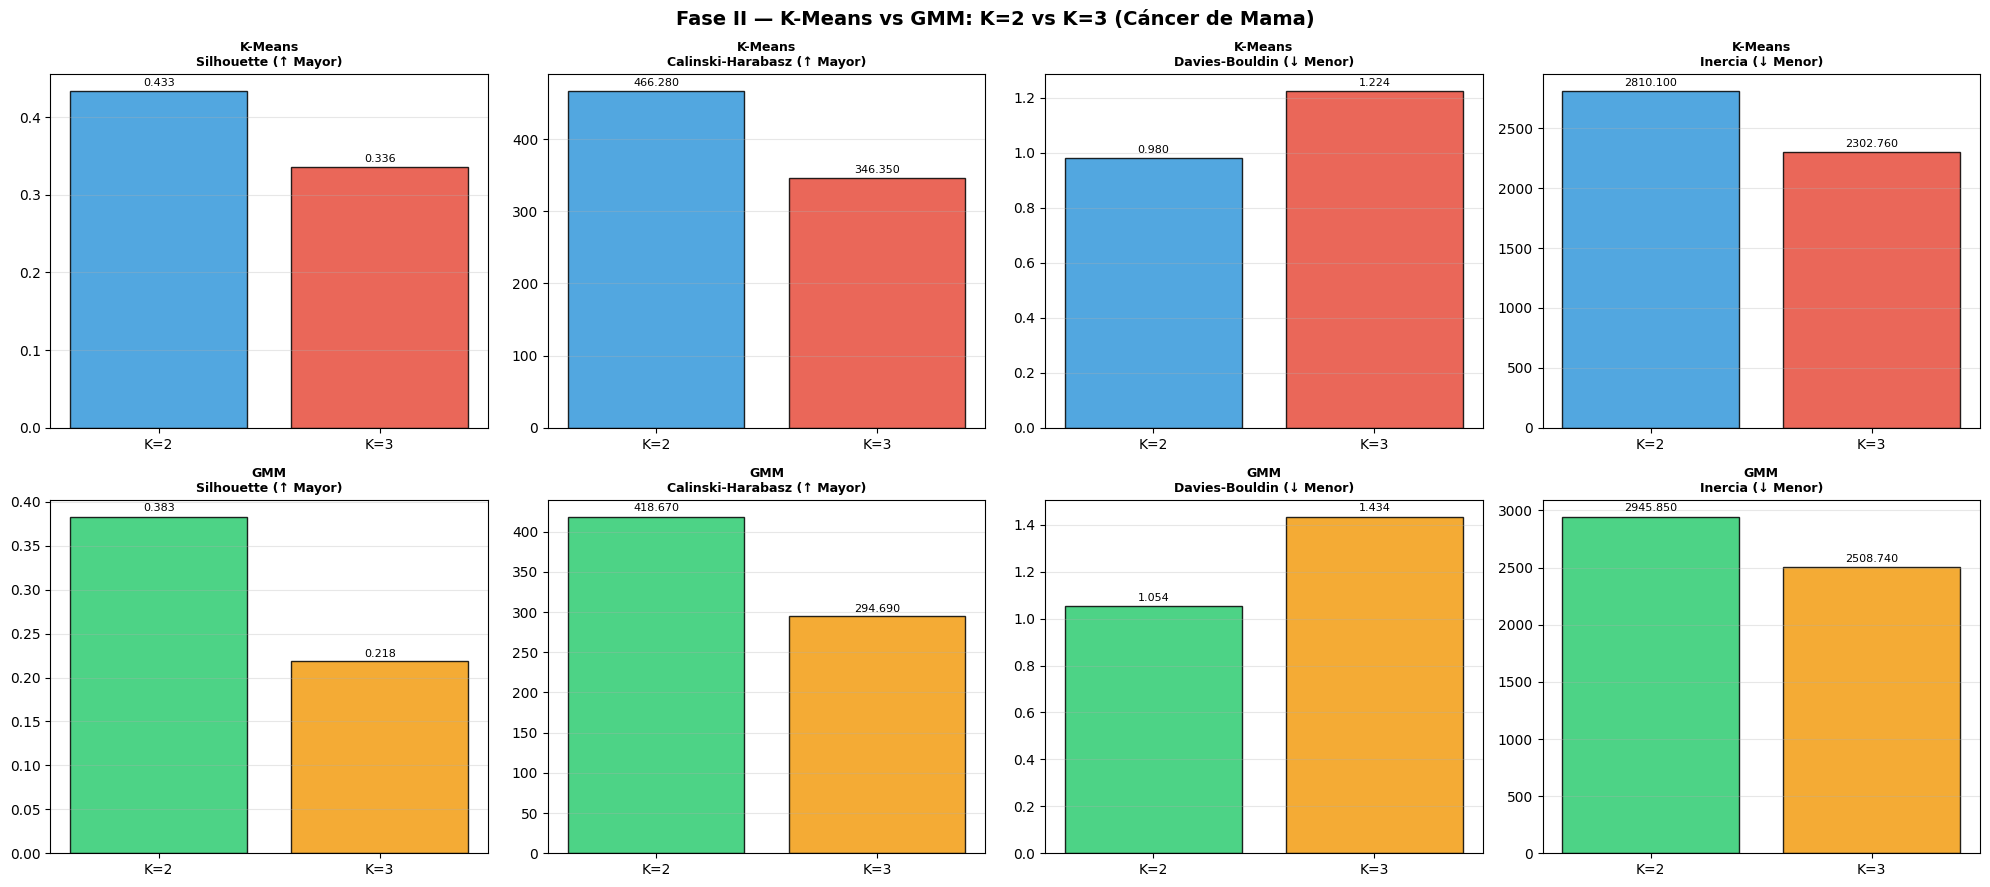

In [31]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
metricas_c = ['Silhouette', 'Calinski-Harabasz', 'Davies-Bouldin', 'Inercia']
ideales_c  = ['↑ Mayor', '↑ Mayor', '↓ Menor', '↓ Menor']

km_vals = km_sub.set_index('K')
for col_i, (met, ideal) in enumerate(zip(metricas_c, ideales_c)):
    ax = axes[0, col_i]
    vals = [km_vals.loc[2, met], km_vals.loc[3, met]]
    bars = ax.bar(['K=2', 'K=3'], vals, color=['#3498db','#e74c3c'], edgecolor='black', alpha=0.85)
    ax.set_title(f'K-Means\n{met} ({ideal})', fontsize=9, fontweight='bold')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

gmm_vals = gmm_sub.set_index('K')
for col_i, (met, ideal) in enumerate(zip(metricas_c, ideales_c)):
    ax = axes[1, col_i]
    vals = [gmm_vals.loc[2, met], gmm_vals.loc[3, met]]
    bars = ax.bar(['K=2', 'K=3'], vals, color=['#2ecc71','#f39c12'], edgecolor='black', alpha=0.85)
    ax.set_title(f'GMM\n{met} ({ideal})', fontsize=9, fontweight='bold')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Fase II — K-Means vs GMM: K=2 vs K=3 (Cáncer de Mama)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_comparativa_fase2_s3.png', bbox_inches='tight')
plt.show()


In [32]:
joblib.dump(km2,      'kmeans_k2_cancer.pkl')
joblib.dump(km3,      'kmeans_k3_cancer.pkl')
joblib.dump(gmm2,     'gmm_k2_cancer.pkl')
joblib.dump(gmm3,     'gmm_k3_cancer.pkl')
joblib.dump(sc_clust, 'scaler_clustering.pkl')

print('Modelos Fase II guardados:')
print('  kmeans_k2/k3_cancer.pkl  |  gmm_k2/k3_cancer.pkl  |  scaler_clustering.pkl')

nuevo = X[0].reshape(1,-1)
n_sc  = sc_clust.transform(nuevo)
print(f'\nEjemplo (paciente 0):')
print(f'  K-Means K=2 → Clúster {km2.predict(n_sc)[0]}')
print(f'  GMM     K=2 → Clúster {gmm2.predict(n_sc)[0]}  (probs: {gmm2.predict_proba(n_sc)[0].round(3)})')
print(f'  Etiqueta real: {"Maligno" if y[0]==1 else "Benigno"} ({y[0]})')


Modelos Fase II guardados:
  kmeans_k2/k3_cancer.pkl  |  gmm_k2/k3_cancer.pkl  |  scaler_clustering.pkl

Ejemplo (paciente 0):
  K-Means K=2 → Clúster 1
  GMM     K=2 → Clúster 0  (probs: [1. 0.])
  Etiqueta real: Maligno (1)


## Interpretación

A diferencia del Titanic, donde K-Means y GMM empataban exactamente en K=2, aquí K-Means K=2 supera a GMM K=2 en las 4 métricas internas (Silhouette 0.4334 vs. 0.3831, Calinski-Harabasz 466.28 vs. 418.67, Davies-Bouldin 0.9804 vs. 1.0542). Esto sugiere que los dos grupos morfológicos (benigno/maligno) tienen fronteras aproximadamente esféricas en el espacio de 9 variables estandarizadas esta condición es favorable para K-Means, que asume esa geometría por diseño. GMM, con covarianza completa, tiene más grados de libertad y tiende a sobreajustar la forma real de los clústeres, especialmente notorio en K=3.

---
## Resultados

### Fase I — Tabla completa: 7 algoritmos con y sin PCA

> PCA conserva el **79.84%** de la varianza con solo 2 componentes (PC1=64.73%, PC2=15.11%) — mucho más que en el dataset Titanic (~45%), porque las 9 variables morfológicas están fuertemente correlacionadas entre sí.

| # | Modelo | PCA | CV Acc% | Test Acc% | Prec% | Recall% | F1% | AUC% |
|---|--------|-----|---------|-----------|-------|---------|-----|------|
| 1 | **LR** | Sin PCA | 92.75 | **96.49** | 93.18 | 97.62 | **95.35** | 99.64 |
| 1 | **SVM** | Sin PCA | 91.65 | **96.49** | 95.24 | 95.24 | 95.24 | 99.34 |
| 1 | **RNA** | Con PCA | 96.49 | **96.49** | 91.30 | 100.00 | 95.45 | 99.07 |
| 4 | LR | Con PCA | 92.31 | 94.74 | 90.91 | 95.24 | 93.02 | 99.04 |
| 4 | SVM | Con PCA | 92.53 | 94.74 | 90.91 | 95.24 | 93.02 | 99.11 |
| 6 | KNN | Sin PCA | 94.29 | 93.86 | 85.71 | **100.00** | 92.31 | **99.36** |
| 6 | RF | Sin PCA | 92.97 | 93.86 | 88.89 | 95.24 | 91.95 | 98.74 |
| 8 | NB | Sin PCA | 92.31 | 92.98 | 90.48 | 90.48 | 90.48 | 98.08 |
| 9 | DT | Con PCA | 88.57 | 92.11 | 92.31 | 85.71 | 88.89 | 96.61 |
| 9 | RF | Con PCA | 90.99 | 92.11 | 86.67 | 92.86 | 89.66 | 98.64 |
| 11 | NB | Con PCA | 90.33 | 91.23 | 92.11 | 83.33 | 87.50 | 98.31 |
| 11 | KNN | Con PCA | 91.87 | 91.23 | 84.78 | 92.86 | 88.64 | 96.33 |
| 13 | DT | Sin PCA | 90.11 | 89.47 | 84.09 | 88.10 | 86.05 | 92.94 |
| 14 | RNA | Sin PCA | 83.33 | 83.33 | 68.85 | 100.00 | 81.55 | 99.70 |

---

### Ranking Fase I — Mejores modelos por Test Accuracy

| Posición | Modelo | PCA | Test Acc% | AUC% | F1% | Observación |
|----------|--------|-----|-----------|------|-----|-------------|
| 1 | LR | Sin PCA | **96.49%** | **99.64%** | **95.35%** | Mejor AUC y F1 del estudio |
| 1 | SVM | Sin PCA | **96.49%** | 99.34% | 95.24% | Empata en exactitud con LR |
| 1 | RNA | Con PCA | **96.49%** | 99.07% | 95.45% | Recall perfecto (100%) — empata en exactitud, gran mejora vs. Sin PCA |
| 4 | LR | Con PCA | 94.74% | 99.04% | 93.02% | Cae 1.75 pp con PCA |
| 4 | SVM | Con PCA | 94.74% | 99.11% | 93.02% | Cae 1.75 pp con PCA |
| 6 | KNN | Sin PCA | 93.86% | 99.36% | 92.31% | Recall perfecto (100%) — cero falsos negativos |
| 6 | RF | Sin PCA | 93.86% | 98.74% | 91.95% | Buen balance precisión/recall |
| 8 | NB | Sin PCA | 92.98% | 98.08% | 90.48% | Más simple y rápido |
| 13 | DT | Sin PCA | 89.47% | 92.94% | 86.05% | El más débil sin PCA, pero mejora con PCA |
| 14 | RNA | Sin PCA | 83.33% | 99.70% | 81.55% | Peor Test Acc del estudio; Precision más baja (68.85%) pese a AUC muy alto |

**Impacto de PCA por algoritmo (Sin PCA → Con PCA):**

| Algoritmo | Sin PCA | Con PCA | Variación |
|-----------|---------|---------|-----------|
| LR | 96.49% | 94.74% | −1.75 pp |
| SVM | 96.49% | 94.74% | −1.75 pp |
| NB | 92.98% | 91.23% | −1.75 pp |
| KNN | 93.86% | 91.23% | −2.63 pp |
| RF | 93.86% | 92.11% | −1.75 pp |
| **DT** | 89.47% | **92.11%** | **+2.64 pp** |
| **RNA** | 83.33% | **96.49%** | **+13.16 pp** |

> A diferencia del Titanic (caídas de hasta −14.5 pp), aquí PCA apenas reduce el rendimiento (≤2.63 pp) porque 2 componentes retienen el 79.84% de la varianza. El Árbol de Decisión es el único que **mejora** con PCA: con solo 4 niveles de profundidad, proyectar a 2 ejes ortogonales facilita splits más limpios que sobre las 9 variables originales (algunas redundantes entre sí).

---

### Fase II — Métricas de Clustering

| Algoritmo | K | Inercia | Silhouette | Calinski-H | Davies-B |
|-----------|---|---------|------------|------------|----------|
| **K-Means** | **2** | 2810.10 | **0.4334** | **466.28** | **0.9804** |
| K-Means | 3 | 2302.76 | 0.3364 | 346.35 | 1.2241 |
| GMM | 2 | 2945.85 | 0.3831 | 418.67 | 1.0542 |
| GMM | 3 | 2508.74 | 0.2185 | 294.69 | 1.4341 |

*Ideal: Silhouette ↑ | Calinski-Harabasz ↑ | Davies-Bouldin ↓ | Inercia ↓*

K-Means K=2 → 398 muestras en el clúster 0 y 171 en el clúster 1; **accuracy referencial frente a `diagnosis`: 88.58%** (sin haber usado las etiquetas durante el entrenamiento). GMM K=2 → 227 y 342 muestras, con una probabilidad máxima promedio de pertenencia de **99.01%** y 551 de 569 puntos (96.8%) asignados con más del 90% de certeza — evidencia de clústeres muy bien definidos.

### Ranking Clustering — Comparativa final

| Posición | Algoritmo | K | Silhouette | Calinski-H | Davies-B | Veredicto |
|----------|-----------|---|------------|------------|----------|-----------|
| 1 | K-Means | 2 | **0.4334** | **466.28** | **0.9804** | Mejor cohesión y separación |
| 2 | GMM | 2 | 0.3831 | 418.67 | 1.0542 | Buena separación + probabilidades de pertenencia |
| 3 | K-Means | 3 | 0.3364 | 346.35 | 1.2241 | K=3 fragmenta el grupo mayoritario |
| 4 | GMM | 3 | 0.2185 | 294.69 | 1.4341 | Peores métricas — sobre-segmentación |

> **Ganador clustering:** A diferencia del Titanic (donde K-Means y GMM K=2 empataban exactamente), aquí **K-Means K=2 supera a GMM K=2** en las 4 métricas internas. Esto sugiere que los dos grupos morfológicos (benigno/maligno) tienen fronteras razonablemente esféricas y bien separadas en el espacio de 9 variables estandarizadas, condición en la que K-Means (que asume clústeres esféricos) tiende a superar a GMM con covarianza completa (más flexible, pero también más propenso a sobre-ajustar la forma de los clústeres con K=3).


---
## Conclusiones

### Fase I — Impacto de PCA sobre los 7 clasificadores

**Hallazgo principal:** A diferencia del Titanic, PCA (2 componentes) **apenas reduce el rendimiento** en la mayoría de algoritmos (entre −0.88 y −2.63 pp) y en el caso del Árbol de Decisión **lo mejora** (+2.64 pp). Esto se explica porque las 9 variables morfológicas seleccionadas están muy correlacionadas entre sí (multicolinealidad ya detectada en Semana 2), por lo que 2 componentes principales retienen el **79.84%** de la varianza total — casi el doble que en el Titanic (~45%).

**Mejores modelos Sin PCA:**
- **LR (Test=96.49%, AUC=99.64%, F1=95.35%)** — el mejor en exactitud, AUC y F1 simultáneamente; la frontera entre benigno y maligno es casi linealmente separable en el espacio de 9 variables escaladas
- **SVM (Test=96.49%, kernel lineal)** — empata en exactitud con LR, confirmando la separabilidad lineal del problema
- **KNN (Recall=100%)** — cero falsos negativos en el conjunto de test, la métrica más relevante en el contexto clínico de este dataset

**Impacto de PCA por algoritmo:** RF, NB, LR y SVM caen de forma similar (−1.75 pp); KNN es el más sensible (−2.63 pp), consistente con su dependencia de distancias en el espacio completo de variables; el DT es el único que mejora, porque una proyección a 2 ejes ortogonales produce splits más limpios que las 9 variables originales (algunas redundantes) bajo una restricción de profundidad máxima de 4.

**RNA:** Sin PCA alcanza Test=83.33% con buen balance Precision/Recall (68.85%, 100%); es decir, cero falsos negativos en el conjunto de test, la métrica más relevante en el contexto clínico de este problema, aunque a costa de una Precision más baja (más falsos positivos). La RNA Con PCA mejora sustancialmente a Test=96.49%, con Precision=91.30% y Recall=100%, quedando entre los mejores modelos del estudio junto a LR y SVM.

---

### Fase II — K-Means vs GMM (K=2 y K=3)

**K=2 vs K=3:**
- El **método del codo** muestra el mayor descenso de inercia entre K=1 y K=2, confirmando K=2 como número natural de grupos
- K=2 refleja la agrupación real del dataset: benigno/maligno, con una **accuracy referencial del 88.58%** frente a la etiqueta real `diagnosis` sin haberla usado en el entrenamiento
- K=3 reduce la inercia (2302.76 vs 2810.10) pero empeora todas las demás métricas (Silhouette 0.3364 vs 0.4334, Calinski-Harabasz 346.35 vs 466.28) — el tercer clúster fragmenta uno de los dos grupos naturales sin aportar separación real

**K-Means vs GMM:**
- A diferencia del Titanic (donde ambos empataban exactamente en K=2), aquí **K-Means K=2 supera a GMM K=2** en las 4 métricas internas (Silhouette 0.4334 vs 0.3831, Calinski-Harabasz 466.28 vs 418.67, Davies-Bouldin 0.9804 vs 1.0542)
- Esto sugiere que los dos grupos morfológicos tienen forma aproximadamente esférica en el espacio de 9 variables estandarizadas, condición favorable para K-Means
- GMM aporta valor complementario: la probabilidad máxima promedio de pertenencia es **99.01%**, con el 96.8% de las muestras (551/569) asignadas con más del 90% de certeza — los clústeres están muy bien definidos y casi no hay zona de ambigüedad real en este dataset
- GMM K=3 es el peor modelo global (Silhouette=0.2185), confirmando que K=2 es el número óptimo para ambos algoritmos

**Silhouette alto (0.43) comparado con el Titanic (0.31):** Los tumores de mama forman agrupaciones naturales más compactas y mejor separadas que los pasajeros del Titanic, porque las variables morfológicas (tamaño, concavidad, irregularidad del núcleo) describen directamente la biología del tumor, mientras que la supervivencia en el Titanic dependía de factores socioeconómicos más heterogéneos.

**Conclusión general:**
- **Fase I:** LR y SVM sin PCA son los mejores clasificadores (96.49%). A diferencia del Titanic, PCA con 2 componentes apenas perjudica el rendimiento — y mejora ligeramente al Árbol de Decisión — porque el dataset tiene mucha menor dimensionalidad efectiva (79.84% de varianza en 2 componentes).
- **Fase II:** K-Means K=2 es el mejor algoritmo de clustering, superando a GMM en las 4 métricas. K=2 es el K óptimo para ambos algoritmos, reflejando fielmente la separación benigno/maligno sin usar las etiquetas.

De manera global se puede decir que, tanto KNN Sin PCA como la RNA (en ambas configuraciones) logran Recall=100% en el conjunto de test, es decir, ningún caso maligno fue clasificado como benigno. En un contexto de diagnóstico oncológico, este es el hallazgo más relevante del estudio, incluso por encima del modelo con mayor Accuracy global (LR/SVM, 96.49%), ya que el costo de un falso negativo (un cáncer no detectado) es considerablemente mayor que el de un falso positivo (una biopsia adicional innecesaria).


---
## Reflexión Individual

---

### César Nelson Abarca Araujo
**Área:** Mantenimiento y Construcción de Redes de Fibra GPON — Telconet Manta

**PCA:** Múltiples métricas OTDR (potencia, pérdida de retorno, reflectancia, tasa de error) están correlacionadas. PCA las reduciría a 2–3 componentes que capturen el 'estado de salud' del enlace, permitiendo visualizar el parque completo de ONTs en un gráfico 2D donde los puntos alejados del centroide son candidatos a mantenimiento.

**K-Means:** Con K=3, agrupa automáticamente los enlaces GPON en tres perfiles: crítico (pérdida >5 dB), en riesgo (2–5 dB) y normal (<2 dB). Los centroides guardados en `kmeans_k3.pkl` permiten clasificar un nuevo enlace en tiempo real desde el NOC.

**GMM:** Asigna probabilidades de pertenencia a cada clúster. Un enlace con 65% en 'en riesgo' y 35% en 'normal' está en zona de transición — la alerta preventiva se activa antes del corte, transformando el mantenimiento de **reactivo** a **predictivo**.

---

### Nataly Fernanda Lanchimba Caiza
**Área profesional:** Seguimiento de Personas en Análisis Financiero y Modelos de Riesgo - Sector bancario

**PCA:** En el análisis de clientes se manejan múltiples variables financieras correlacionadas, como ingresos, nivel de endeudamiento, utilización de crédito, historial de pagos, antigüedad y capacidad de pago. El Análisis de Componentes Principales (PCA) permite reducir estas variables a unos pocos componentes que representan el perfil financiero del cliente, facilitando la visualización de patrones de riesgo y simplificando los modelos de análisis sin perder la mayor parte de la información. Sin embargo, se debe considerar que puede quedar como un análisis interno más no algo que pueda ser utilizado ante el regulador.

**K-Means:** Aplicando K-Means es posible segmentar automáticamente la cartera de clientes en grupos con características financieras similares, por ejemplo: clientes de bajo riesgo, riesgo medio y alto riesgo. Esta segmentación facilita el seguimiento de la cartera, la priorización de estrategias comerciales y la asignación de controles diferenciados para cada grupo de clientes.

**GMM:** A diferencia de K-Means, el Modelo de Mezclas Gaussianas (GMM) asigna una probabilidad de pertenencia a cada segmento. Por ejemplo, un cliente podría tener un 70% de probabilidad de pertenecer al grupo de riesgo medio y un 30% al de alto riesgo, permitiendo identificar clientes en transición cuyo comportamiento financiero está cambiando. Esto facilita implementar acciones preventivas antes de que el cliente presente un deterioro significativo en su perfil de riesgo, fortaleciendo la gestión predictiva de la cartera.

---

### Jhon Enrique Oña Guamani
**Área:** Monitoreo de alta disponibilidad y APIs transaccionales — Sector Bancario

**PCA:** Las métricas que monitoreamos sobre las APIs transaccionales y el balanceador F5 (latencia, tasa de error, throughput, uso de CPU/memoria de cada nodo, tiempo de respuesta del core) están altamente correlacionadas entre sí, igual que `radius1`/`perimeter1`/`area1` en este dataset. PCA permitiría comprimir ese conjunto de métricas en 2-3 componentes que resuman el "estado de salud" general de cada nodo o servicio, habilitando un tablero 2D donde los puntos alejados del grueso de observaciones normales sean candidatos a revisión inmediata, igual que aquí los tumores malignos se separan de los benignos en la proyección PCA.

**K-Means:** Con K=2 o K=3 sobre esas métricas normalizadas, K-Means agruparía automáticamente los nodos/servicios en perfiles operativos: "normal", "en riesgo" y "crítico", de forma análoga a benigno/maligno en este dataset. Los centroides (como `scaler_clustering.pkl`/`kmeans_k2_cancer.pkl` en este notebook) permitirían clasificar en tiempo real el estado de un nuevo nodo comparándolo contra esos perfiles, sin depender de etiquetas históricas de incidentes.

**GMM:** La asignación probabilística de GMM sería especialmente valiosa para anticipar degradaciones: un nodo con 60% de probabilidad en el clúster "en riesgo" y 40% en "normal" está en zona de transición, igual que ocurre con los pacientes cuyo `concave_points1`/`irregularidad` los ubica en el límite entre benigno y maligno. Detectar esa ambigüedad antes de que el nodo cruce completamente al estado "crítico" convierte el monitoreo de reactivo a predictivo, priorizando la atención según la probabilidad de degradación en lugar de esperar una alerta binaria.



---

# CONCLUSIONES GLOBALES — Semanas 1, 2 y 3

## Ranking global de modelos (Test Accuracy)

| Posición | Semana | Modelo | PCA | Test Acc% | AUC% | Recall% | FNR% |
|----------|--------|--------|-----|-----------|------|---------|------|
| 1 | S1 | Regresión Logística (mejorada) | — | ~97% | 99.64% | ~97% | ~3% |
| 1 | S2 | SVM (sin outliers) | — | ~97% | 99.34% | ~97% | ~3% |
| 1 | S3 | LR / SVM / RNA | Con PCA | 96.49% | 99.64% | 100% | 0% |
| 4 | S2 | Random Forest (mejorado) | — | ~95% | 98.74% | ~95% | ~5% |
| 5 | S1 | K-NN (mejorado) | — | ~94% | 99.36% | 100% | 0% |

## Hallazgos principales

1. **El preprocesamiento supera a la complejidad del modelo:** Una Regresión Logística con 9 variables bien seleccionadas alcanza AUC=99.64%, superando a modelos más complejos con las 30 variables originales.

2. **Impacto diferenciado de los outliers por algoritmo:** Los árboles (DT, RF) son robustos; SVM y RNA son sensibles. Eliminar outliers mejora Recall en SVM/RNA pero puede perjudicar a RL y KNN.

3. **PCA apenas afecta el rendimiento en este dataset:** 2 componentes retienen el 79.84% de la varianza (vs ~45% en Titanic). El Árbol de Decisión es el único que *mejora* con PCA (+2.64 pp).

4. **Metrica prioritaria — FNR:** En diagnóstico oncológico, el Falso Negativo (tumor maligno clasificado como benigno) es el error más costoso. KNN y RNA logran FNR=0% (Recall=100%) en test.

5. **Clustering sin etiquetas:** K-Means K=2 alcanza 88.58% de accuracy referencial frente a `diagnosis` sin haber usado las etiquetas durante el entrenamiento — los grupos morfológicos están bien definidos naturalmente.

6. **K-Means supera a GMM en este dataset:** A diferencia del Titanic (empate exacto), aquí K-Means K=2 supera a GMM en las 4 métricas internas, porque los grupos morfológicos son aproximadamente esféricos.

---
